# <font color=#0099CC>**ANÁLISIS DE UNA CARTERA DE RENTA FIJA** </font>

### **Fecha: 26/11/2025 | Autores: Javier Fernández Guerra**

### <font color=#0099CC>**0. INTRODUCCIÓN**</font>

### <font color=#336699>**0.1. OBJETIVO Y DATOS DISPONIBLES**</font>

En esta práctica, desarrollaremos un análisis relativamente exahustivo de un universo de Renta Fija, en concreto, de bonos corporativos. Además, construiremos y analizaremos varias carteras. 

Para ello, contaremos con la siguiente información almacenada en la carpeta *data*:
- Universo de bonos, con sus características esenciales (fichero *universo.csv*)
- Histórico de precios de cierre del universo de bonos anterior (fichero *precios_historicos_universo.csv*)
- Curva de tipos de interés €STR (fichero *curvaESTR.csv*)
- Histórico de precios de otros índices que nos serán de utilidad (fichero *precios_varios*):
    - Índices de crédito: ITRAXX Main y ITRAXX XOVER. Serán útiles para la cobertura del riesgo de crédito.
    - Futuros sobre el *Schatz* (DU1), *BOBL* (OE1) y *BUND* (RX1). Serán útiles para la cobertura de los tipos de interés.
    - Índice de crédito *RECMTREU*, que valdría como benchmark de las carteras que construyamos.

No necesariamente se usará toda toda la información

### <font color=#336699>**0.2. PROCEDIMIENTO**</font>


En líneas generales, estos son los ejercicios que completaremos, aunque los detallaremos más en cada apartado:
1. Análisis de datos. En esta sección, haremos un análisis de la información que tenemos de cada bono y lo que significa. Asimismo, haremos los tratamientos y limpieza que necesitemos para luego poder usarlos.
2. Valoración de los bonos del universo utilizando la curva de descuento y bajo ciertas asunciones. Comparación de estos precios con los precios de mercado.
3. Cálculo del spread que pagan los bonos sobre la curva.
4. Cálculo de *yield*, duración y convexidad.
5. Contrucción de una cartera equiponderada con todos los bonos del universo. Contraste con el benchmark (os proponemos el índice RECMTREU para el que os hemos dado los precios) y backtest de la estrategia. ¡OJO! El índice es *Total Return*.
6. Tienes el mandato de construir una cartera de como máximo **20** bonos corporativos con ese universo y una serie de restricciones y, claro, maximizando la rentabilidad total de la cartera:
    - La duración de la cartera no debe superar los 3 años
    - La exposición a emisiones HY no puede superar el 10% de la cartera
    - No puedes invertir en deuda subordinada
    - No se puede invertir en emisiones de tamaño igual o inferior a 500 millones
    - No se puede invertir más de un 10% del capital en una misma emisión
    - No puede haber más de un 15% de concentración en un mismo emisor
    (¡OJO! No estamos teniendo en cuenta en este ejercicio si hubiera un mínimo de inversión, lo cuál sería un dato relevante tener en cuenta en un caso real)

    6.1. Constrúyela a fecha de hoy

    6.2. Teniendo en cuenta la naturaleza que nos están pidiendo para la cartera, ¿añadirías alguna otra restricción?

    6.3. ¿Cómo medirías el riesgo de crédito de la cartera?

    6.4. ¿Cómo medirías el riesgo de liquidez de la cartera?

    6.5. Describe cómo habría que hacer el backtest de esta cartera
7. Ahora, se te pide que cubras la exposición de la cartera a los tipos de interés. Con la información que tienes, ¿cómo lo harías?
8. ¿Y si quisieras cubrir total o parcialmente el riesgo de crédito? Usa de nuevo la información que tienes.
9. ¿Cómo construirías tu cartera? ¿Se te ocurre alguna estrategia específica, por ejemplo, de valor relativo?


### <font color=#336699>**0.3. LIBRERÍAS UTILIZADAS**</font>

In [1]:

# Librerías necesarias para el proyecto
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime
from tqdm import tqdm
import pulp
from typing import Optional, Tuple, List

from funciones import *  # importa todas las funciones de funciones.py
from valoracion import *
from zspread import *

In [2]:
# Estilo
plt.style.use('dark_background')

In [3]:
# Fecha de análisis
fecha_analisis = pd.to_datetime('2025-10-01')

### <font color=#0099CC>**1. DATOS**</font>

Haz un primer análisis visual de la información que tenemos del universo de bono.
Entre otras, plantéate cuestiones como:
- ¿Divisas?
- ¿Tipo de bonos? ¿Fijo/Flotante? ¿Prelación? ¿Opcionalidad? ¿Hay bonos perpetuos?
- ¿Sectores? ¿Emisores? Si invirtéramos en todos los bonos, ¿dirías a priori que la cartera está diversificada?
- ¿Ratings? (Riesgo de crédito)
- ¿Otros datos cuantitativos?
    - Riesgo de liquidez - horquillas y nominal vivo
- ¿Hay *gaps* en la información que vamos a tener que tratar?

<style>.gray {background-color: #595959}

</style><div class="gray">❕💬¿Qué observas en los datos? Analiza la información que tenemos del universo</div>

### <font color=#336699>**1.1. CUESTIONES PREVIAS**</font>

In [4]:
# Cargamos el csv 'universo'
BASE_DIR = Path().resolve().parent  # sube desde notebooks a Enunciado
csv_path = BASE_DIR / 'data' / 'universo.csv'

universo = pd.read_csv(csv_path, sep=';', index_col=0)
universo.head()


,Description,Ccy,Price,Issuer,Industry Sector,Maturity,Coupon,Rating,PD 1YR,Outstanding Amount,Callable,Next Call Date,Seniority,Coupon Frequency,Coupon Type,First Coupon Date,Penultimate Coupon Date,Issue date,Bid Price,Ask Price
ISIN,,,,,,,,,,,,,,,,,,,,
XS0161488498,DT 7 ½ 01/24/33,EUR,127.8353,DEUTSCHE TELEKOM INT FIN,Communications,24/01/2033,7.500,BBB+,0.021966,500000000,N,NaN,Sr Unsecured,1,FIXED,24/01/2004,24/01/2032,24/01/2003,127.462,128.208
FR0000471930,ORAFP 8 ⅛ 01/28/33,EUR,131.3195,ORANGE SA,Communications,28/01/2033,8.125,BBB+,0.000021,1500000000,N,NaN,Sr Unsecured,1,FIXED,28/01/2004,28/01/2032,28/01/2003,130.991,131.648
XS0162513211,EOANGR 5 ¾ 02/14/33,EUR,115.7800,E.ON INTL FINANCE BV,Utilities,14/02/2033,5.750,BBB+,0.000101,600000000,N,NaN,Sr Unsecured,1,FIXED,14/02/2004,14/02/2032,14/02/2003,115.447,116.114
XS0162869076,TELEFO 5 ⅞ 02/14/33,EUR,116.3000,TELEFONICA EUROPE BV,Communications,14/02/2033,5.875,BBB-,0.000125,500000000,N,NaN,Sr Unsecured,1,FIXED,14/02/2004,14/02/2032,14/02/2003,115.984,116.616
FR0010014845,PEUGOT 6 09/19/33,EUR,112.3887,PSA TRESORERIE GIE,"Consumer, Cyclical",19/09/2033,6.000,BBB,0.024240,600000000,N,NaN,Sr Unsecured,1,FIXED,19/09/2004,19/09/2032,19/09/2003,111.839,112.938


In [5]:
# ¿Qué info tenemos de cada bono? Ordenamos alfabeticamente
universo_col = sorted(list(universo.columns))
print('\n'.join(universo_col))

Ask Price
Bid Price
Callable
Ccy
Coupon
Coupon Frequency
Coupon Type
Description
First Coupon Date
Industry Sector
Issue date
Issuer
Maturity
Next Call Date
Outstanding Amount
PD 1YR
Penultimate Coupon Date
Price
Rating
Seniority


### <font color=#336699>**1.2. DIVISAS**</font>

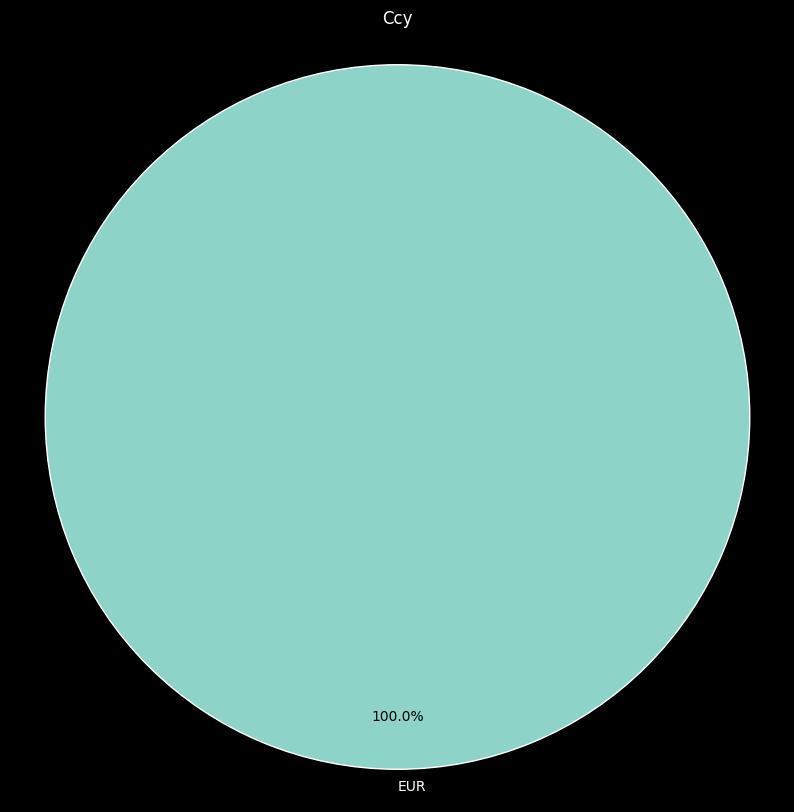

In [6]:
# ¿Cuántas divisas diferentes tenemos? Todos los bonos cotizan en EUR
pie_chart_con_otros(universo, 'Ccy')

> <u>Tipos de Divisa</u>: Como podemos observar en el pie-plot anterior, el universo de bonos está completamente denominado en EUR, por lo que no existe exposición al riesgo de tipo de cambio. Esto nos permite centrar el análisis en otros factores relevantes de renta fija (como spreads, duración, convexidad y calidad crediticia) sin necesidad de considerar ajustes por divisa.

### <font color=#336699>**1.3. TIPOS DE BONO**</font>

#### <font color=#808080>1.3.1. Tipos de Cupón</font>

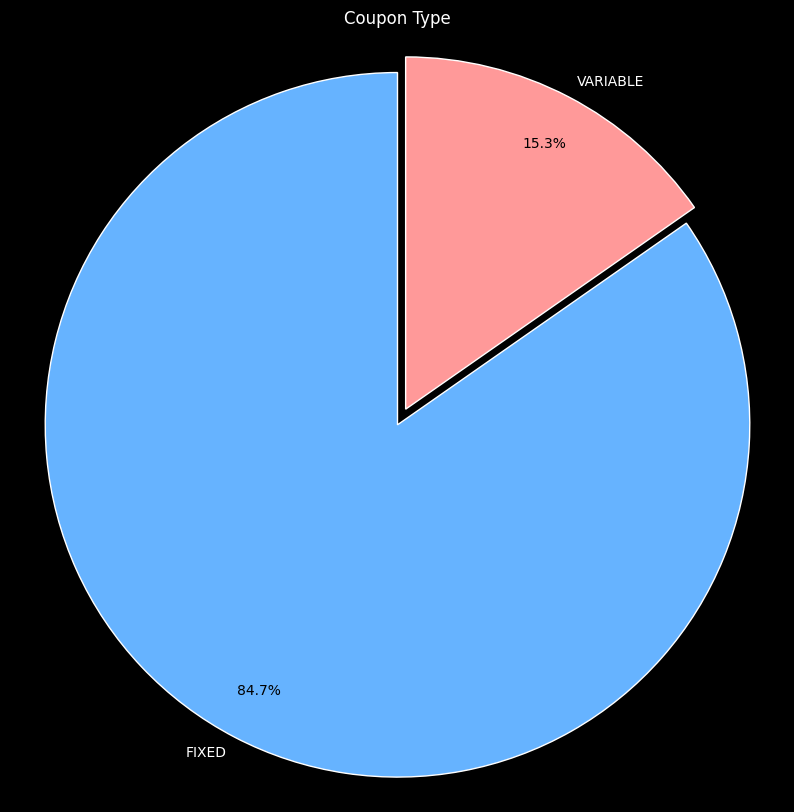

In [7]:
# ¿Qué tipos de bonos tenemos? Hay bonos de tipo fijo y variable
pie_chart_con_otros(universo, 'Coupon Type', umbral=0.05, colores=['#66b3ff','#ff9999'])

> <u>Tipos de Cupón</u>: El universo está compuesto mayoritariamente por bonos fixed (84,7%) y un menor porcentaje variable (15,3%). Una de las asunciones que hacemos en este proyecto es que todos los cupones pagados son fijos hasta vencimiento (aunque en la práctica algunos puedan variar a lo largo de la vida del bono). Esta simplificación permite centrarnos en la valoración, cálculo de spreads, duración y convexidad sin introducir complejidad adicional por variaciones de cupón.

#### <font color=#808080>1.3.2. Tipos de Prelación</font>

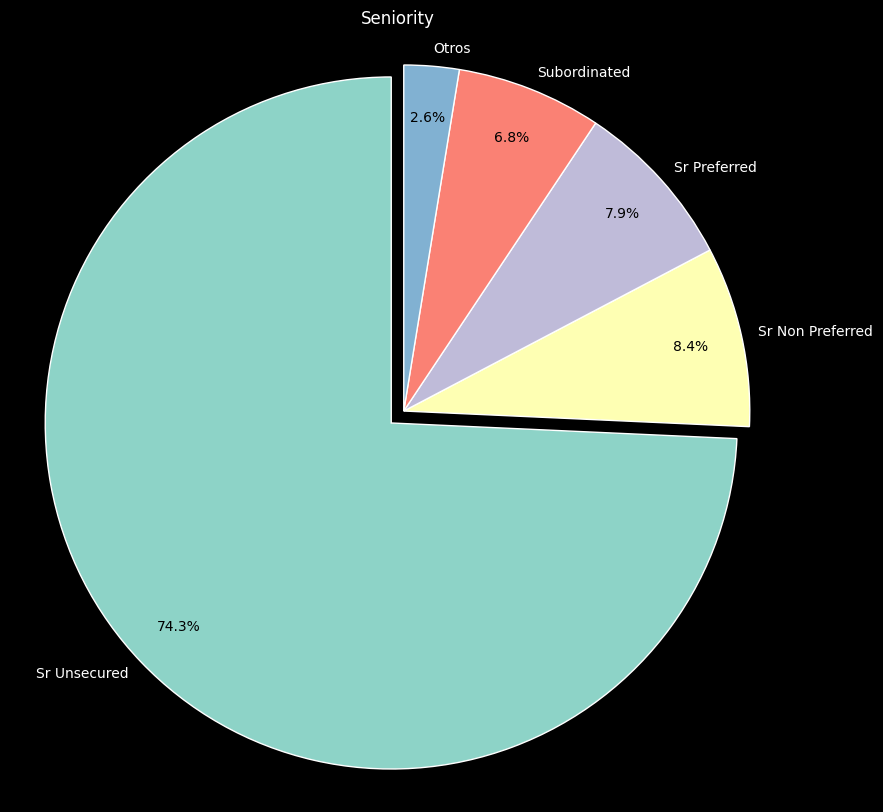

In [8]:
# ¿Qué tipos de prelación hay? Su distribución es la siguiente...
pie_chart_con_otros(universo, 'Seniority', umbral=0.05)

> <u>Tipos de Prelación</u>: La mayor parte del universo corresponde a emisiones senior unsecured (74,3%), seguido de senior non-preferred (8,4%) y senior preferred (7,9%), con una menor proporción de deuda subordinada (6,8%) y otros tipos (2,6%). Esta distribución indica que la cartera está concentrada en bonos con alta prioridad de cobro, lo que influye directamente en la evaluación del riesgo de crédito y la estructura de pérdidas en escenarios adversos.

#### <font color=#808080>1.3.3. Calleable</font>

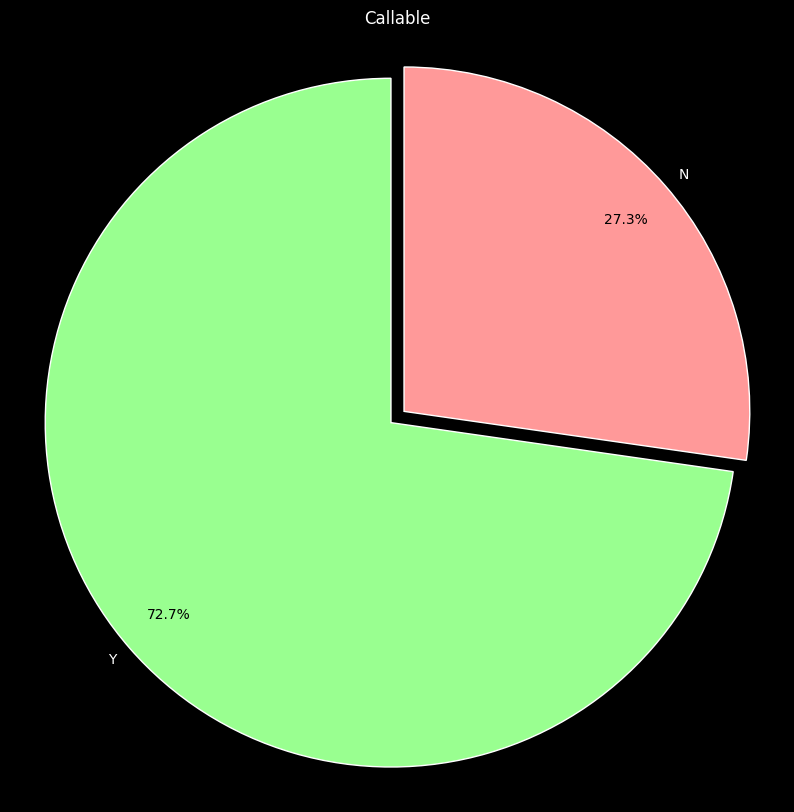

In [9]:
# ¿Existen bonos 'calleables'? Sí, y representan un 72.7% del total de bonos
pie_chart_con_otros(universo, 'Callable', umbral=0.05, colores=['#99ff90','#ff9999'])

> <u>Calleable</u>: El 72,7% del universo corresponde a bonos calleables, mientras que el 27,3% restante no lo es. Esta característica es relevante para nuestro análisis porque, a efectos de este trabajo, asumimos que los bonos perpetuos tienen como vencimiento la próxima fecha call y que todos los bonos con opción de call serán efectivamente ejercidos, utilizando por tanto la fecha call como fecha de vencimiento. Esta simplificación permite incorporar correctamente el riesgo de call en la valoración y en el cálculo de duración y convexidad.

#### <font color=#808080>1.3.4. Bonos Perpetuos</font>

In [10]:
# ¿Existen Bonos perpetuos? Sí, hay 19 bonos sin maturity date
bonos_perpetuos_iloc = np.where(universo['Maturity'].isna())[0]  # Índices de bonos perpetuos
bonos_perpetuos = universo.iloc[bonos_perpetuos_iloc] # Selección directa con iloc
bonos_perpetuos_porc = round((len(bonos_perpetuos)/len(universo))*100, 2) # Porcentaje de bonos perpetuos frente al total

# Mostrar
print(f'Hay {len(bonos_perpetuos)} bonos perpetuos. Representan un {bonos_perpetuos_porc}% del total de bonos en el universo de estudio.\n')
print('Bonos perpetuos:')
display(bonos_perpetuos)

Hay 19 bonos perpetuos. Representan un 0.84% del total de bonos en el universo de estudio.

Bonos perpetuos:


,Description,Ccy,Price,Issuer,Industry Sector,Maturity,Coupon,Rating,PD 1YR,Outstanding Amount,Callable,Next Call Date,Seniority,Coupon Frequency,Coupon Type,First Coupon Date,Penultimate Coupon Date,Issue date,Bid Price,Ask Price
ISIN,,,,,,,,,,,,,,,,,,,,
XS1115498260,ORAFP 5 PERP,EUR,102.19020,ORANGE SA,Communications,NaN,5.000,BBB-,2.142390e-05,499998000,Y,01/10/2026,Jr Subordinated,1,VARIABLE,01/10/2015,NaN,01/10/2014,101.894,102.486
XS1206541366,VW 3 ½ PERP,EUR,96.28500,VOLKSWAGEN INTL FIN NV,"Consumer, Cyclical",NaN,3.500,BBB-,4.212007e-02,1400000000,Y,20/03/2030,Jr Subordinated,1,VARIABLE,20/03/2016,NaN,20/03/2015,96.012,96.558
XS1492580516,SLHNVX 4 ½ PERP,EUR,102.88900,ELM BV (SWISS LIFE),Financial,NaN,4.500,NR,2.039300e-07,600000000,Y,19/05/2027,Subordinated,1,VARIABLE,19/05/2017,NaN,27/09/2016,102.597,103.182
XS1629774230,VW 3 ⅞ PERP,EUR,100.09400,VOLKSWAGEN INTL FIN NV,"Consumer, Cyclical",NaN,3.875,BBB-,4.212007e-02,2000000000,Y,14/06/2027,Jr Subordinated,1,VARIABLE,14/06/2018,NaN,14/06/2017,99.814,100.373
XS1799939027,VW 4 ⅝ PERP,EUR,101.62600,VOLKSWAGEN INTL FIN NV,"Consumer, Cyclical",NaN,4.625,BBB-,4.212007e-02,1500000000,Y,27/06/2028,Jr Subordinated,1,VARIABLE,27/06/2019,NaN,27/06/2018,101.345,101.906
FR0013447877,ORAFP 1 ¾ PERP,EUR,98.31100,ORANGE SA,Communications,NaN,1.750,BBB-,2.142390e-05,350000000,Y,19/12/2026,Jr Subordinated,1,VARIABLE,19/03/2020,NaN,19/09/2019,98.043,98.579
XS2056730679,IFXGR 3 ⅝ PERP,EUR,100.76870,INFINEON TECHNOLOGIES AG,Technology,NaN,3.625,NR,1.247850e-04,600000000,Y,01/01/2028,Jr Subordinated,1,VARIABLE,01/04/2020,NaN,01/10/2019,100.475,101.062
XS2187689380,VW 3 ⅞ PERP,EUR,98.09600,VOLKSWAGEN INTL FIN NV,"Consumer, Cyclical",NaN,3.875,BBB-,4.212007e-02,1500000000,Y,17/06/2029,Jr Subordinated,1,VARIABLE,17/06/2021,NaN,17/06/2020,97.803,98.389
XS2195190520,SSELN 3 ⅛ PERP,EUR,100.05300,SSE PLC,Utilities,NaN,3.125,BBB-,3.055990e-05,500000000,Y,14/04/2027,Jr Subordinated,1,VARIABLE,14/07/2021,NaN,14/07/2020,99.743,100.363


> <u>Bonos Perpetuos</u>: En el universo contamos con 19 bonos perpetuos (0,84% del universo total de bonos), todos calleables y con cupones variables. Para los fines de este análisis, asumimos que su vencimiento coincide con la próxima fecha call y que todos los bonos con opción de call serán ejercidos efectivamente. Esta simplificación permite tratarlos de forma consistente en la valoración, así como en el cálculo de duración y convexidad, sin introducir complejidad adicional por su naturaleza perpetua.

### <font color=#336699>**1.4. SECTORES Y EMISIONES**</font>

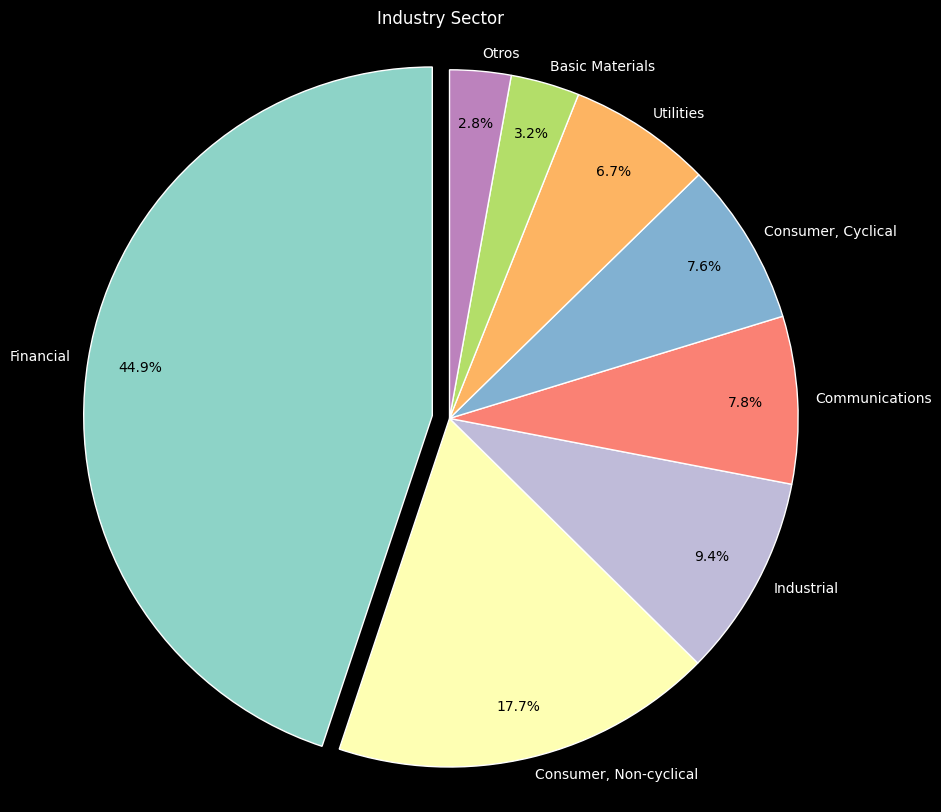

In [11]:
# ¿A qué principales sectores pertenecen los bonos estudiados? Casi el 45% al sector financiero
pie_chart_con_otros(universo, 'Industry Sector', umbral=0.03)

> <u>Sectores</u>: El universo está bastante concentrado en el sector financiero (44,9%), seguido de consumo no cíclico e industrial. Esta predominancia es habitual en bonos corporativos europeos, dado el peso de bancos y aseguradoras como emisores. Uno de los objetivos de la práctica es construir carteras diversificadas, sin embargo esta concentración sectorial puede hacer que lograr diversificación completa sea más complicado.

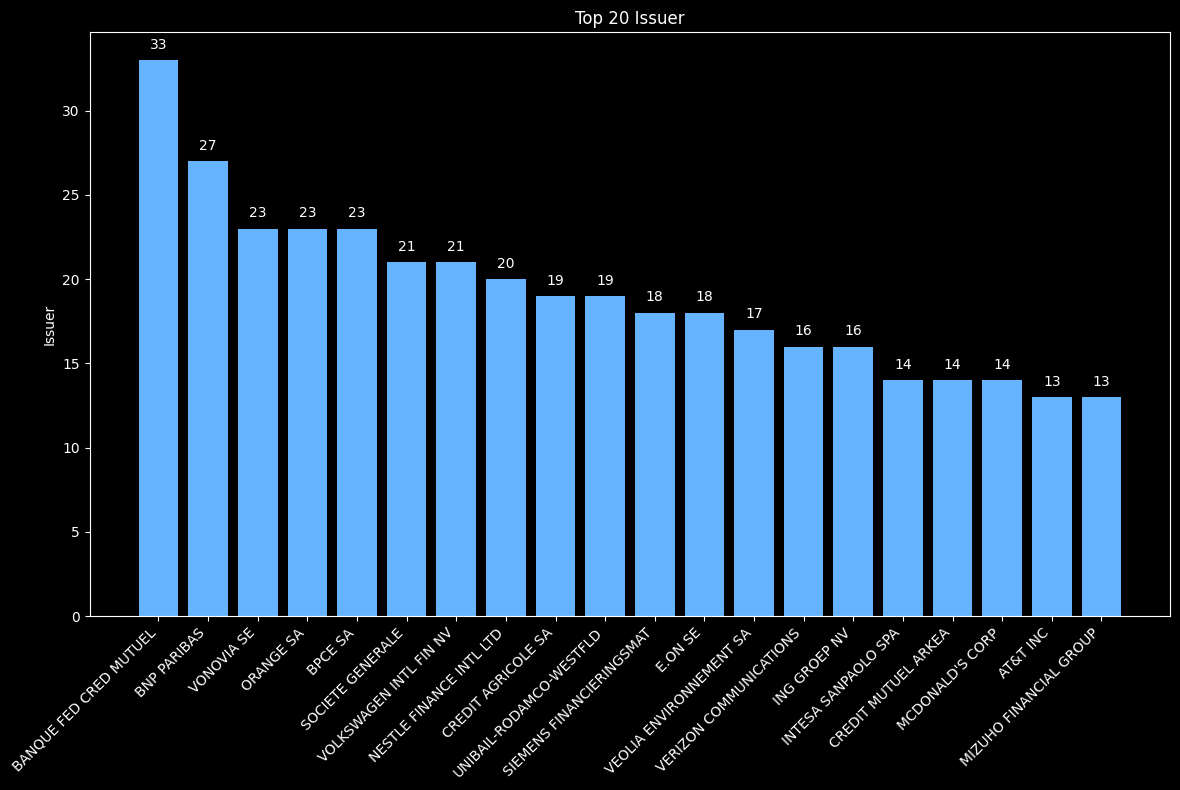

In [12]:
# ¿Cuáles son los principales emisores de los bonos estudiados? Destaca el banco francés BFCM
bar_plot_top_n_auto(universo, 'Issuer', top_n=20)

> <u>Emisores</u>: Los cinco emisores con mayor número de emisiones son Banque Fédérale Crédit Mutuel (33), BNP Paribas (27), Vonovia SE (23), Orange SA (23) y BPCE SA (23). Predominan emisores del sector financiero (los tres primeros y BPCE SA) y del sector comunicaciones (Orange SA). Esta concentración en unos pocos emisores refleja un riesgo de exposición significativa por entidad, lo que debería tenerse en cuenta al diseñar carteras diversificadas dentro del universo.

### <font color=#336699>**1.5. RIESGO DE CRÉDITO (RATINGS)**</font>

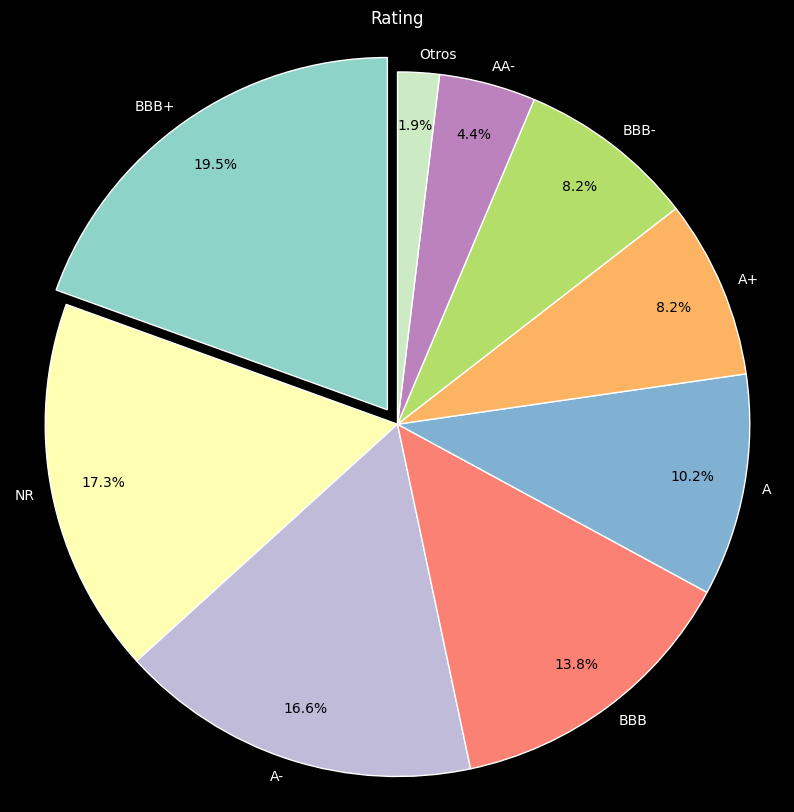

In [13]:
# ¿Qué tipos de rating tienen la mayoría de los bonos estudiados? Casi el 20% son BBB+
pie_chart_con_otros(universo, 'Rating', umbral=0.03)

> <u>Riesgo de Crédito</u>: El universo muestra una predominancia de emisiones con rating intermedio, lideradas por BB+ (19,5%), NR (17,3%) y A- (16,6%), seguidas de BBB (13,8%) y A (10,2%). La distribución indica que la mayoría de los bonos se sitúan en el rango de investment grade medio, con una porción menor en alta calidad o high yield. Esta composición es relevante para la construcción de carteras, ya que condiciona tanto el perfil de riesgo de crédito como la posible diversificación dentro del universo.

### <font color=#336699>**1.6. RIESGO DE LIQUIDEZ**</font>

#### <font color=#808080>1.6.1. Horquilla: Bid-Ask Spread (%)</font>

,Description,Ccy,Price,Issuer,Industry Sector,Maturity,Coupon,Rating,PD 1YR,Outstanding Amount,...,Seniority,Coupon Frequency,Coupon Type,First Coupon Date,Penultimate Coupon Date,Issue date,Bid Price,Ask Price,Bid-Ask Spread,Bid-Ask Spread %
ISIN,,,,,,,,,,,,,,,,,,,,,
XS0161488498,DT 7 ½ 01/24/33,EUR,127.8353,DEUTSCHE TELEKOM INT FIN,Communications,24/01/2033,7.500,BBB+,0.021966,500000000,...,Sr Unsecured,1,FIXED,24/01/2004,24/01/2032,24/01/2003,127.462,128.208,0.746,0.581867
FR0000471930,ORAFP 8 ⅛ 01/28/33,EUR,131.3195,ORANGE SA,Communications,28/01/2033,8.125,BBB+,0.000021,1500000000,...,Sr Unsecured,1,FIXED,28/01/2004,28/01/2032,28/01/2003,130.991,131.648,0.657,0.499058
XS0162513211,EOANGR 5 ¾ 02/14/33,EUR,115.7800,E.ON INTL FINANCE BV,Utilities,14/02/2033,5.750,BBB+,0.000101,600000000,...,Sr Unsecured,1,FIXED,14/02/2004,14/02/2032,14/02/2003,115.447,116.114,0.667,0.574435
XS0162869076,TELEFO 5 ⅞ 02/14/33,EUR,116.3000,TELEFONICA EUROPE BV,Communications,14/02/2033,5.875,BBB-,0.000125,500000000,...,Sr Unsecured,1,FIXED,14/02/2004,14/02/2032,14/02/2003,115.984,116.616,0.632,0.541950
FR0010014845,PEUGOT 6 09/19/33,EUR,112.3887,PSA TRESORERIE GIE,"Consumer, Cyclical",19/09/2033,6.000,BBB,0.024240,600000000,...,Sr Unsecured,1,FIXED,19/09/2004,19/09/2032,19/09/2003,111.839,112.938,1.099,0.973100


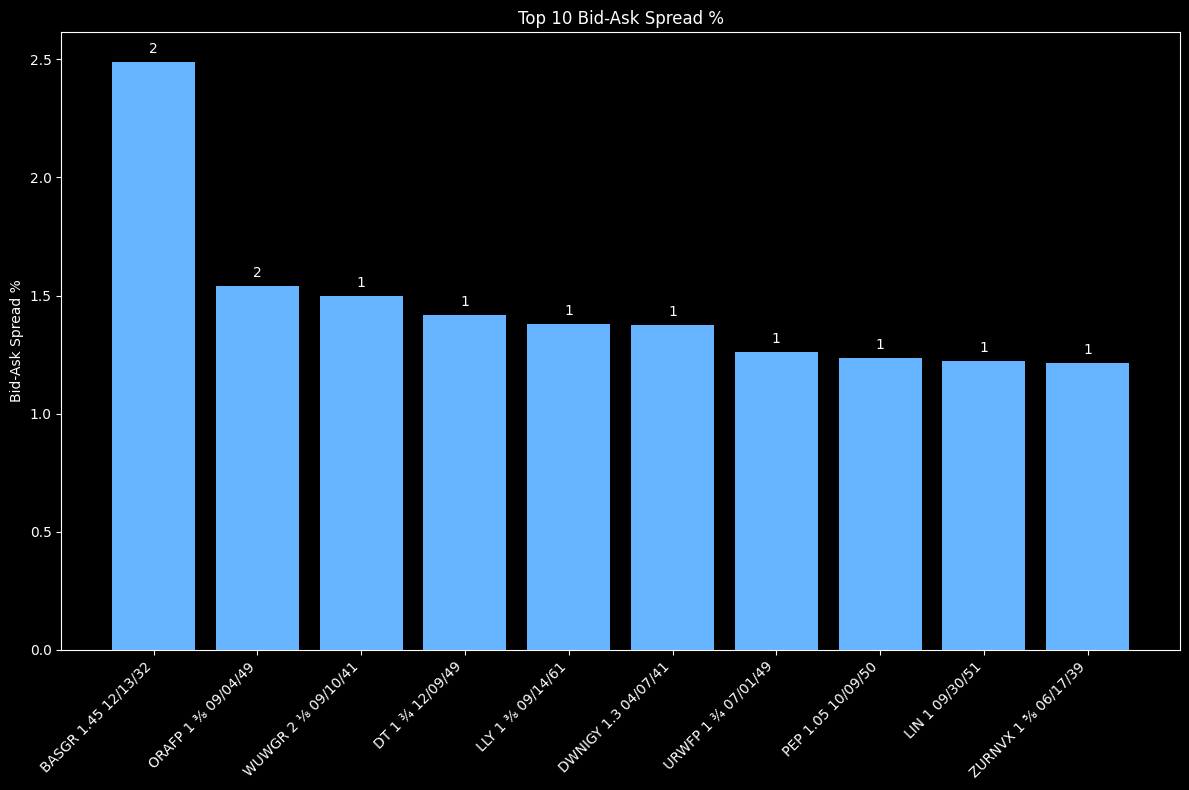

In [14]:
# Cálculo de la horquilla
universo['Bid-Ask Spread'] = universo['Ask Price'] - universo['Bid Price']  # diferencia absoluta
universo['Bid-Ask Spread %'] = (universo['Ask Price'] - universo['Bid Price']) / universo['Ask Price'] *100  # porcentaje
display(universo.head()) # Dataframe con universo

# ¿Qué bonos tienen una mayor horquilla? Los bonos con mayor horquilla son los de BASOR
bar_plot_top_n_auto(universo, 'Bid-Ask Spread %', top_n=10, label_col='Description') # barplot

> <u>Horquilla</u>: En general, los bonos del universo muestran spreads bid-ask moderados, siendo el mayor BASGR 1.45 12/13/32 con un 2,5%, seguido de emisiones como ORAF y WUWGR cercanas al 1,5%. Esto indica que la mayoría de los bonos son relativamente líquidos, aunque algunas emisiones presentan menor profundidad de mercado, lo que debe tenerse en cuenta al construir y ajustar carteras.

#### <font color=#808080>1.6. Nominal Vivo</font>

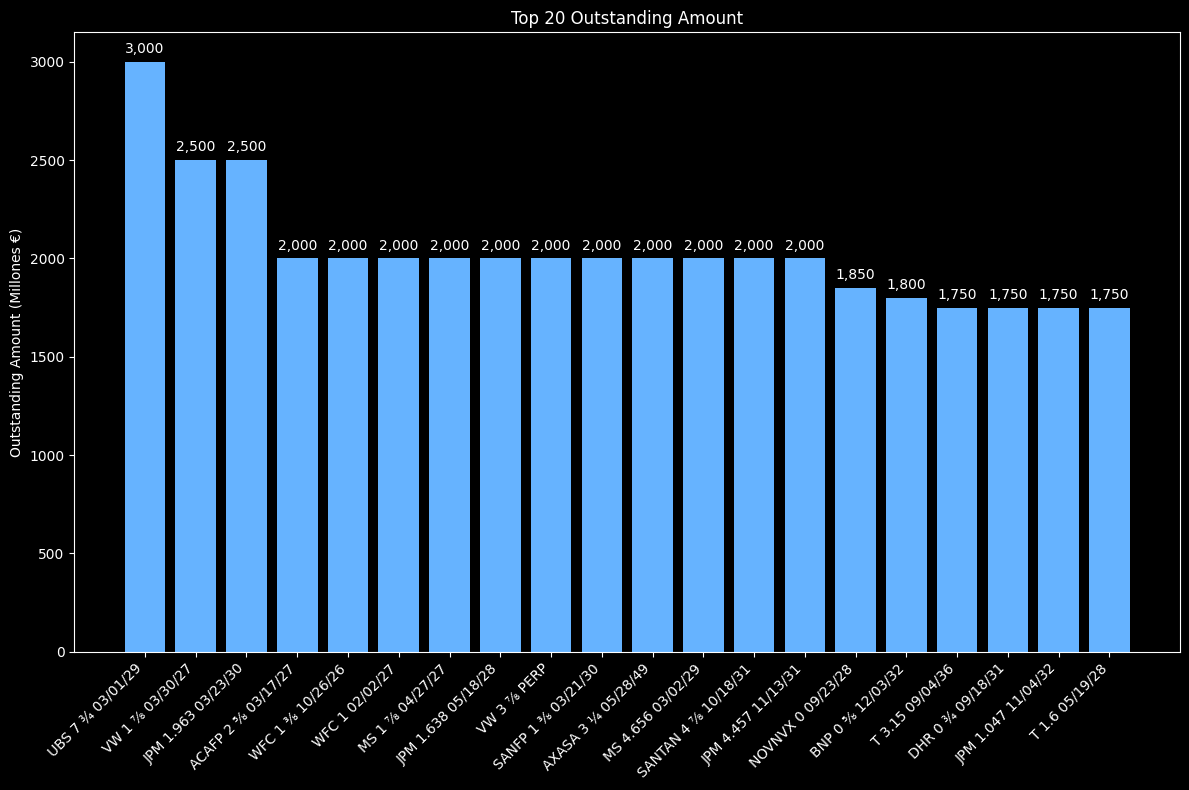

In [15]:
# ¿Qué tipo de bonos tinene más volumen en circulación? Los bonos de UBS
bar_plot_top_n_auto(universo, 'Outstanding Amount', top_n=20, label_col='Description')

> <u>Nominal Vivo</u>: Los bonos con mayor tamaño en circulación corresponden a UBS (3.000 M), Volkswagen (2.500 M) y JPMorgan (2.500 M), mientras que el resto de las 20 emisiones más grandes se sitúa más o menos alrededor de 2.000 M. Esto indica que, en general, el universo cuenta con emisiones relativamente grandes y líquidas, aunque sigue siendo importante controlar la concentración por emisor al construir carteras. Destaca también, una vez más, la importancia del sector financiero en este universo de bonos.

### <font color=#336699>**1.7. RESTO DE INFORMACIÓN**</font>

En esta sección, analizamos el resto de ficheros para ver qué información tenemos y, en caso de haber *gaps*, limpiar los datos antes de trabajar con ellos.

##### <font color=#CC6600>**1.7.1. Precios bonos universo**</font>

**Resumen de la Limpieza del Dataset 'precios_historicos_universo.csv'**

1) <u>Eliminación de fechas vacías</u>: Se eliminaron todas las fechas (columnas) en las que ningún bono tenía precio registrado, correspondientes a días sin negociación. Rellenarlas con forward fill implicaría inventar precios para un día sin transacciones ni cotizaciones observables, lo que no refleja la realidad del mercado; por eso se eliminaron estas columnas.

2) <u>Mantenimiento de huecos iniciales</u>: Se conservaron los NaN al inicio de cada bono, que representan el periodo antes de su primera cotización. De esta manera, los cálculos de spreads y rendimientos se realizan únicamente sobre fechas con datos disponibles, respetando la realidad de la negociación de cada bono.

3) <u>Eliminación de bonos con muchos NaNs consecutivos</u>: Se eliminaron los bonos con huecos largos (más de 5 fechas consecutivas de NaNs a partid de su primer registro), ya que la falta de datos continuos impide obtener rendimientos y spreads representativos y dificulta comparaciones y análisis fiables para carteras. En el dataset actual, solo dos bonos fueron eliminados por esta razón (`bonos_filtrados_df`). Presentaban 14 y 16 fechas consecutivas de NaNs.

4) <u>Forward fill de huecos internos pequeños</u>: Por último, para los huecos internos (pequeños) de cada bono, se aplicó forward fill. Este método rellena los valores faltantes con el último precio conocido. Este procedimiento sí es realista, porque en bonos poco líquidos es razonable asumir que el precio no cambió hasta la siguiente fecha con negociación. Forward fill solo se utiliza dentro de la serie de un bono donde ya hay datos, y nunca antes del primer precio ni después del último, asegurando que no se inventa información que no existió.

> En conclusión, la limpieza del dataset asegura que los datos reflejen fielmente la realidad del mercado. Esto permite calcular spreads, rendimientos y métricas de riesgo de forma consistente y fiable para análisis de carteras.



**A) Carga y Fromateo del Dataset 'precios_historicos_universo.csv'**

In [16]:
# Cargamos 'precios_historicos_universo.csv'
BASE_DIR = Path().resolve().parent
csv_path = BASE_DIR / 'data' / 'precios_historicos_universo.csv'
precios_historicos_universo = pd.read_csv(csv_path, sep=';', low_memory=False, index_col=0)

# Reeplazamos '#N/D' por NaN
pd.set_option('future.no_silent_downcasting', True)                # Evita warnings innecesarios
precios_historicos_universo.replace('#N/D', np.nan, inplace=True)  # Reemplaza '#N/D' por NaN
precios_universo = precios_historicos_universo.copy()              # Creamos una copia por seguridad

# Ajustamos el formato de la tabla para facilitar el análisis+
precios_universo = precios_universo.T # Traspone para mostrar las fechas como filas (estándar para series temporales de precios)
precios_universo.index = pd.to_datetime(precios_universo.index, format='%d/%m/%Y', errors='coerce') # convertimos el índice a tipo DateTime
precios_universo.sort_index(inplace=True) # Nos aseguramos de que el índice temporal esté ordenado
precios_universo = precios_universo[~precios_universo.index.isna()]

# Nos aseguramos de que los valores son de tipo float
for col in precios_universo.columns:
    precios_universo[col] = pd.to_numeric(precios_universo[col], errors='coerce') # errors='coerce' convertirá a NaN cualquier valor que no sea numérico

# Mostrar resultados
print(f"Precios universo: {precios_universo.shape[0]} fechas x {precios_universo.shape[1]} bonos")
precios_universo.head()

Precios universo: 732 fechas x 2255 bonos


,XS0161488498 Corp,FR0000471930 Corp,XS0162513211 Corp,XS0162869076 Corp,FR0010014845 Corp,FR0010033381 Corp,XS0229567440 Corp,XS0300113254 Corp,XS0350890470 Corp,XS0553728709 Corp,...,XS2726335099 Corp,FR001400MDV4 Corp,XS2728560959 Corp,XS2728561098 Corp,XS2729836234 Corp,XS2724401588 Corp,XS2731506841 Corp,FR001400MLN4 Corp,XS2732952838 Corp,XS2694995163 Corp
2023-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-02,126.450,130.386,110.900,112.493,108.291,116.197,97.257,103.831,113.487,103.788,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-03,126.000,129.697,110.567,112.127,107.608,115.831,96.548,103.716,112.907,103.490,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-04,125.939,129.448,110.719,111.844,108.047,115.949,96.548,103.749,113.374,103.024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-05,126.330,129.795,111.117,112.191,108.480,116.305,97.201,103.907,113.929,103.273,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**B) Análisis Exploratorio de NaNs**

In [17]:
# Porcentaje de NaNs por fila (resumen)
nans_por_fila = precios_universo.isna().sum(axis=1).to_frame(name='NaNs_por_fila')
nans_por_fila['%_NaNs'] = (nans_por_fila['NaNs_por_fila'] / precios_universo.shape[1]) * 100
filas_con_nans = nans_por_fila[nans_por_fila['NaNs_por_fila'] > 0]

# Porcentaje de NaNs por columna (resumen)
nans_por_col = precios_universo.isna().sum().to_frame(name='NaNs_por_columna')
nans_por_col['%_NaNs'] = (nans_por_col['NaNs_por_columna'] / len(precios_universo)) * 100
columnas_con_nans = nans_por_col[nans_por_col['NaNs_por_columna'] > 0]

# Mostrar tablas y ordenar por bonos con % NaNs descendentes
print(f"\nFilas con NaNs: {len(filas_con_nans)} / {precios_universo.shape[0]}")
display(filas_con_nans.sort_values('%_NaNs', ascending=False).head(10))
print(f"Columnas con NaNs: {len(columnas_con_nans)} / {precios_universo.shape[1]}")
display(columnas_con_nans.sort_values('%_NaNs', ascending=False).head(10))


Filas con NaNs: 299 / 732


,NaNs_por_fila,%_NaNs
2025-09-28,2255,100.0
2023-10-01,2255,100.0
2025-09-27,2255,100.0
2025-09-21,2255,100.0
2025-09-20,2255,100.0
2025-09-14,2255,100.0
2025-07-20,2255,100.0
2025-07-19,2255,100.0
2025-07-13,2255,100.0
2025-07-12,2255,100.0


Columnas con NaNs: 2255 / 2255


,NaNs_por_columna,%_NaNs
XS2732952838 Corp,270,36.885246
XS2694995163 Corp,267,36.475410
XS2724401588 Corp,266,36.338798
XS2731506841 Corp,265,36.202186
FR001400MLN4 Corp,265,36.202186
FR001400MDV4 Corp,262,35.792350
XS2729836234 Corp,262,35.792350
XS2728561098 Corp,262,35.792350
XS2698045130 Corp,261,35.655738
XS2728560959 Corp,261,35.655738


**C) Eliminación de Fechas Vacías**

In [18]:
# Eliminamos las filas (fecha) que estén totalmente vacías
filas_vacias = precios_universo.index[precios_universo.isna().all(axis=1)].tolist() # Lista de filas totalmente vacías
precios_universo = precios_universo.dropna(axis=0, how='all') # Eliminar filas vacías
print(f"Un total de {len(filas_vacias)} filas (fechas) totalmente vacías han sido eliminadas")

Un total de 209 filas (fechas) totalmente vacías han sido eliminadas


**D) Eliminación de Bonos con Muchos NaNs Consecutivos**

In [19]:
# Analizamos qué bonos tienen muchos NaNs consecutivos
# (a partid del primer precio disponible)

x = 5  # número de fechas consecutivas sin precio que queremos detectar

def max_nan_after_first(col):
    # Encontrar el índice del primer precio no nulo
    first_idx = col.first_valid_index()
    if first_idx is None:
        return 0
    # Tomar solo los valores desde el primer precio en adelante
    vals = col.loc[first_idx:]
    # Contar la racha máxima de NaN consecutivos
    max_count = count = 0
    for v in vals:
        if pd.isna(v):
            count += 1
            max_count = max(max_count, count)
        else:
            count = 0
    return max_count

# Aplicamos a cada columna (bono)
max_consec_nan = precios_universo.apply(max_nan_after_first, axis=0)

# Filtramos bonos que tengan más de x fechas consecutivas sin precio
bonos_filtrados = max_consec_nan[max_consec_nan > x]

# Convertimos a DataFrame para mejor visualización
bonos_filtrados_df = pd.DataFrame(bonos_filtrados, columns=['Max_Consec_NaN'])

print("Bonos con más de", x, "fechas consecutivas sin precio desde su primer valor:")
display(bonos_filtrados_df)

# Suma del número de bonos que cumplen la condición
total_bonos = bonos_filtrados_df.shape[0]
print("Número total de bonos con esas características:", total_bonos)


# Eliminamos los bonos con más de x fechas consecutivas sin precio del dataset

# Obtenemos la lista de bonos a eliminar
bonos_a_eliminar = bonos_filtrados_df.index.tolist()

# Creamos un nuevo DataFrame sin estos bonos
precios_universo = precios_universo.drop(columns=bonos_a_eliminar)

print(f"\nSe eliminaron {len(bonos_a_eliminar)} bonos con huecos largos.")
print(f"Nuevo dataset: Fechas = {precios_universo.shape[0]}, Bonos = {precios_universo.shape[1]}")

Bonos con más de 5 fechas consecutivas sin precio desde su primer valor:


,Max_Consec_NaN
XS2049582625 Corp,14
XS2698045130 Corp,16


Número total de bonos con esas características: 2

Se eliminaron 2 bonos con huecos largos.
Nuevo dataset: Fechas = 523, Bonos = 2253


**E) Forward Fill de Huecos Internos Pequeños**

In [20]:
# Asumimos que si un bono no cotiza un día es porque mantiene el precio del día anterior
precios_universo.ffill(axis=0, inplace=True)

# Mostramos el DataFrame limpio
print(f"DataFrame 'precios_historicos_universo.csv' limpio: {precios_universo.shape[0]} fechas x {precios_universo.shape[1]} bonos")
precios_universo.head()

DataFrame 'precios_historicos_universo.csv' limpio: 523 fechas x 2253 bonos


,XS0161488498 Corp,FR0000471930 Corp,XS0162513211 Corp,XS0162869076 Corp,FR0010014845 Corp,FR0010033381 Corp,XS0229567440 Corp,XS0300113254 Corp,XS0350890470 Corp,XS0553728709 Corp,...,XS2726335099 Corp,FR001400MDV4 Corp,XS2728560959 Corp,XS2728561098 Corp,XS2729836234 Corp,XS2724401588 Corp,XS2731506841 Corp,FR001400MLN4 Corp,XS2732952838 Corp,XS2694995163 Corp
2023-10-02,126.450,130.386,110.900,112.493,108.291,116.197,97.257,103.831,113.487,103.788,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-03,126.000,129.697,110.567,112.127,107.608,115.831,96.548,103.716,112.907,103.490,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-04,125.939,129.448,110.719,111.844,108.047,115.949,96.548,103.749,113.374,103.024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-05,126.330,129.795,111.117,112.191,108.480,116.305,97.201,103.907,113.929,103.273,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-06,126.117,129.554,111.036,112.051,108.277,116.173,97.171,103.919,113.891,103.161,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### <font color=#CC6600>**1.7.2. Otros precios**</font>

**Justificación sobre el Tratamiento de NaNs de 'precios_varios_csv'**

En el análisis realizado, hemos observado que los datos faltantes (NaN) en los instrumentos financieros auxiliares (CDS y commodities) ocurren en bloques por grupo:

- Los índices de crédito (`ITRX EUR CDSI GEN 5Y Corp` y `ITRX XOVER CDSI GEN 5Y Corp`) presentan NaNs simultáneamente en ciertas fechas.  
- Los futuros de tipos de interés (`DU1 Comdty`, `OE1 Comdty`, `RX1 Comdty`) también presentan NaNs simultáneamente en ciertas fechas.  
- El índice `RECMTREU` está completo y no presenta NaNs.

Se ha decidido no modificar estos NaNs (ni rellenarlos ni eliminar las filas del DataFrame) por las siguientes razones:

1. <u>Representatividad de los datos</u>: Los NaNs reflejan días sin cotización real en los mercados, no errores de la base de datos. Por ello, rellenarlos con forward fill crearía valores artificiales que no existen en la realidad.

2. <u>Organización y alineación</u>: Mantener todos los instrumentos en un único DataFrame facilita la alineación temporal entre grupos, permite realizar análisis conjuntos de cobertura y benchmarking, y evita duplicación de operaciones o desalineación que surgiría al separar los grupos en DataFrames distintos.

3. <u>Aplicación práctica en el análisis</u>: Los instrumentos auxiliares se usarán activamente para cálculos de cobertura y benchmarking. Mantener los NaNs intactos asegura que todas las métricas se calculen únicamente sobre días con datos disponibles, preservando la validez de spreads, correlaciones y otros indicadores financieros.

 > En conclusión, mantener los NaNs intactos es la opción más conservadora y correcta desde un punto de vista financiero y analítico, garantizando que los datos reflejen fielmente los días de cotización real y evitando sesgos en los análisis de backtesting y cobertura.


**A) Carga y Formateo de 'precios_varios.csv'**

In [21]:
# Cargamos los datos de 'precios_varios.csv'
BASE_DIR = Path().resolve().parent
csv_path = BASE_DIR / 'data' / 'precios_historicos_varios.csv'
precios_historicos_varios = pd.read_csv(csv_path, sep=';', low_memory=False, index_col=0)
precios_varios = precios_historicos_varios.copy() # Copia de seguridad

# Fromateo de los datos
precios_varios.index = pd.to_datetime(precios_varios.index, format='%d/%m/%Y', errors='coerce') # convertimos el índice a tipo DateTime
precios_varios.sort_index(inplace=True) # Nos aseguramos de que el índice temporal esté ordenado
precios_varios = precios_varios[~precios_varios.index.isna()]

for col in precios_varios.columns:                                            # Nos aseguramos de que los valores son de tipo float
    precios_varios[col] = pd.to_numeric(precios_varios[col], errors='coerce') # errors='coerce' convertirá a NaN cualquier valor que no sea numérico

total_nans = precios_varios.isna().sum().sum() # Porcentaje de NaNs en el dataset

# Mostrar resultados
print(f"Total de NaNs en todo el dataset: {total_nans}\n")
print("DataFrame 'Precios_históricos_varios.csv':")
precios_varios.head()

Total de NaNs en todo el dataset: 31

DataFrame 'Precios_históricos_varios.csv':


,ITRX EUR CDSI GEN 5Y Corp,ITRX XOVER CDSI GEN 5Y Corp,DU1 Comdty,OE1 Comdty,RX1 Comdty,RECMTREU Index
2023-10-02,82.44325,439.1052,104.930,115.43,127.75,149.0285
2023-10-03,86.04738,455.2537,104.965,115.33,127.28,148.8003
2023-10-04,85.58153,453.8545,104.990,115.35,127.37,148.5200
2023-10-05,87.82574,461.1187,105.095,115.73,128.07,148.8967
2023-10-06,85.57082,453.6750,105.105,115.72,127.94,148.7697


**B) Análisis de NaNs por Tipo de Instrumento**

In [22]:
# Definimos grupos por tipo de instrumento financiero
grupo_cds = ['ITRX EUR CDSI GEN 5Y Corp', 'ITRX XOVER CDSI GEN 5Y Corp'] # CDS
grupo_comdty = ['DU1 Comdty', 'OE1 Comdty', 'RX1 Comdty'] # Commodities
grupo_recmtreu = ['RECMTREU Index'] # RECMTREU

grupos = {
    'CDS': grupo_cds,
    'Commodities': grupo_comdty,
    'RECMTREU': grupo_recmtreu
}

# Iteramos por los grupos
for nombre, columnas in grupos.items():
    # Filtramos filas donde haya al menos un NaN en el grupo
    mask = precios_varios[columnas].isna().any(axis=1)
    df_nan = precios_varios.loc[mask, columnas]  # Seleccionamos solo las columnas del grupo
    
    print(f"\n{nombre}:")
    if df_nan.empty:
        print("\nNo hay fechas con NaNs en este grupo.")
    else:
        display(df_nan)  # Mostrar DataFrame



CDS:


,ITRX EUR CDSI GEN 5Y Corp,ITRX XOVER CDSI GEN 5Y Corp
2024-05-06,NaN,NaN
2024-05-27,NaN,NaN
2024-08-26,NaN,NaN
2025-04-18,NaN,NaN
2025-04-21,NaN,NaN
2025-05-05,NaN,NaN
2025-05-26,NaN,NaN
2025-08-25,NaN,NaN



Commodities:


,DU1 Comdty,OE1 Comdty,RX1 Comdty
2024-05-01,NaN,NaN,NaN
2024-12-31,NaN,NaN,NaN
2025-04-18,NaN,NaN,NaN
2025-04-21,NaN,NaN,NaN
2025-05-01,NaN,NaN,NaN



RECMTREU:

No hay fechas con NaNs en este grupo.


**C) Gráfico de 'precios_varios.csv'**

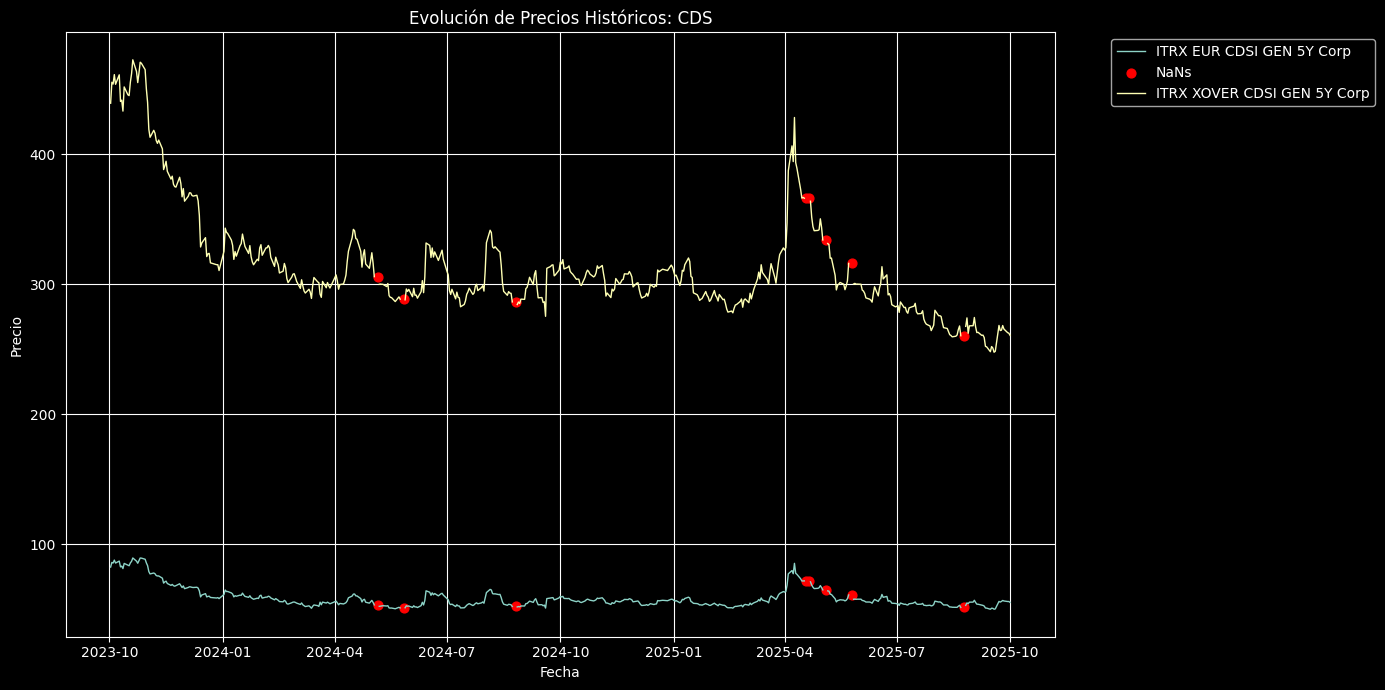

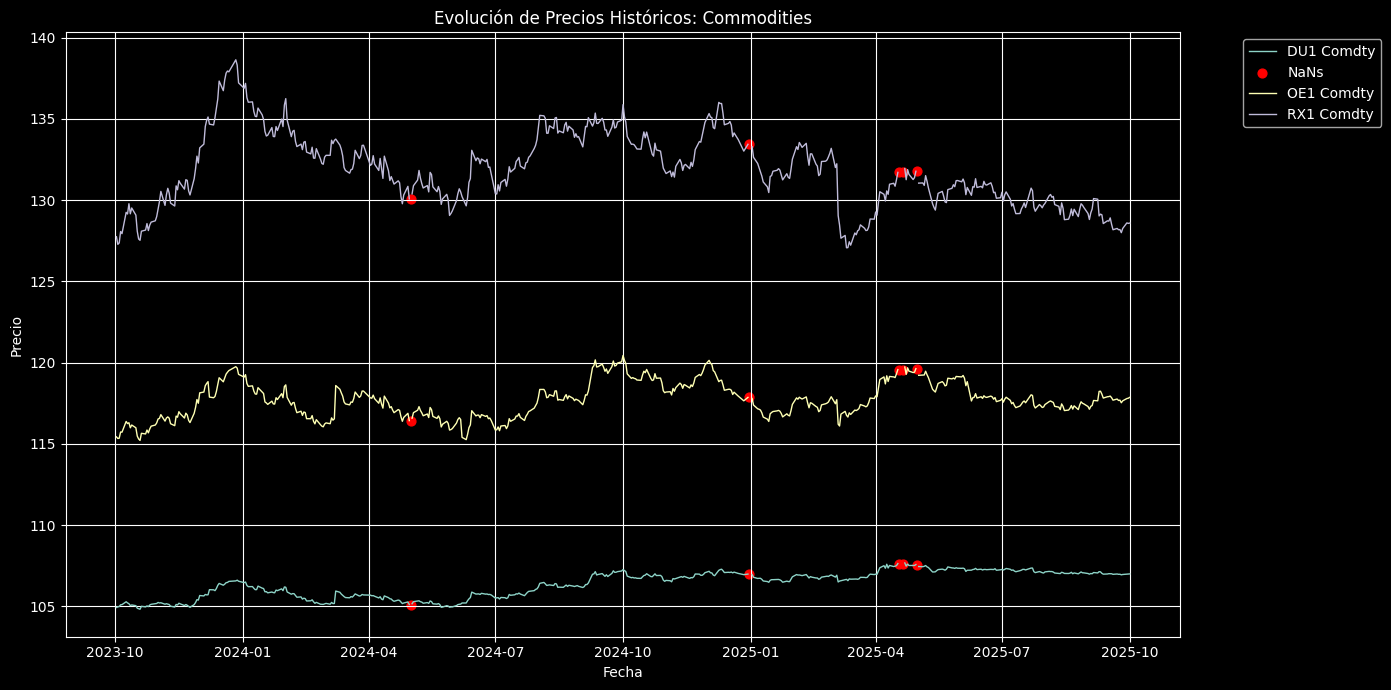

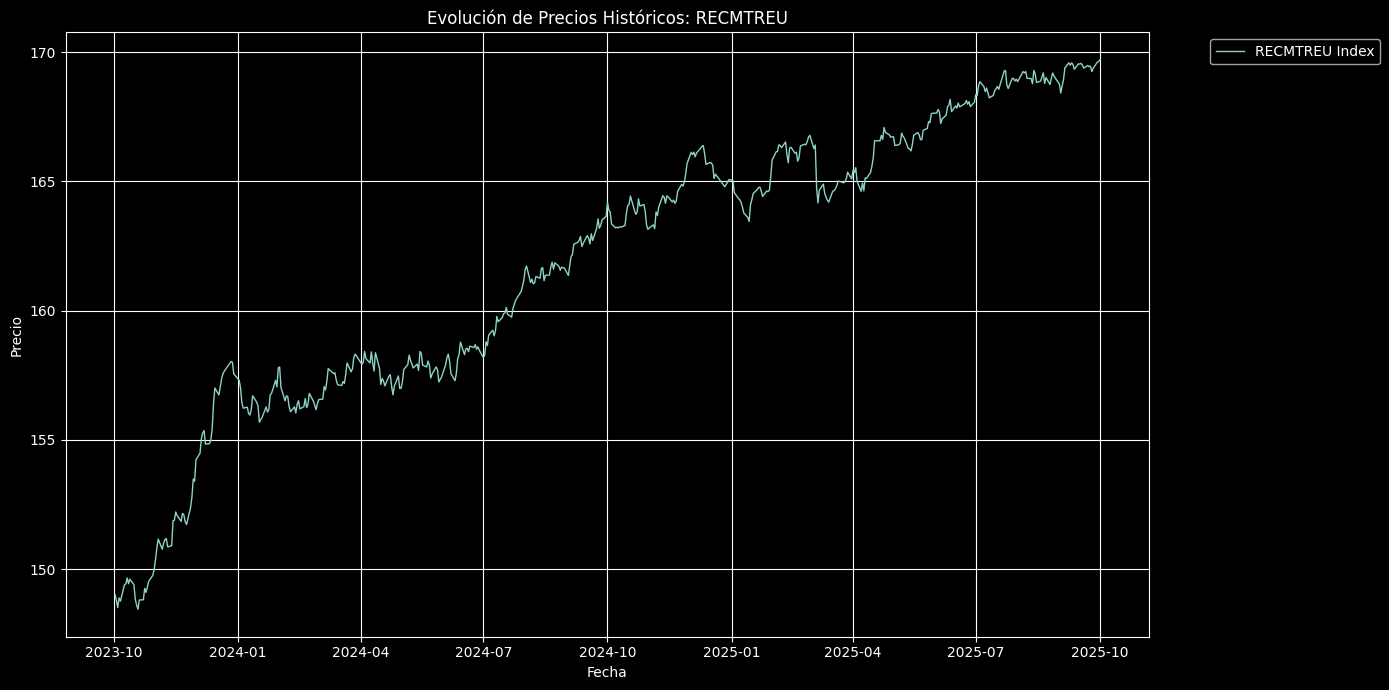

In [23]:
# Graficamos las series de precio por tipos de instrumento financiero
# Representamos como puntos rojos los NaNs
# Se ve claramente que son iguales para los mismos tipos de instrumento

# Iteramos por los grupos y generamos un gráfico por cada uno
for nombre, columnas in grupos.items():
    plt.figure(figsize=(14,7))
    
    # Filtramos solo las columnas del grupo
    for col in columnas:
        series = precios_varios[col]
        plt.plot(series.index, series, label=col, linewidth=1)
        
        # Encontramos los NaNs
        nan_mask = series.isna()
        if nan_mask.any():
            # Para cada NaN, usamos el último valor conocido antes del NaN
            last_valid = series.ffill()  # forward fill temporal para marcar el punto
            plt.scatter(series.index[nan_mask], last_valid[nan_mask], 
                        color='red', marker='o', s=40, label=f'NaNs' if col==columnas[0] else "")
    
    # Etiquetas y título
    plt.xlabel('Fecha')
    plt.ylabel('Precio')
    plt.title(f'Evolución de Precios Históricos: {nombre}')
    plt.grid(True)
    
    # Leyenda fuera del gráfico
    plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize='medium')
    
    # Ajustar diseño para que la leyenda no se corte
    plt.tight_layout()
    
    # Mostrar gráfico
    plt.show()


> Comentarios de los gráficos anteriores:
>
>- <u>Gráfico CDS</u>: El gráfico muestra la evolución histórica de dos índices de CDS con perfiles de riesgo claramente diferenciados: uno de menor riesgo, con spreads más bajos y estables, y otro de mayor riesgo, más volátil y con niveles considerablemente superiores. Esta diferencia estructural se aprecia de forma consistente en toda la ventana temporal, lo que confirma que ambos índices responden a segmentos distintos del mercado crediticio
>
> - <u>Gráfico Commodities</u>: El gráfico de commodities muestra tres series con niveles y volatilidades distintas, pero con patrones muy similares entre sí: ascensos a principios de 2024, estabilización a lo largo del año y correcciones moderadas en 2025. Las diferencias entre curvas están más asociadas a su nivel estructural que a dinámicas divergentes, lo que sugiere que capturan factores comunes del mercado de materias primas.
>
> - <u>Gráfico RECMTREU</u>: El índice RECMTREU muestra una trayectoria claramente ascendente durante todo el periodo, con una evolución muy estable y sin grandes oscilaciones. Esto encaja con su naturaleza: es un índice de retorno total de crédito europeo, que incluye los cupones además de los precios. Por ello suele crecer de forma sostenida salvo en momentos de estrés severo del mercado. Su comportamiento sirve como referencia del rendimiento agregado del crédito europeo.
>
> - <u>Presencia de NaNs</u>: Los NaNs de las series de CDS y commodities probablemente se deban a días sin cotización o sin actualización del proveedor de datos, típicos en mercados con distinta liquidez o con calendarios específicos (festivos, cierres parciales, días sin negociación del subyacente, o retrasos en la publicación del fixing). En instrumentos como CDS, además, puede ocurrir que en algunos días no haya transacciones y el índice no se actualice.
>   En cambio, el RECMTREU, al ser un índice agregando bonos (y calculado de forma sistemática), suele publicarse diariamente sin interrupciones, lo que explica la ausencia de NaNs.

##### <font color=#CC6600>**1.7.3. Curva ESTR**</font>

**Justificación sobre el Tratamiento de NaNs de 'curva_ESTR.csv'**

En la primera fila del DataFrame de la curva ESTR (`curva_ESTR.csv`) aparecen NaNs en las columnas de Market Rate y Zero Rate porque corresponde a la fecha spot, donde el factor de descuento es 1 y no existe un instrumento de mercado que determine directamente una tasa. 

> Hemos decidido dejar estos NaN tal cual, ya que representan correctamente la realidad financiera.

**A) Carga, Formateo y Limpieza de 'curva_ESTR.csv'**

In [24]:
# Cargamos los datos de la 'curva_ESTR.csv'
BASE_DIR = Path().resolve().parent
csv_path = BASE_DIR / 'data' / 'curvaESTR.csv'
curva_ESTR_csv = pd.read_csv(csv_path, sep=';', index_col=0)
curva_ESTR = curva_ESTR_csv.copy()

# Formateamos el DataFrame
curva_ESTR.index = pd.to_datetime(curva_ESTR.index, format='%d/%m/%Y', errors='coerce')  # Convertimos el índice a DateTime
curva_ESTR.sort_index(inplace=True)  # Aseguramos que el índice temporal esté ordenado
curva_ESTR = curva_ESTR[~curva_ESTR.index.isna()]  # Eliminamos filas con fechas inválidas

for col in curva_ESTR.columns:                             # Nos aseguramos de que los valores sean numéricos
    curva_ESTR[col] = pd.to_numeric(curva_ESTR[col], errors='coerce')  # Convierte valores no numéricos a NaN

# Total de NaNs en el dataset
total_nans = curva_ESTR.isna().sum().sum()

# Mostrar resultados
print(f"Total de NaNs en todo el dataset: {total_nans}\n")
print("DataFrame 'curva_ESTR.csv':")
curva_ESTR.head()


Total de NaNs en todo el dataset: 2

DataFrame 'curva_ESTR.csv':


,Market Rate,Zero Rate,Discount
Date,,,
2025-10-01,NaN,NaN,1.000000
2025-10-10,1.927,1.95350,0.999518
2025-10-17,1.928,1.95402,0.999144
2025-11-03,1.928,1.95320,0.998236
2025-12-03,1.929,1.95264,0.996635


**B) Gráfico de 'curva_ESTR_csv'**

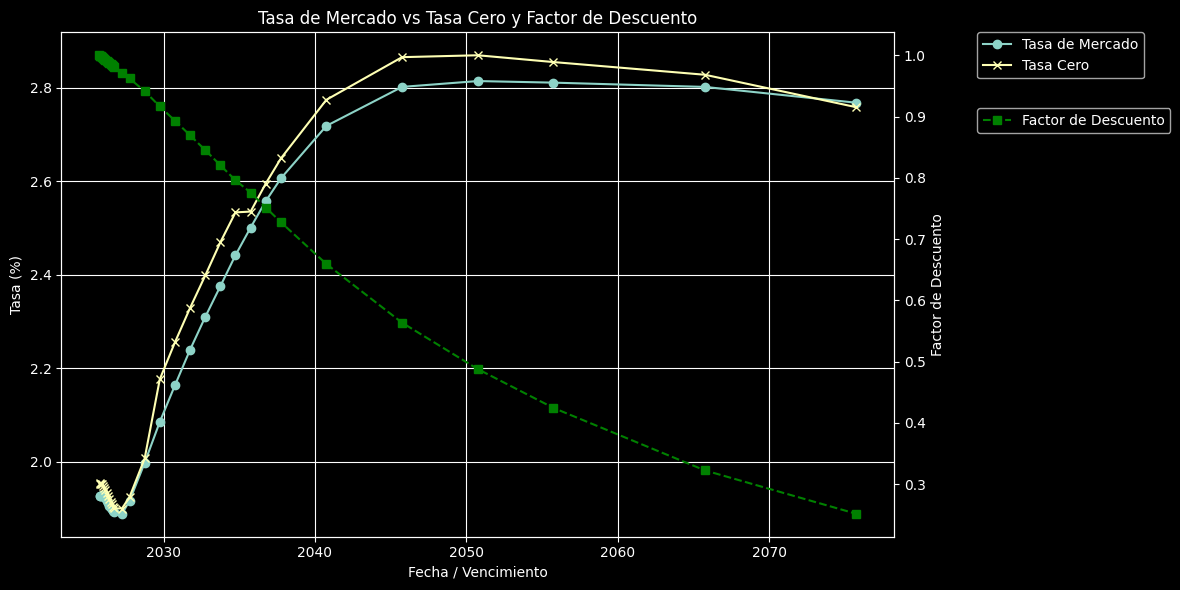

In [25]:
# Visualizamos el DataFrame anterior para comprender mejor los datos

# Crear figura y eje principal
fig, ax1 = plt.subplots(figsize=(12,6))

# Graficar Market Rate y Zero Rate en el eje Y izquierdo
ax1.plot(curva_ESTR.index, curva_ESTR['Market Rate'], label='Tasa de Mercado', marker='o')
ax1.plot(curva_ESTR.index, curva_ESTR['Zero Rate'], label='Tasa Cero', marker='x')
ax1.set_xlabel('Fecha / Vencimiento')
ax1.set_ylabel('Tasa (%)')
ax1.set_title('Tasa de Mercado vs Tasa Cero y Factor de Descuento')
ax1.grid(True)

# Leyenda eje izquierdo fuera del gráfico
ax1.legend(loc='upper left', bbox_to_anchor=(1.10, 1), borderaxespad=0)

# Graficar Discount Factor en eje Y derecho
ax2 = ax1.twinx()
ax2.plot(curva_ESTR.index, curva_ESTR['Discount'], label='Factor de Descuento', color='green', linestyle='--', marker='s')
ax2.set_ylabel('Factor de Descuento')
ax2.legend(loc='upper left', bbox_to_anchor=(1.10, 0.85), borderaxespad=0)  # Leyenda eje derecho fuera del gráfico

# Ajustar diseño y mostrar
plt.tight_layout()
plt.show()

> <u>Gráfico de Tasas & Factor de Descuento</u> El gráfico anterior refleja cómo la estructura temporal de tasas se suaviza a medida que aumenta el plazo: tanto la tasa de mercado como la tasa cero muestran una pendiente inicialmente ascendente que luego se estabiliza, lo que sugiere expectativas de tipos relativamente constantes en el largo plazo. En contraste, el factor de descuento desciende de forma sostenida, mostrando cómo el valor presente de los flujos se reduce cada vez más conforme el vencimiento es más lejano. En conjunto, la figura ilustra un mercado que anticipa un entorno de tasas moderadas y estables en el largo plazo, mientras que el impacto del descuento crece de manera natural con el tiempo.

### <font color=#0099CC>**2. VALORACIÓN**</font>

<style>.gray {background-color: #595959}

</style><div class="gray">

❕💬 En esta sección, valoraremos los bonos utilizando la curva. Para ello, crea una función (puedes hacerlo en un .py aparte) que con las **características del bono, la curva y un spread de crédito** devuelva la valoración del bono (incluyendo **precio limpio, cupón corrido y precio sucio**).

Si asumimos que el **spread de crédito es 0**, y la ejecutamos para el 01/10/2025...
- ¿Qué observas si comparas los precios obtenidos y los precios de mercado? 
- ¿Crees que la diferencia se debe a un factor relacionado sólo con el riesgo crediticio?
- ¿Qué otros factores influyen en ese spread?

Para la valoración, haz las siguientes simplificaciones:

- Asume que el vencimiento de los bonos perpetuos (para los que no hay vencimiento) es la próxima fecha call.
- Asume que todos aquellos bonos que tengan call serán calleados. Por lo tanto, usa la fecha call como fecha de vencimiento.
- Asume que los cupones son fijos hasta vencimiento (aunque alguno cambie a lo largo de la vida del bono).
- Usa la base de cálculo ACT/365. No tengas en cuenta la convención de día hábil.

Ten en cuenta que necesitarás una función de interpolación también. Interpola los factores de descuento exponencialmente.

</div>

### <font color=#336699>**2.1. CÁLCULO DE LA VALORACIÓN**</font>

In [26]:
# Establecemos la fecha
fecha_valor = datetime(2025,10,1)

In [27]:
# Valoramos todo el universo con spread=0 para la fecha 01/10/2025
fecha_valor = datetime(2025, 10, 1)

df_val = valorar_universo(universo, curva_ESTR, precios_universo, fecha_valor)

# Mostramos los primeros bonos
df_val.head()

,precio_limpio_teorico,precio_sucio_teorico,cupon_corrido,precio_mercado,diferencia
ISIN,,,,,
XS0161488498,133.757847,138.894833,5.136986,127.8353,5.922547
FR0000471930,137.971025,143.447053,5.476027,131.3195,6.651525
XS0162513211,122.217546,125.825080,3.607534,115.7800,6.437546
XS0162869076,123.056925,126.742884,3.685959,116.3000,6.756925
FR0010014845,125.363091,125.560351,0.197260,112.3887,12.974391


### <font color=#336699>**2.2. HISTOGRAMA DE DIFERENCIAS**</font>

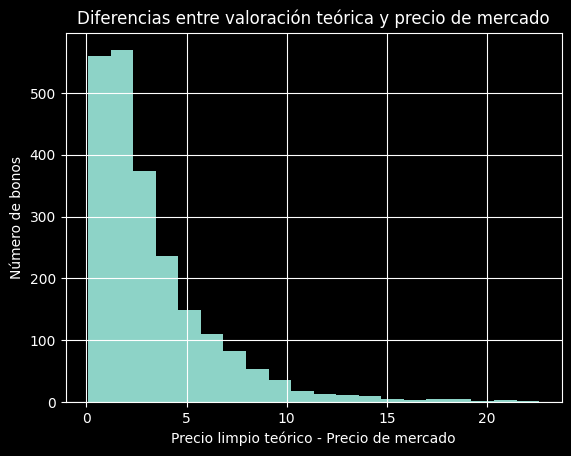

In [28]:
# Histograma de diferencias entre precio teórico y mercado
df_val["diferencia"].dropna().hist(bins=20)
plt.xlabel("Precio limpio teórico - Precio de mercado")
plt.ylabel("Número de bonos")
plt.title("Diferencias entre valoración teórica y precio de mercado")
plt.show()


<style>.gray {background-color: #595959}

</style><div class="gray">
A) ¿Qué observas si comparas los precios obtenidos y los precios de mercado?
</div>

Al comparar los precios teóricos calculados con la curva libre de riesgo (spread = 0) con los precios de mercado, se observa que:

- La mayoría de los bonos tienen precios teóricos cercanos a los precios de mercado, con diferencias pequeñas (0–2.5 puntos).

- Algunos bonos muestran diferencias mayores, donde el precio teórico es superior al precio de mercado.

Esto indica que el modelo con spread cero captura razonablemente los tipos de interés, pero no refleja plenamente la valoración que el mercado exige por estos bonos.


<style>.gray {background-color: #595959}

</style><div class="gray">
B) ¿A qué factores se debe esta diferencia?
</div>

La diferencia se debe principalmente a la prima de riesgo que no se ha incluido en la valoración. Entre los factores que influyen se encuentran:

- <u>Riesgo crediticio</u>:  bonos con mayor probabilidad de impago exigen un YTM más alto.

- <u>Riesgo de liquidez</u>: bonos menos líquidos pueden cotizar por debajo del valor teórico.

- <u>Características específicas del bono</u>: como callable o convertible, que afectan a su precio de mercado.

- <u>Otros factores de mercado</u>: tamaño de emisión, demanda, rating, sector, y condiciones macroeconómicas.

En conjunto, estas primas de riesgo hacen que el precio de mercado sea menor que el precio teórico calculado solo con la curva de tipos libre de riesgo, reflejando el rendimiento adicional que los inversores requieren.

### <font color=#0099CC>**3. Z-SPREAD**</font>


<style>.gray {background-color: #595959}

</style><div class="gray">

❕💬 Calculemos ahora los spreads que debemos añadir a la curva con un movimiento paralelo para que cuadren los precios de mercado que tenemos. Para ello, usa la función de valoración del apartado anterior. 
- ¿Qué observas? ¿Tienen sentido los resultados? 
- ¿Con qué datos de los que tenemos compararías para ver si los resultados son coherentes?

</div>

### <font color=#336699>**3.1. CÁLCULO Y VISUALIZACIÓN DEL Z-SPREAD**</font>

In [29]:
# Función que necesitaremos para visualizar los resultados del Z-Sprea

def dibujar_tarta_zspread(df_zspreads, columna='ZSpread_bps', bins=None, labels=None, titulo='Distribución de bonos por rangos de Z-Spread (bps)'):
    """
    Dibuja un gráfico de tarta de los bonos según rangos de Z-Spread.
    
    Parámetros:
    - df_zspreads: DataFrame con al menos la columna de Z-Spreads
    - columna: nombre de la columna con los Z-Spreads
    - bins: lista con los límites de los rangos (en bps). Por defecto [0,50,100,150,inf]
    - labels: etiquetas para los rangos. Por defecto ['<50','50-100','100-150','>150']
    - titulo: título del gráfico
    """
    
    if bins is None:
        bins = [0, 50, 100, 150, np.inf]
    if labels is None:
        labels = ['<50', '50-100', '100-150', '>150']
    
    # Creamos la columna categórica según rangos
    df_zspreads['Rango'] = pd.cut(df_zspreads[columna], bins=bins, labels=labels, right=False)
    
    # Contamos cuántos bonos hay en cada rango
    conteo_rangos = df_zspreads['Rango'].value_counts().sort_index()
    
    # Dibujamos la tarta
    plt.figure(figsize=(10,10))
    
    wedges, texts, autotexts = plt.pie(
        conteo_rangos,
        labels=conteo_rangos.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=plt.cm.Paired.colors,
        pctdistance=0.7,      # Porcentaje dentro del trozo
        labeldistance=1.1     # Etiquetas fuera
    )
    
    # Ponemos las etiquetas fuera en blanco
    plt.setp(texts, color='white', fontsize=12)
    plt.setp(autotexts, color='black', fontsize=12)
    
    plt.title(titulo)
    plt.show()

100%|██████████| 2255/2255 [00:25<00:00, 88.77it/s] 


,ZSpread_bps
ISIN,
XS0161488498,74.378485
FR0000471930,81.904379
XS0162513211,85.550665
XS0162869076,89.516733
FR0010014845,163.401057
...,...
XS2724401588,146.225277
XS2731506841,79.658551
FR001400MLN4,85.656730


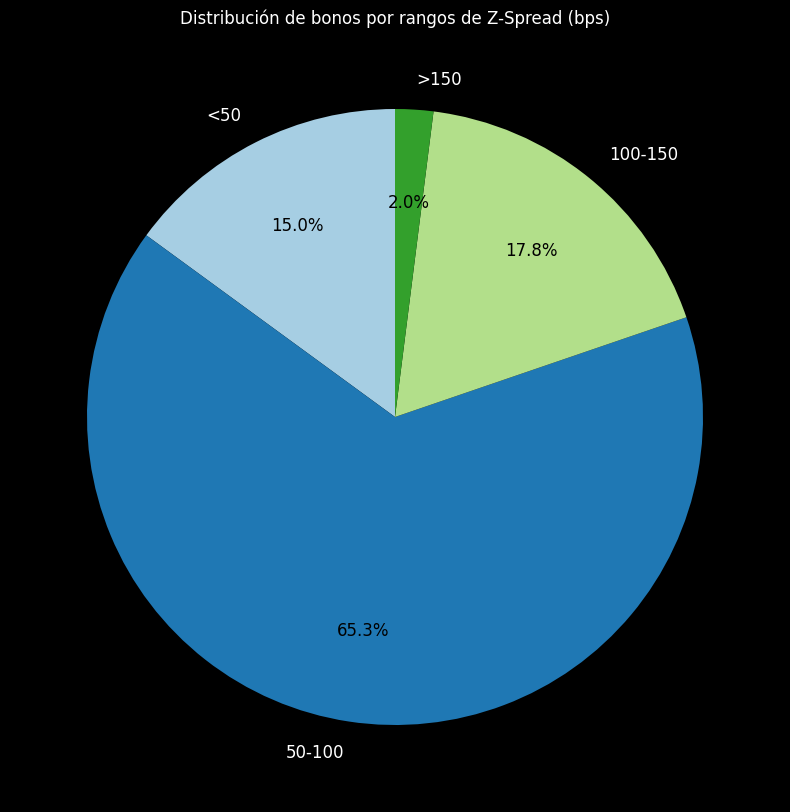

In [30]:
# Vamos a calcular los Z-Spreads de los bonos
zspreads = []

# Aseguramos que el índice sea DatetimeIndex
precios_universo.index = pd.to_datetime(precios_universo.index, dayfirst=True)
fecha_valor_ts = pd.Timestamp(fecha_valor)

for isin in tqdm(universo.index):
    try:
        # Acceso seguro al precio de mercado
        precio_mercado = precios_universo.get(f"{isin} Corp", pd.Series()).get(fecha_valor_ts, np.nan)
        
        if pd.notnull(precio_mercado):
            z = calcular_zspread(isin, universo, curva_ESTR, precio_mercado, fecha_valor_ts)
        else:
            z = np.nan
    except Exception:
        z = np.nan

    zspreads.append({"ISIN": isin, "ZSpread_bps": z})

df_zspreads = pd.DataFrame(zspreads).set_index("ISIN")
display(df_zspreads)

# Pie Plot
dibujar_tarta_zspread(df_zspreads)


<style>.gray {background-color: #595959}

</style><div class="gray">
A) ¿Qué observas al calcular los Z-spreads necesarios para ajustar los precios teóricos a los precios de mercado?
</div>

Al calcular los Z-spreads que se deben añadir a la curva de tipos con un movimiento paralelo para que los precios teóricos coincidan con los precios de mercado, se observa que:

- La mayoría de los bonos (80.3%) requiere ajustes relativamente modestos, con Z-spreads de hasta 100 puntos básicos. Esto indica que, para la mayor parte del universo, los precios de mercado se alinean bastante bien con la curva de tipos más un pequeño margen de ajuste (prima de riesgo).

- Por otro lado, una minoría significativa (19.7%) presenta Z-spreads superiores a 100 puntos básicos, mostrando que algunos bonos necesitan ajustes más importantes para reflejar correctamente las primas de riesgo exigidas por el mercado.

En general, estos resultados confirman que los precios de los bonos no dependen únicamente de la curva libre de riesgo, sino que incorporan primas adicionales por riesgo de crédito y otros factores, con la mayoría de los bonos requiriendo ajustes moderados y solo unos pocos ajustes sustanciales.

<style>.gray {background-color: #595959}

</style><div class="gray">
B) ¿Con qué datos comparar para verificar la coherencia?
</div>

Para validar los resultados, se pueden comparar con:

- <u>Precios de mercado</u>: comprobar que al aplicar el Z-spread calculado, el precio teórico coincide aproximadamente con el precio real.

- <u>Rating de los emisores</u>: bonos con peor rating deberían mostrar Z-spreads mayores.

- <u>Liquidez o tamaño de emisión</u>: bonos menos líquidos o más pequeños pueden requerir Z-spreads superiores.

- <u>Curva de tipos base</u>: verificar que los Z-spreads aplicados producen un ajuste paralelo razonable sobre la curva de zero rates.

### <font color=#336699>**3.2. VALIDACIÓN DE LOS RESULTADOS DEL Z-SPREAD**</font>

#### <font color=#808080>3.2.1. Precios Teóricos vs. Precios de Mercado</font>

100%|██████████| 2255/2255 [00:03<00:00, 641.32it/s]



Diferencia media ajustada: 0.0
Diferencia máxima ajustada: 0.0
Diferencia mínima ajustada: 0.0


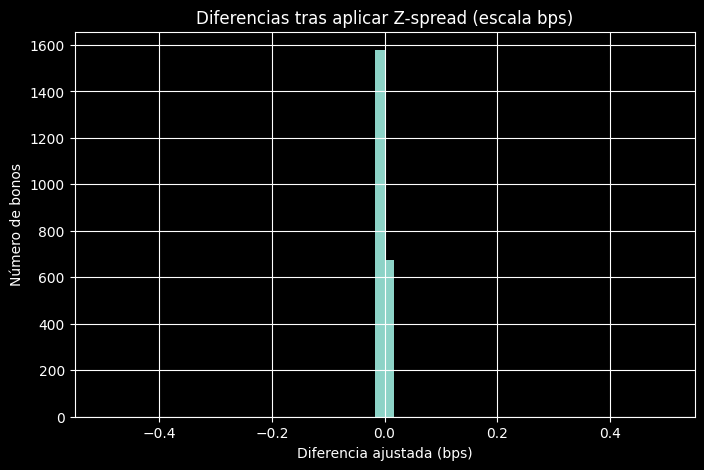

In [31]:
# Precios teóricos vs. precios de mercado
df_ajustado = evaluar_zspread(
    universo, df_zspreads, curva_ESTR, precios_universo, 
    fecha_valor=datetime(2025,10,1), bins=60, rango_hist=(-0.5,0.5)
)


><u>Precios Teóricos vs. Precios de Mercado</u>: Al aplicar el Z-spread calculado, vemos en el gráfico anterior que el precio teórico coincide aproximadamente con el precio real.

#### <font color=#808080>3.2.2. Rating de Emisores</font>

C:\Users\Javi\Desktop\MIAX\Enunciado\Enunciado\src\zspread.py:180: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bonos_por_rating = df_comparacion.groupby("Rating", group_keys=False, dropna=False).apply(sample_one)


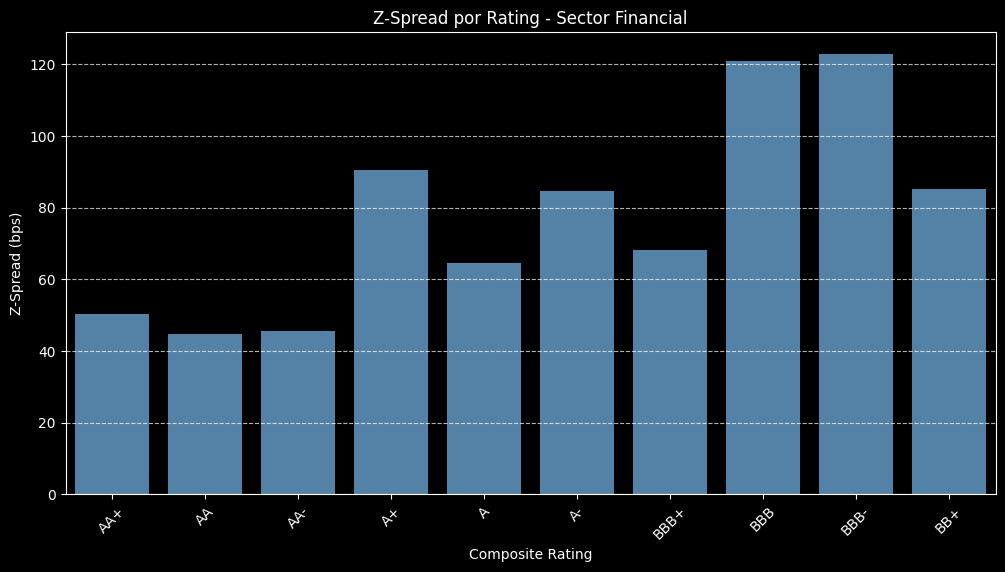

In [32]:
# Rating de los emisores
plot_zspread_by_rating_extended(
    universo=universo,
    df_zspreads=df_zspreads,
    sector="Financial",  # filtra solo el sector Financial. Probar con "Industrial"
    seed=42,             # para que la selección aleatoria sea reproducible
    color_by_size=False  # todas las barras del mismo color
)

><u>Rating de los emisores</u>: Se cumple que los bonos con mejor rating tienen, de media, menores Z-Spreads. Esto tiene sentido, el mercado exigirá una mayor rentabilidad por asumir más riesgo. El análisis gráfico se ha realizado sobre bonos de un mismo sector, en concreto del sector financiero. Sin embargo, esta propiedad debería cumplirse para otros sectores (probar con "Industrial").

#### <font color=#808080>3.2.3. Tamaño de Emisión</font>

C:\Users\Javi\Desktop\MIAX\Enunciado\Enunciado\src\zspread.py:180: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bonos_por_rating = df_comparacion.groupby("Rating", group_keys=False, dropna=False).apply(sample_one)


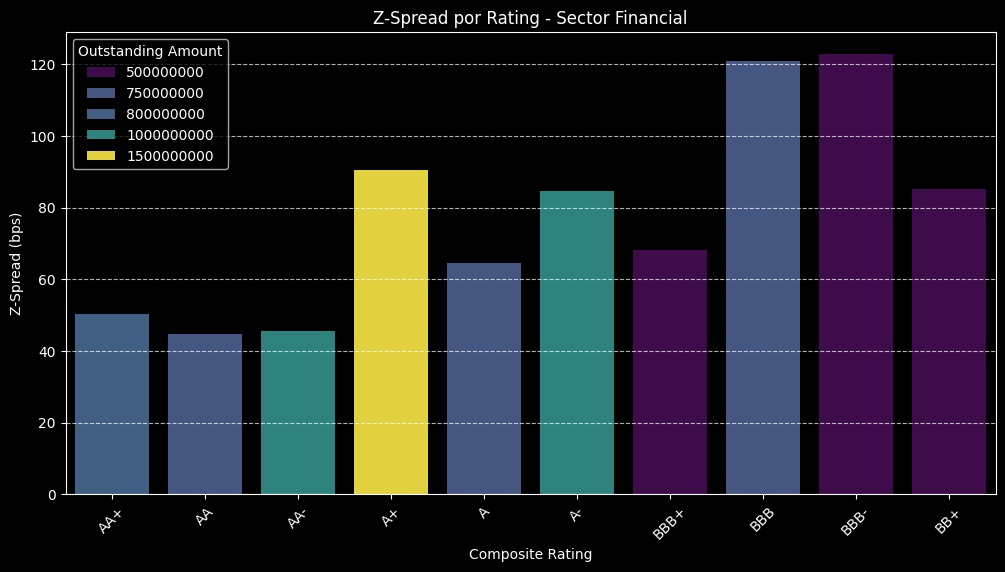

In [33]:
# Tamaño de emisión
plot_zspread_by_rating_extended(
    universo=universo,
    df_zspreads=df_zspreads,
    sector="Financial",
    seed=42,
    color_by_size=True   # usa gradiente de color según Outstanding Amount
)

><u>Tamaño de emisión</u>: Los bonos menos líquidos acostumbran tener primas por liquidez mayores, y viceversa. Aunque sea solo una parte del agregado de la prima por riesgo, el valor de la prima por liquidez contribuye a aumentar la magnitud del Z-Spread. Podemos visualizar esta relación inversa entre liquidez y Z-Spread en el gráfico anterior.

#### <font color=#808080>3.2.1. Curva Base vs. Z-Spread</font>

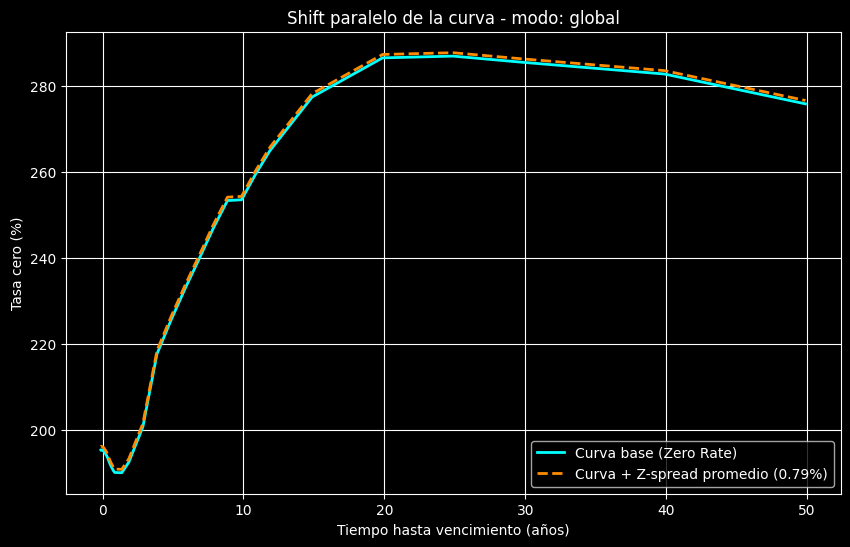

Mayor Z-spread: ISIN=XS1186176571, Z=1735.22 bps
Z-spread mediano: ISIN=XS0161488498, Z=74.38 bps
Menor Z-spread: ISIN=XS2555196463, Z=3.92 bps


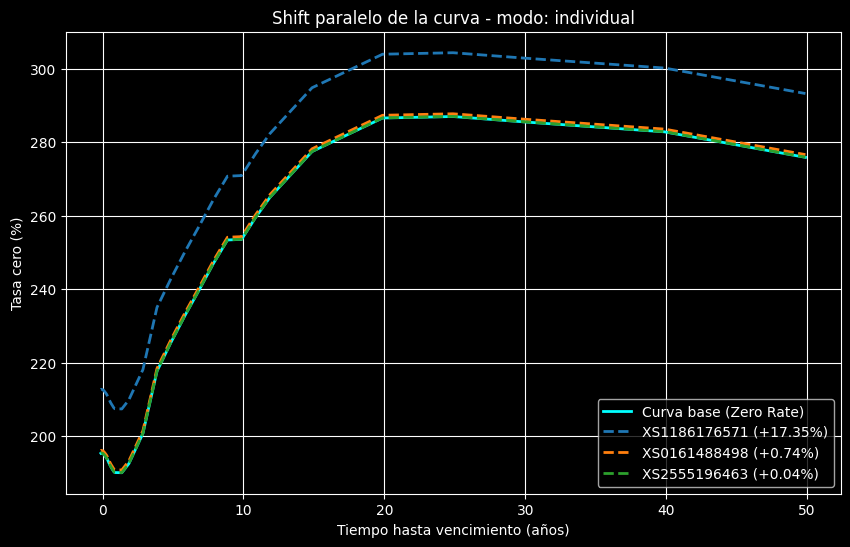

In [34]:
# Shift global promedio
plot_parallel_shift(curva_base=curva_ESTR,
                    df_zspreads=df_zspreads,
                    fecha_valor="2025-11-23",
                    modo="global")

# Shift individual: tres bonos ejemplo
plot_extremos_parallel_shift(curva_base=curva_ESTR, 
                            df_zspreads=df_zspreads, 
                            fecha_valor="2025-11-23")

><u>Curva de Tipos Base</u>: El primer gráfico muestra que el desplazamiento paralelo aplicado a la curva base es moderado, lo que indica que, en promedio, los Z-spreads del universo son reducidos. El segundo gráfico compara tres bonos representativos y confirma que, cuanto mayor es el Z-spread, mayor es el ajuste necesario sobre la curva ESTR para igualar el precio teórico con el de mercado. En conjunto, ambos gráficos reflejan que la mayoría de los bonos requiere ajustes modestos, mientras que solo unos pocos necesitan desplazamientos más significativos.

<style>.gray {background-color: #595959}

</style><div class="gray">
C)  ¿Tienen entonces sentido los resultados?
</div>

Sí, los resultados son coherentes:

- Los Z-spreads positivos indican que el mercado requiere un rendimiento mayor que el implícito por la curva libre de riesgo, para compensar riesgos adicionales.

- Los bonos de mayor calidad o más líquidos presentan Z-spreads menores, mientras que bonos con menor rating o menor liquidez presentan Z-spreads mayores.

- La magnitud de los Z-spreads promedio es pequeña, lo que explica por qué el shift paralelo de la curva se percibe mínimo en los gráficos.

En conjunto, los Z-spreads calculados reflejan la prima de riesgo crediticio, de liquidez y otros factores de mercado, y permiten alinear la valoración teórica con los precios observados en el mercado.

### <font color=#0099CC>**4. YTM, DURACIÓN & CONVEXIDAD**</font>

<style>.gray {background-color: #595959}

</style><div class="gray">

❕💬 Calculemos ahora la siguiente información, también relacionada con la rentabilidad y riesgo de las emisiones:
- *Yield* - Por simplicidad, en este caso, en el caso de los bonos callable, nos quedaremos con la fecha call, como en el ejercicio anterior. Usa las mismas asunciones que para la valoración y el spread.
- Duración
- Convexidad

Responde a las siguientes preguntas:
- ¿Que relación hay entre la TIR calculada y el spread calculado en el apartado anterior?
- ¿Qué relación hay entre la duración y el vencimiento? ¿Qué refleja la duración? ¿De qué otra forma se podría obtener esta sensibilidad?
- Estima el precio del bono usando la duración y convexidad, ¿qué observas?

</div>

### <font color=#336699>**4.1. CÁLCULO DEL YTM, DURACIÓN Y CONVEXIDAD**</font>

In [35]:
# Funciones que necesitamos para este apartado

def _cashflows_and_times_for_isin(isin: str, universo: pd.DataFrame, fecha_valor: datetime):
    """
    Devuelve lista de (t, cf) para los flujos futuros y el accrued (tiempo desde último cupon).
    Sigue las mismas reglas que valorar_bono: usa Next Call Date si existe.
    """
    row = universo.loc[isin]
    coupon_rate = float(row["Coupon"])
    freq = int(row["Coupon Frequency"])
    first_coupon = pd.to_datetime(row["First Coupon Date"], dayfirst=True, errors="coerce")

    next_call = row.get("Next Call Date")
    if pd.notnull(next_call):
        maturity = pd.to_datetime(next_call, dayfirst=True, errors="coerce")
    else:
        maturity = pd.to_datetime(row.get("Maturity"), dayfirst=True, errors="coerce")

    if pd.isna(first_coupon):
        first_coupon = fecha_valor
    if pd.isna(maturity):
        maturity = fecha_valor.replace(year=fecha_valor.year + 50)

    schedule = generate_coupon_schedule(first_coupon, maturity, freq)
    past = [d for d in schedule if d <= fecha_valor]
    future = [d for d in schedule if d > fecha_valor]

    last_coupon = past[-1] if past else first_coupon
    accrual_elapsed = yearfrac_act365(last_coupon, fecha_valor)
    accrued_coupon = coupon_rate * accrual_elapsed

    cashflows = []
    for d in future:
        t = yearfrac_act365(fecha_valor, d)
        cf = coupon_rate
        if d == maturity:
            cf += 100.0
        cashflows.append((t, float(cf)))

    return cashflows, accrued_coupon, last_coupon, (future[0] if future else maturity)


def calcular_yield(
    isin: str,
    universo: pd.DataFrame,
    precio_mercado: float,
    fecha_valor: datetime = datetime(2025, 10, 1),
    bracket: tuple[float, float] = ( -0.5, 1.0),
) -> Optional[float]:
    """
    Calcula la yield (convención: tasa continua anual) que hace PV(cashflows) = precio_mercado_duty.
    precio_mercado debe ser el PRECIO LIMPIO de mercado (sin coupon corrido). Devuelve yield en
    unidades decimales (ej. 0.05 = 5%). Si no converge, devuelve np.nan.
    """
    cashflows, accrued, _, _ = _cashflows_and_times_for_isin(isin, universo, fecha_valor)

    # Convert clean market price -> dirty market price
    precio_dirty = precio_mercado + accrued

    if not cashflows:
        return np.nan

    def precio_diff(y):
        # descontado de cada cf con descuento continuo e^{-y t}
        pv = sum(cf * np.exp(-y * t) for t, cf in cashflows)
        return pv - precio_dirty

    a, b = bracket
    try:
        y = brentq(precio_diff, a, b, maxiter=200, xtol=1e-12)
    except (ValueError, RuntimeError):
        return np.nan

    return float(y)


def calcular_duracion_convexidad(
    isin: str,
    universo: pd.DataFrame,
    yield_decimal: float,
    fecha_valor: datetime = datetime(2025, 10, 1),
) -> dict:
    """
    Calcula Macaulay duration y convexidad bajo descontado continuo (yield_decimal como tasa continua anual).
    Devuelve dict con: {'macaulay': ..., 'modified': ..., 'convexity': ...}
    Notas:
      - Con descontado continuo: Modified duration = Macaulay duration.
      - Convexidad calculada como sum(t^2 * PV(t)) / P_total (unidades: años^2).
    """
    cashflows, accrued, _, _ = _cashflows_and_times_for_isin(isin, universo, fecha_valor)

    if not cashflows:
        return {"macaulay": np.nan, "modified": np.nan, "convexity": np.nan}

    pv_each = [cf * np.exp(-yield_decimal * t) for t, cf in cashflows]
    pv_total = sum(pv_each)
    if pv_total == 0 or np.isnan(pv_total):
        return {"macaulay": np.nan, "modified": np.nan, "convexity": np.nan}

    times = [t for t, _ in cashflows]
    macaulay = sum(t * pv for t, pv in zip(times, pv_each)) / pv_total
    # Para descuento continuo: modified = macaulay (ver derivadas)
    modified = macaulay
    convexity = sum((t ** 2) * pv for t, pv in zip(times, pv_each)) / pv_total

    return {"macaulay": float(macaulay), "modified": float(modified), "convexity": float(convexity)}


def calcular_universo_yield_duracion_convexidad(
    universo: pd.DataFrame,
    precios_universo: pd.DataFrame,
    fecha_valor: datetime = datetime(2025, 10, 1),
    yield_bracket: tuple[float, float] = (-0.5, 1.0),
) -> pd.DataFrame:
    """
    Para cada ISIN en `universo` intenta:
      - leer precio_mercado = precios_universo.loc[fecha_valor, f"{ISIN} Corp"]
      - calcular yield, duración y convexidad
    Devuelve DataFrame con columnas: Yield(%), Macaulay(yrs), Modified(yrs), Convexity(yrs^2), PrecioMercado, Accrued.
    """
    rows = []
    for isin in universo.index:
        try:
            precio = precios_universo.loc[fecha_valor, f"{isin} Corp"]
        except Exception:
            precio = np.nan

        if pd.isna(precio):
            rows.append(
                {"ISIN": isin, "Yield_%": np.nan, "Macaulay": np.nan, "Modified": np.nan, "Convexity": np.nan, "PrecioMercado": np.nan}
            )
            continue

        y = calcular_yield(isin, universo, precio, fecha_valor, bracket=yield_bracket)
        if np.isnan(y):
            rows.append(
                {"ISIN": isin, "Yield_%": np.nan, "Macaulay": np.nan, "Modified": np.nan, "Convexity": np.nan, "PrecioMercado": precio}
            )
            continue

        dur_conv = calcular_duracion_convexidad(isin, universo, y, fecha_valor)
        rows.append(
            {
                "ISIN": isin,
                "Yield_%": float(y * 100),
                "Macaulay": dur_conv["macaulay"],
                "Modified": dur_conv["modified"],
                "Convexity": dur_conv["convexity"],
                "PrecioMercado": precio,
            }
        )

    return pd.DataFrame(rows).set_index("ISIN")

In [36]:
# Utilizamos las funciones para llevar a cabo el cálculo
fecha = datetime(2025, 10, 1)
df_res = calcular_universo_yield_duracion_convexidad(universo, precios_universo, fecha)

# Unir DataFrames directamente por índice
df_comb = df_res.join(df_zspreads, how="left")

# Renombrar la columna de spread si quieres un nombre más cómodo
df_comb.rename(columns={"ZSpread_bps": "Spread_bp"}, inplace=True)

# Verificar resultado
df_comb.head()


,Yield_%,Macaulay,Modified,Convexity,PrecioMercado,Spread_bp,Rango
ISIN,,,,,,,
XS0161488498,3.121037,5.847850,5.847850,39.533970,127.8353,74.378485,50-100
FR0000471930,3.194111,5.783733,5.783733,38.947328,131.3195,81.904379,50-100
XS0162513211,3.244794,6.126333,6.126333,42.349001,115.7800,85.550665,50-100
XS0162869076,3.283758,6.106629,6.106629,42.160171,116.3000,89.516733,50-100
FR0010014845,4.055882,6.645418,6.645418,49.199652,112.3887,163.401057,>150


### <font color=#336699>**4.2. ANÁLISIS DE RESULTADOS**</font>

<style>.gray {background-color: #595959}

</style><div class="gray">
A) ¿Que relación hay entre la TIR calculada y el spread calculado en el apartado anterior?
</div>

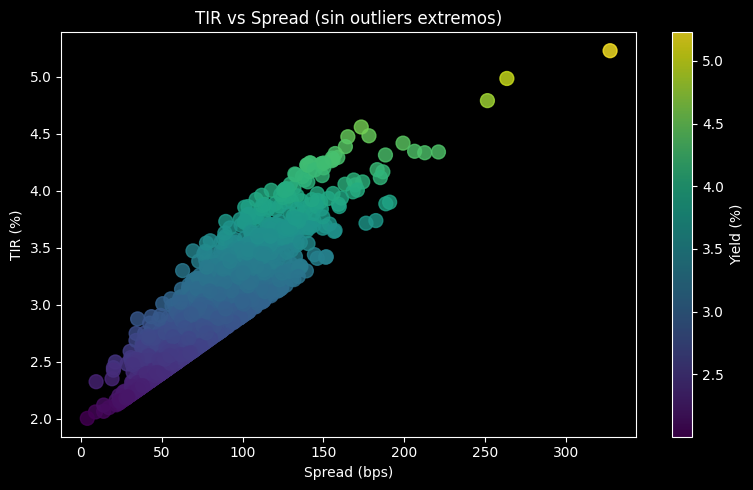

In [37]:
# Filtrar outliers extremos de Spread pra visualizar mejor la tendencia
df_plot = df_comb[(df_comb["Spread_bp"] < 500)]  # excluir 600 y 1750

# Visualizar tendencia
plt.figure(figsize=(8,5))
sc = plt.scatter(df_plot["Spread_bp"], df_plot["Yield_%"], c=df_plot["Yield_%"], cmap="viridis", s=100, alpha=0.8)
plt.title("TIR vs Spread (sin outliers extremos)")
plt.xlabel("Spread (bps)")
plt.ylabel("TIR (%)")
plt.colorbar(sc, label="Yield (%)")
plt.tight_layout()
plt.show()


><u>Gráfico TIR vs Spread</u>: Se observa una relación lineal positiva: a mayor spread del bono frente al benchmark, mayor es la TIR calculada. Esto refleja que los bonos con mayor riesgo crediticio o menor liquidez deben ofrecer un rendimiento más alto para ser atractivos, lo que concuerda con la teoría financiera (Nota: en el gráfico, los outliers extremos se han filtrado para que la tendencia principal se pueda apreciar mejor).

<style>.gray {background-color: #595959}

</style><div class="gray">
B) ¿Qué relación hay entre la duración y el vencimiento? ¿Qué refleja la duración? ¿De qué otra forma se podría obtener esta sensibilidad?
</div>

A mayor vencimiento mayor duración. La duración refleja la sensibilidad del precio del bono frente a cambios en la tasa de interés, es decir, cuánto varía su precio ante un pequeño cambio en el yield. También puede entenderse como un “balancín de flujos”: indica dónde se concentra, en promedio, el peso temporal de los pagos (Fuente de la Imagen: Elaboración Propia).

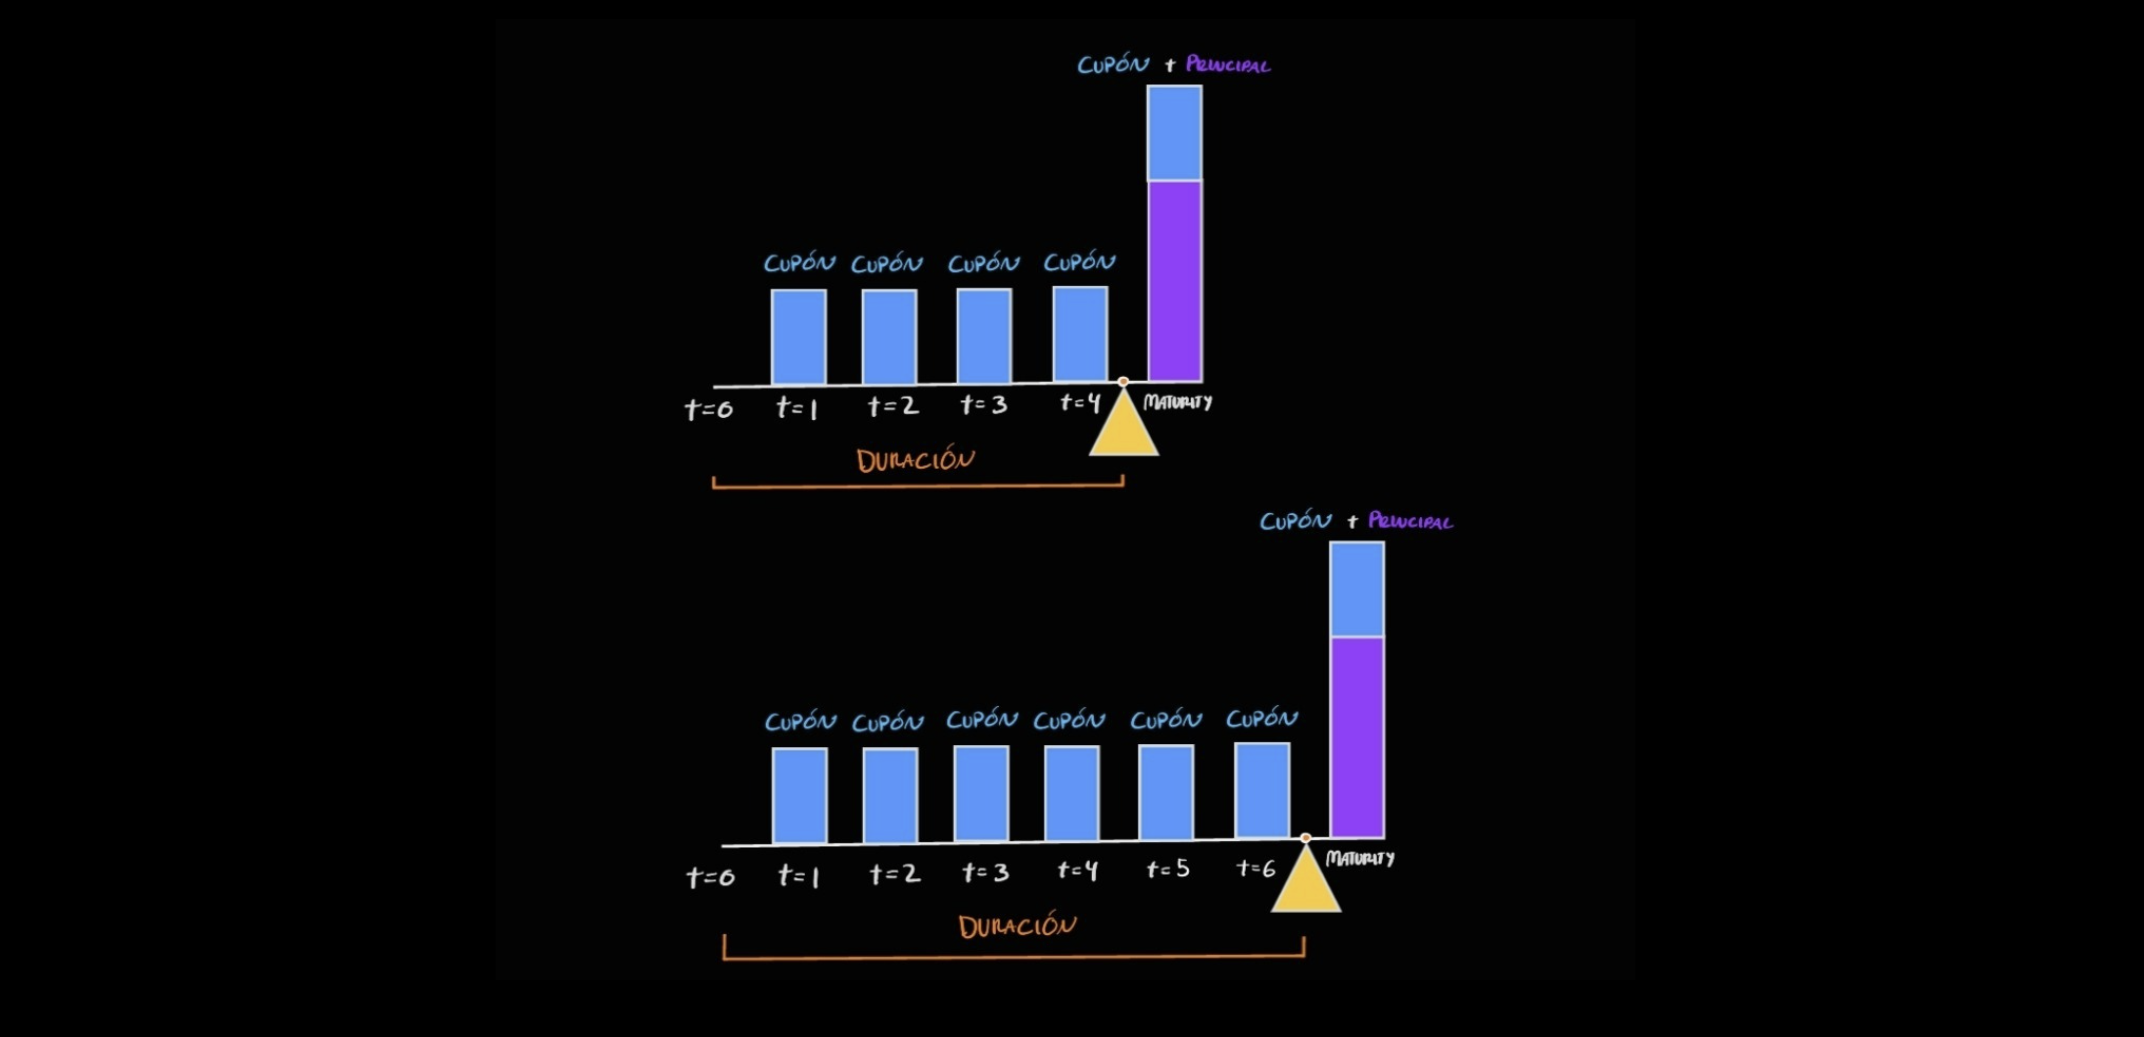

Dado que ya obtenemos la sensibilidad a través de la duración modificada (y también contamos con convexidad), la otra forma práctica sería repriciar el bono con un pequeño bump en la tasa (por ejemplo +/– 1 o 10 pb) y medir directamente la variación del precio. Esto permite validar empíricamente lo que muestra la duración/convexidad.

<style>.gray {background-color: #595959}

</style><div class="gray">
C) Estima el precio del bono usando la duración y convexidad, ¿qué observas?

</div>

In [38]:
# Función que utilizaremos para calcular el precio del bono usando convexidad

def estimar_precio_dur_conv(
    df_res: pd.DataFrame,
    precios_universo: pd.DataFrame,
    fecha_valor: datetime,
    delta_ybps: float = 50  # cambio de yield en bps para estimación
) -> pd.DataFrame:
    """
    Estima el precio de cada bono usando duración y convexidad.
    - df_res: DataFrame con Yield_%, Modified y Convexity
    - precios_universo: DataFrame con precios de mercado (clean)
    - delta_ybps: cambio de yield en bps para la estimación (+/-)
    
    Devuelve df con columnas:
      - PrecioMercado: precio limpio real
      - PrecioEstimado: precio estimado usando duración y convexidad
      - Diferencia: PrecioEstimado - PrecioMercado
    """
    delta_y = delta_ybps / 10000  # convertir bps a decimal
    rows = []

    for isin in df_res.index:
        try:
            precio_real = precios_universo.loc[fecha_valor, f"{isin} Corp"]
        except Exception:
            precio_real = np.nan

        if pd.isna(precio_real):
            rows.append({"ISIN": isin, "PrecioMercado": np.nan, "PrecioEstimado": np.nan, "Diferencia": np.nan})
            continue

        dur = df_res.loc[isin, "Modified"]
        conv = df_res.loc[isin, "Convexity"]

        # Estimación usando duración y convexidad
        precio_estimado = precio_real * (1 - dur*delta_y + 0.5*conv*delta_y**2)
        rows.append({
            "ISIN": isin,
            "PrecioMercado": precio_real,
            "PrecioEstimado": precio_estimado,
            "Diferencia": precio_estimado - precio_real
        })

    df_estimado = pd.DataFrame(rows).set_index("ISIN")
    return df_estimado


,PrecioMercado,PrecioEstimado,Diferencia
ISIN,,,
XS0161488498,127.8353,124.160665,-3.674635
FR0000471930,131.3195,127.585847,-3.733653
XS0162513211,115.7800,112.294755,-3.485245
XS0162869076,116.3000,112.810286,-3.489714
FR0010014845,112.3887,108.723469,-3.665231
...,...,...,...
XS2724401588,107.8130,106.742966,-1.070034
XS2731506841,103.2010,100.412486,-2.788514
FR001400MLN4,104.4336,102.072558,-2.361042


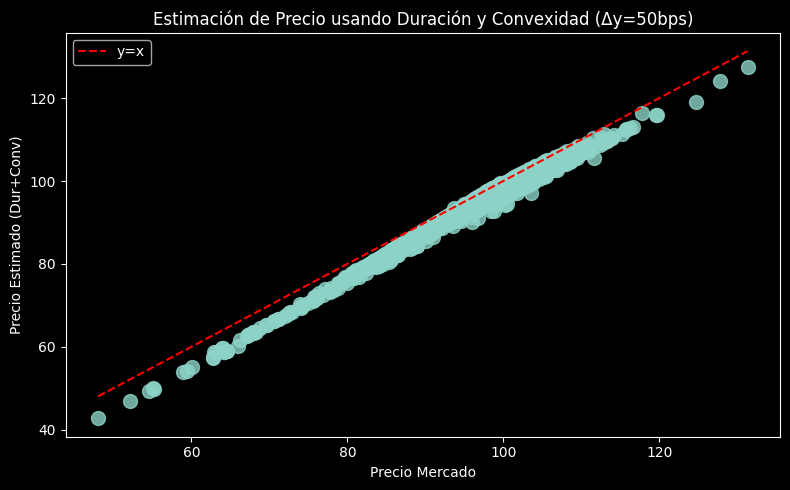

In [39]:
# Mostrar Resultados
df_resultado = estimar_precio_dur_conv(df_res, precios_universo, fecha_valor)
display(df_resultado)

# Estimar precios con un aumento de 50 bps
df_precio_estimado = estimar_precio_dur_conv(df_res, precios_universo, fecha)

# Ver primeras filas
df_precio_estimado.head()

# Graficar Precio Real vs Estimado
plt.figure(figsize=(8,5))
plt.scatter(df_precio_estimado["PrecioMercado"], df_precio_estimado["PrecioEstimado"], alpha=0.8, s=100)
plt.plot([df_precio_estimado["PrecioMercado"].min(), df_precio_estimado["PrecioMercado"].max()],
         [df_precio_estimado["PrecioMercado"].min(), df_precio_estimado["PrecioMercado"].max()],
         color='red', linestyle='--', label='y=x')
plt.xlabel("Precio Mercado")
plt.ylabel("Precio Estimado (Dur+Conv)")
plt.title(f"Estimación de Precio usando Duración y Convexidad (Δy={50}bps)")
plt.legend()
plt.tight_layout()
plt.show()



> <u>Estimación de Precio usando Duración y Convexidad</u>: Este primer gráfico muestra la comparación directa entre el precio de mercado de los bonos y el precio estimado mediante la aproximación basada en duración y convexidad tras un cambio de 50 puntos básicos en la tasa. En general, los puntos se sitúan cerca de la diagonal, lo que indica que el método reproduce razonablemente bien el comportamiento agregado del precio ante variaciones en el rendimiento. Sin embargo, se aprecia un sesgo sistemático: los precios estimados tienden a quedar por debajo de los observados, lo que implica que el modelo subestima el precio y, por tanto, sobrestima la caída inducida por el shock de tasas. Este sesgo es coherente con la teoría vista en clase: la relación entre precio y yield no es lineal, sino convexa, por lo que una aproximación lineal-cuadrática como la de duración y convexidad siempre tiende a quedarse corta cuando los movimientos en tipos no son muy pequeños.

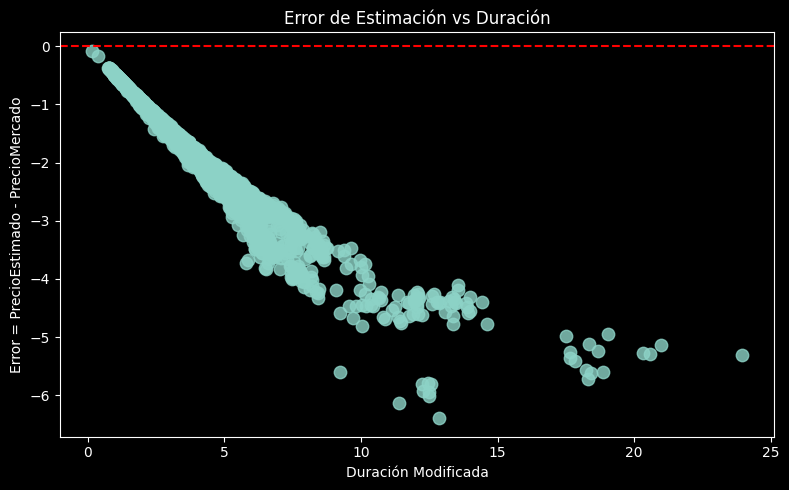

In [40]:
plt.figure(figsize=(8,5))
plt.scatter(df_res["Modified"], df_precio_estimado["Diferencia"], alpha=0.8, s=80)
plt.axhline(0, color='red', linestyle='--')
plt.title("Error de Estimación vs Duración")
plt.xlabel("Duración Modificada")
plt.ylabel("Error = PrecioEstimado - PrecioMercado")
plt.tight_layout()
plt.show()


<u>Error de Estimación vs Duración Modificada</u>: Este segundo gráfico presenta cómo evoluciona el error de estimación del modelo en función de la duración modificada de cada bono. La relación observada es clara: los errores se vuelven más negativos a medida que aumenta la duración, reflejando una pérdida progresiva de precisión en bonos más sensibles a los cambios en tasas. Mientras que los bonos de corta duración se ajustan casi perfectamente, los de duración media y alta presentan una subestimación creciente del precio, consecuencia directa de la mayor convexidad real que caracteriza a estos instrumentos. Tal como se explicó en clase, la aproximación basada en duración funciona bien en horizontes cortos porque la relación precio–yield es casi lineal, pero en bonos de plazos largos esta relación es mucho más curvada; por ello, la aproximación de segundo orden no basta y el modelo tiende de forma natural a infravalorar el precio verdadero.

### <font color=#0099CC>**5. CARTERA EQUIPONDERADA**</font>

<style>.gray {background-color: #595959}

</style><div class="gray">

❕💬 Crea un algoritmo de inversión que consista en una cartera equiponderada, asignando el mismo peso a todos los bonos vivos en cada fecha de rebalanceo.

Asume rebalanceo mensual, y que no tenemos costes más allá de los implícitos en el propio precio, calcula la evolución que hubiese tenido tu algoritmo. Por simplificación, utiliza los precios MID que se te dan.

Asumiendo que el benchmark de la cartera es el índice que se nos da: *RECMTREU Index*. Contrasta la evolución de tú cartera contra dicho benchmark. Ten cuidado porque es un índice *Total Return*.

- ¿Qué sería lo más correcto en lugar de utilizar los precios MID?
- ¿Se te ocurre algún otro benchmark que se podría utilizar?

</div>

### <font color=#336699>**5.1. RECMTREU vs. CARTERA SIN REINVERSIÓN DE CUPONES (forma incorrecta)**</font>

,Rent. anualizada,Vol. anualizada,Sharpe,Max drawdown,Tracking error,Info ratio
Cartera EqWeight,0.049284,0.033256,1.481975,-0.021553,0.009956,-1.441423
RECMTREU,0.064586,0.029044,2.223742,-0.017616,NaN,NaN


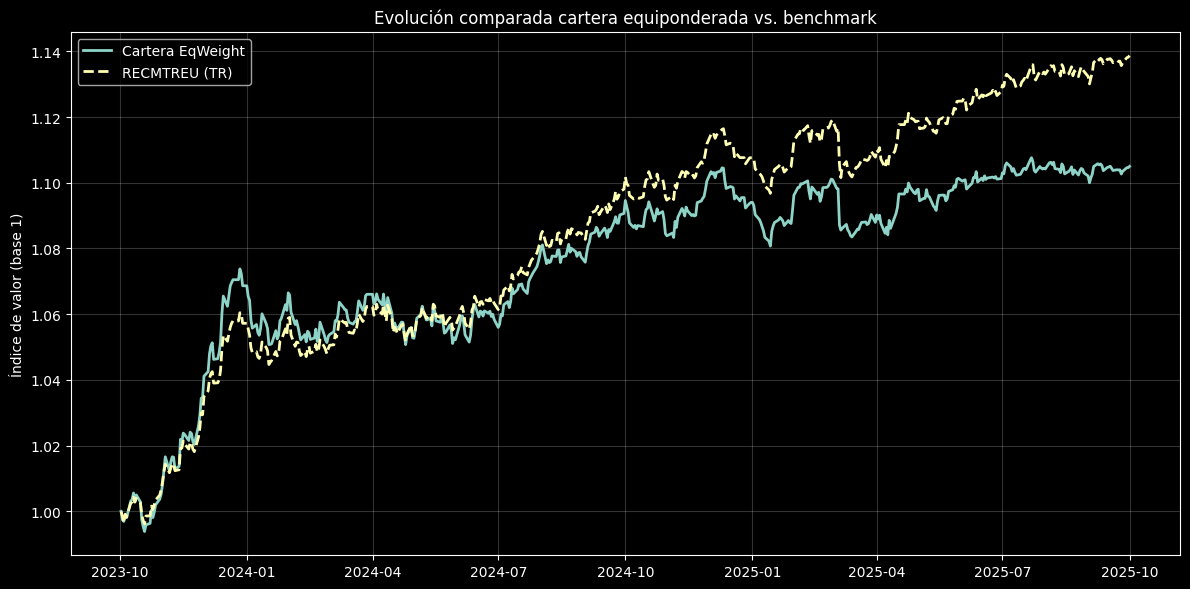

In [41]:
# --- Cartera equiponderada con rebalanceo mensual sin reinversión de cupones --- 
precios_eq = precios_universo.sort_index().copy()
retornos = precios_eq.pct_change().replace([np.inf, -np.inf], np.nan).fillna(0)

# Identificar inicio de mes para rebalanceo
periodos = precios_eq.index.to_period("M")
rebalance_flags = pd.Series(
    np.r_[True, periodos[1:] != periodos[:-1]], index=precios_eq.index
)

# Inicializar DataFrame de pesos
weights = pd.DataFrame(0.0, index=retornos.index, columns=retornos.columns)
current_w = pd.Series(0.0, index=retornos.columns)

# Asignar pesos equiponderados con rebalanceo mensual
for fecha in retornos.index:
    if rebalance_flags.loc[fecha]:
        vivos = precios_eq.loc[fecha].dropna().index.tolist()
        current_w = pd.Series(0.0, index=retornos.columns)
        if vivos:
            peso = 1.0 / len(vivos)
            current_w.loc[vivos] = peso
    weights.loc[fecha] = current_w

# Calcular retornos y NAV de la cartera
retornos_cartera = (weights * retornos).sum(axis=1)
nav_eqw = (1 + retornos_cartera).cumprod()
nav_eqw.name = "Cartera EqWeight"

# Benchmark
benchmark_precios = (
    precios_varios["RECMTREU Index"]
    .sort_index()
    .reindex(nav_eqw.index)
    .ffill()
)
retornos_bench = benchmark_precios.pct_change().fillna(0)
nav_bench = (1 + retornos_bench).cumprod()
nav_bench.name = "RECMTREU"

# Función de métricas de desempeño
def perf_stats(retornos, freq=252):
    if len(retornos) == 0:
        return np.nan, np.nan, np.nan, np.nan
    crecimiento = (1 + retornos).prod()
    rent_annual = crecimiento ** (freq / len(retornos)) - 1
    vol_annual = retornos.std() * np.sqrt(freq)
    sharpe = rent_annual / vol_annual if vol_annual > 0 else np.nan
    serie_nav = (1 + retornos).cumprod()
    drawdown = (serie_nav / serie_nav.cummax() - 1).min()
    return rent_annual, vol_annual, sharpe, drawdown

# Calcular estadísticas
stats_port = perf_stats(retornos_cartera)
stats_bench = perf_stats(retornos_bench)

tracking_error = (retornos_cartera - retornos_bench).std() * np.sqrt(252)
exceso_anual = (retornos_cartera - retornos_bench).mean() * 252
info_ratio = exceso_anual / tracking_error if tracking_error > 0 else np.nan

# Tabla de resultados
tabla_stats = pd.DataFrame(
    [stats_port, stats_bench],
    columns=["Rent. anualizada", "Vol. anualizada", "Sharpe", "Max drawdown"],
    index=["Cartera EqWeight", "RECMTREU"],
)
tabla_stats.loc["Cartera EqWeight", "Tracking error"] = tracking_error
tabla_stats.loc["Cartera EqWeight", "Info ratio"] = info_ratio

display(tabla_stats)

# Gráfico comparativo
nav_comp = pd.concat([nav_eqw, nav_bench], axis=1)
plt.figure(figsize=(12, 6))
plt.plot(nav_comp.index, nav_comp["Cartera EqWeight"], label="Cartera EqWeight", linewidth=2)
plt.plot(nav_comp.index, nav_comp["RECMTREU"], label="RECMTREU (TR)", linewidth=2, linestyle="--")
plt.legend()
plt.title("Evolución comparada cartera equiponderada vs. benchmark")
plt.ylabel("Índice de valor (base 1)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


>    <u>Cartera vs. Benchmark</u>: La cartera equiponderada evoluciona de forma bastante parecida al benchmark durante buena parte del periodo, pero a partir de mediados de 2024 el índice Total Return empieza a separarse y termina claramente por encima. Aunque la cartera presenta un perfil de riesgo contenido (volatilidad y drawdowns moderados), su rentabilidad acumulada y su Sharpe quedan por debajo del índice, lo que indica que el enfoque equiponderado no captura el rendimiento adicional que sí recoge el benchmark (probablemente por su distinta composición, duración o sesgo crediticio). 
>
> En parte <u>esto era esperable</u>: el benchmark RECMTREU es Total Return (incluye y reinvierte cupones), mientras que la serie de precios de precios_universo que usamos para la cartera refleja solo movimientos de precio y pagos de cupones separados —por eso una comparación sin ajustar tiende a mostrar underperformance del portafolio frente al TR. Este es otro de los factores que podrían explicar esa progresiva separación de las series a medida que transcurre el tiempo. La reinversión de los cupones tiene poco efecto en el corto plazo, pero se vuelve considerable en el largo plazo.

### <font color=#336699>**5.2. RECMTREU vs. CARTERA CON REINVERSIÓN DE CUPONES (forma correcta)**</font>


Métricas Comparadas:


,Cartera EqWeight,Benchmark RECMTREU (TR)
Total Return,0.1514,0.1387
Annualized Return (approx),0.0704,0.0647
Annual Vol,0.0333,0.0291
Sharpe (approx),2.0613,2.1718
Max Drawdown,-0.0201,-0.0176


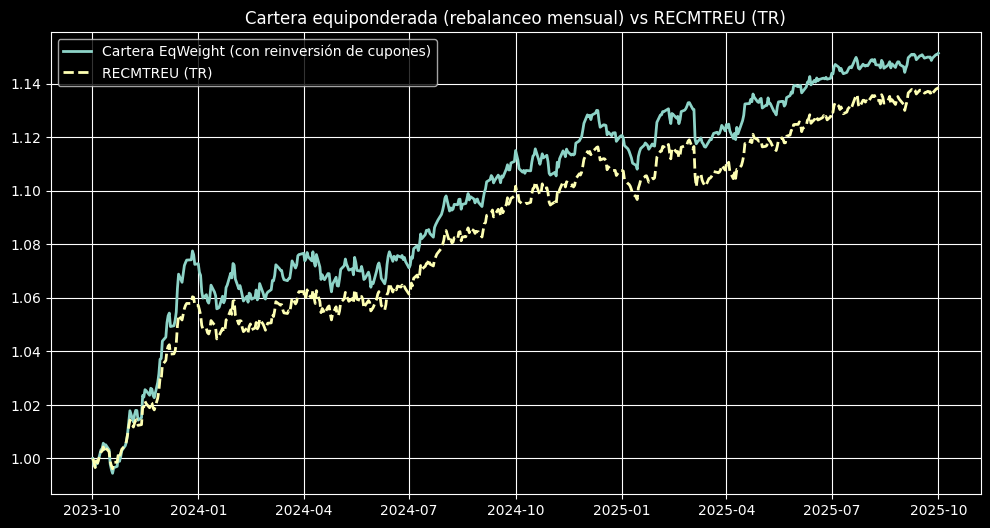

In [42]:
# Cartera con reinversión de cupones
prices = precios_universo.copy().sort_index()
univ = universo.copy()

# Asegurarnos de que el índice de precios es DatetimeIndex y ordenado
prices.index = pd.to_datetime(prices.index, dayfirst=True)
prices = prices.sort_index()

# Fechas de rebalanceo: primer día de trading de cada mes
rebalance_dates = prices.index.to_series().groupby([prices.index.year, prices.index.month]).first().tolist()
rebalance_dates = [pd.Timestamp(d) for d in rebalance_dates if pd.notna(d)]
rebalance_set = set(rebalance_dates)

# --- Función auxiliar: mapear fecha potencial a primer día de trading >= fecha ---
def map_to_next_trading_day(d, trading_index):
    if pd.isna(d):
        return pd.NaT
    pos = trading_index.searchsorted(d)
    if pos >= len(trading_index):
        return pd.NaT
    return trading_index[pos]

# --- 2) Construir matriz de cupones (CF) en EUR por 100 nominal ---
CF = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)

for isin in univ.index:
    col = f"{isin} Corp"
    if col not in prices.columns:
        continue

    row = univ.loc[isin]

    # --- Interpretación robusta del campo Coupon ---
    # Posibles formatos: 1.5 (significa 1.5%), 150 (posible bps) -> intentamos inferir
    coupon_raw = row.get("Coupon", np.nan)
    try:
        coupon_raw = float(coupon_raw)
    except Exception:
        coupon_raw = np.nan

    if pd.isna(coupon_raw):
        continue

    # Heurística: si coupon_raw >= 100 -> improbable (porcentaje >100%), tratamos como bps (p.ej. 150 -> 1.5%)
    # Si coupon_raw entre 10 y 100 puede ser un 10% real (muy raro) pero igualmente lo dejamos como %
    # Resultado: coupon_pct será el cupón en porcentaje anual (p.ej. 1.5)
    if coupon_raw >= 100:
        # probable valor en puntos básicos (bps)
        coupon_pct = coupon_raw / 100.0
    else:
        # probable valor en porcentaje (1.5 significa 1.5%)
        coupon_pct = coupon_raw

    # Frecuencia
    try:
        freq = int(row.get("Coupon Frequency", 1))
        if freq <= 0:
            freq = 1
    except Exception:
        freq = 1

    # Fechas
    first_coupon = pd.to_datetime(row.get("First Coupon Date"), dayfirst=True, errors="coerce")
    if pd.isna(first_coupon):
        first_coupon = prices.index[0]

    next_call = row.get("Next Call Date")
    if pd.notnull(next_call):
        maturity = pd.to_datetime(next_call, dayfirst=True, errors="coerce")
    else:
        maturity = pd.to_datetime(row.get("Maturity"), dayfirst=True, errors="coerce")

    if pd.isna(maturity):
        maturity = prices.index[-1]

    # Generar calendario de cupones (si tienes generate_coupon_schedule)
    try:
        schedule = generate_coupon_schedule(first_coupon, maturity, freq)
    except Exception:
        schedule = []

    # Ahora: coupon_pct es % anual (ej. 1.5). Cupón en EUR por 100 nominal por pago:
    # annual_coupon_eur_per_100 = coupon_pct / 100 * 100 = coupon_pct
    # cupón por pago en EUR/100 = coupon_pct / freq
    coupon_per_payment_eur_per_100 = coupon_pct / freq  # ej. 1.5% anual, freq=2 -> 0.75 EUR por 100

    # Mapear fechas del calendario al primer día de trading >= fecha
    for d in schedule:
        mapped = map_to_next_trading_day(pd.to_datetime(d, dayfirst=True, errors="coerce"), prices.index)
        if pd.isna(mapped):
            continue
        if mapped in CF.index and col in CF.columns:
            CF.at[mapped, col] = CF.at[mapped, col] + coupon_per_payment_eur_per_100

# --- 3) Calcular retornos totales por bono (incluyendo cupones) ---
prices_num = prices.apply(pd.to_numeric, errors="coerce")

Pprev = prices_num.shift(1)

# Aquí CF está en EUR por 100 nominal y prices están en la misma unidad (precio por 100 nominal).
# Entonces el retorno total correcto es:
# ret_with_coupons = (P_t + CF_payment) / P_{t-1} - 1
ret_with_coupons = (prices_num + CF) / Pprev - 1.0

# Evitar infinitos
ret_with_coupons = ret_with_coupons.replace([np.inf, -np.inf], np.nan)

# --- 4) Pesos equiponderados con rebalanceo mensual (igual que tenías) ---
weights = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)
current_weights = pd.Series(0.0, index=prices.columns)

for date in prices.index:
    if date in rebalance_set:
        alive = prices_num.loc[date].dropna().index.tolist()
        if len(alive) == 0:
            current_weights[:] = 0.0
        else:
            w = 1.0 / len(alive)
            current_weights[:] = 0.0
            current_weights.loc[alive] = w
    weights.loc[date] = current_weights.values

weights = weights.where(~prices_num.isna(), 0.0)

# --- 5) Retorno diario de la cartera y NAV acumulado ---
# Si hay NaN en ret_with_coupons para un bono, su peso en ese día debería ser 0 (ya aplicado).
daily_portfolio_ret = (weights * ret_with_coupons).sum(axis=1)
daily_portfolio_ret = daily_portfolio_ret.fillna(0.0)
nav = (1.0 + daily_portfolio_ret).cumprod()
nav.name = "Cartera EqWeight (con reinversión de cupones)"

# --- 6) Benchmark ---
bench = precios_varios["RECMTREU Index"].sort_index().copy()
bench = bench.reindex(nav.index).ffill()
bench_ret = bench.pct_change().fillna(0.0)
nav_bench = (1.0 + bench_ret).cumprod()
nav_bench.name = "RECMTREU (TR)"

# --- 7) Métricas y gráfico comparativo (anualización geométrica) ---
def perf_stats_from_nav(nav_series, trading_days_per_year=252):
    r = nav_series.pct_change().dropna()
    if len(r) == 0:
        return {
            "Total Return": np.nan,
            "Annualized Return (approx)": np.nan,
            "Annual Vol": np.nan,
            "Sharpe (approx)": np.nan,
            "Max Drawdown": np.nan,
        }
    total_ret = nav_series.iloc[-1] / nav_series.iloc[0] - 1
    ann_ret = (nav_series.iloc[-1] / nav_series.iloc[0]) ** (trading_days_per_year / len(r)) - 1
    vol = r.std() * np.sqrt(trading_days_per_year)
    sharpe = (r.mean() / r.std() * np.sqrt(trading_days_per_year)) if r.std() > 0 else np.nan
    drawdown = (nav_series / nav_series.cummax() - 1).min()
    return {
        "Total Return": total_ret,
        "Annualized Return (approx)": ann_ret,
        "Annual Vol": vol,
        "Sharpe (approx)": sharpe,
        "Max Drawdown": drawdown,
    }

stats_cartera = perf_stats_from_nav(nav)
stats_bench = perf_stats_from_nav(nav_bench)

df_stats = pd.DataFrame({
    "Cartera EqWeight": stats_cartera,
    "Benchmark RECMTREU (TR)": stats_bench
}).round(4)

print("\nMétricas Comparadas:")
display(df_stats)

plt.figure(figsize=(12,6))
plt.plot(nav.index, nav, label=nav.name, linewidth=2)
plt.plot(nav_bench.index, nav_bench, label=nav_bench.name, linewidth=2, linestyle="--")
plt.legend()
plt.title("Cartera equiponderada (rebalanceo mensual) vs RECMTREU (TR)")
plt.grid(True)
plt.show()

resultados = {
    "nav_cartera": nav,
    "nav_bench": nav_bench,
    "stats_df": df_stats,
    "weights": weights,
    "ret_with_coupons": ret_with_coupons,
    "CF": CF
}

> <u>Cartera vs. Benchmark</u>: A diferencia del primer análisis, ahora la cartera refleja la reinversión de los cupones, lo que permite una comparación justa con el benchmark Total Return. Esto revela que la cartera no solo sigue de cerca al índice, sino que lo supera en retorno acumulado, mostrando que su desempeño real era mayor de lo que indicaba la comparación anterior.
>
> La diferencia clave no viene de cambios en estrategia, duración o riesgo crediticio, sino de un ajuste metodológico: antes, la cartera estaba penalizada por no incluir cupones, lo que escondía parte de su rendimiento. Con la corrección, la trayectoria del NAV (Valor Neto de los Activos) se mantiene consistente y por encima del benchmark durante todo el periodo, aunque el índice sigue siendo algo más eficiente en términos de riesgo–retorno.
>
> En resumen: la cartera gana más de lo que se percibía antes, y ahora su performance refleja su verdadera contribución total frente al benchmark.


### <font color=#336699>**5.4. COMENTARIOS SOBRE LA CARTERA EQUIPONDERADA**</font>

<style>.gray {background-color: #595959}

</style><div class="gray">
A) ¿Qué sería lo más correcto en lugar de utilizar los precios MID?

</div>

Lo más correcto sería usar precios BID para valorar ventas y precios ASK para compras, o al menos incorporar explícitamente el bid–ask spread como coste de transacción.
Los precios MID tienden a sobreestimar la rentabilidad real, sobre todo en renta fija, donde los spreads pueden ser significativos según la liquidez del bono. Además, en un backtest más realista sería deseable considerar:

- Dirty prices (incluyendo el cupón devengado) en vez de clean MID.

- Reinversión de cupones, ya que el benchmark es Total Return.

<style>.gray {background-color: #595959}

</style><div class="gray">
B) ¿Se te ocurre algún otro benchmark que se podría utilizar?

</div>

Además del índice `RECMTREU` (que es un índice general de crédito euro), podríamos usar:

1.  <u>ETFs de crédito Euro</u>: son replicables e incluyen costes reales. Por ejemplo el 'iShares Euro Corp Bond Large Cap UCITS ETF'.

2.  <u>Índices más específicos</u>: Si nuestra cartera tiene sesgo a un sector (ej. Financiero) o rating (ej. BBB), deberíamos usar un sub-índice que refleje ese universo (ej. Bloomberg Euro Aggregate Corporate BBB Index).



### <font color=#0099CC>**6. CARTERA MANDATO**</font>

<style>.gray {background-color: #595959}

</style><div class="gray">

❕💬 Como adelantábamos en el enunciado, tienes el mandato de construir una cartera de como máximo **20** bonos corporativos con ese universo y una serie de restricciones y, claro, maximizando la rentabilidad total de la cartera:
- La duración de la cartera no debe superar los 3 años
- La exposición a emisiones HY no puede superar el 10% de la cartera
- No puedes invertir en deuda subordinada
- No se puede invertir en emisiones de tamaño igual o inferior a 500 millones
- No se puede invertir más de un 10% del capital en una misma emisión
- No puede haber más de un 15% de concentración en un mismo emisor
(¡OJO! No estamos teniendo en cuenta en este ejercicio si hubiera un mínimo de inversión, lo cuál sería un dato relevante tener en cuenta en un caso real)

1. Teniendo en cuenta la naturaleza que nos están pidiendo para la cartera, ¿añadirías alguna otra restricción?

2. ¿Cómo medirías el riesgo de crédito de la cartera?

3. ¿Cómo medirías el riesgo de liquidez de la cartera? ¿Se te ocurre alguna otra información que se podría utilizar aunque no se te haya dado?

4. Describe cómo habría que hacer el backtest de esta cartera, no hace falta que lo implementes en este caso

</div>

### <font color=#336699>**6.1 CÁLCULO CARTERA MANDATO**</font>

In [43]:
# ---------------------------
#  Parte del mandato / optimización (correcciones en la anualización de mu)
# ---------------------------

# Parámetros del mandato (mantengo los tuyos)
MAX_BONDS = 20
MAX_DURACION = 3.0
MAX_HY_EXPOSURE = 0.10
NO_SUBORDINATED = True
MIN_OUTSTANDING = 500_000_000
MAX_PER_ISSUE = 0.10
MAX_PER_ISSUER = 0.15
FULLY_INVEST = True

fecha_valor = pd.Timestamp(datetime(2025, 10, 1))

def col_from_isin(isin):
    return f"{isin} Corp"

# Filtrado inicial
u = universo.copy()
if NO_SUBORDINATED and "Seniority" in u.columns:
    mask_sub = u["Seniority"].astype(str).str.lower().str.contains("sub")
    u = u[~mask_sub]
u = u[pd.to_numeric(u["Outstanding Amount"], errors="coerce") > MIN_OUTSTANDING]

cols_present = [col_from_isin(isin) for isin in u.index if col_from_isin(isin) in precios_universo.columns]
u = u.loc[[isin for isin in u.index if col_from_isin(isin) in precios_universo.columns]]

if u.shape[0] == 0:
    raise RuntimeError("No quedan bonos tras aplicar los filtros iniciales (subordinated / outstanding / precios).")

# --- Estimación de retorno esperado por bono (mu) con anualización geométrica ---
mu = {}
window_days = 365
if 'ret_with_coupons' in globals() and isinstance(ret_with_coupons, pd.DataFrame):
    r = ret_with_coupons[cols_present].copy()
    r = r.dropna(axis=1, how='all')
    for isin in u.index:
        col = col_from_isin(isin)
        if col in r.columns:
            end = r.index.max()
            start = end - pd.Timedelta(days=window_days)
            recent = r.loc[start:end, col].dropna()
            if len(recent) >= 5:
                # Anualización geométrica desde los retornos diarios observados
                gross_total = (1.0 + recent).prod()
                mu[isin] = gross_total ** (365.0 / len(recent)) - 1.0
            else:
                mu[isin] = np.nan
        else:
            mu[isin] = np.nan

mu_series = pd.Series(mu)

# --- Duraciones ---
dur = {}
if 'df_res' in globals() and isinstance(df_res, pd.DataFrame):
    for colname in ['Duration','duration','Mod Duration','Modified Duration','Modified_Duration']:
        if colname in df_res.columns:
            for isin in u.index:
                dur[isin] = float(df_res.loc[isin, colname]) if isin in df_res.index else np.nan
            break

for isin in u.index:
    if pd.isnull(dur.get(isin)):
        try:
            mat = pd.to_datetime(u.loc[isin, "Maturity"], dayfirst=True, errors='coerce')
            dur[isin] = ((mat - fecha_valor).days / 365.0) if pd.notnull(mat) else 5.0
        except Exception:
            dur[isin] = 5.0

dur_series = pd.Series(dur)

# --- HY flag ---
def is_hy_rating(r):
    if pd.isna(r):
        return False
    r = str(r).strip().upper()
    hy_prefixes = ['BB', 'B', 'CCC', 'CC', 'C', 'D']
    for p in hy_prefixes:
        if r.startswith(p):
            return True
    return False

hy_flag = {isin: is_hy_rating(u.loc[isin, "Rating"]) for isin in u.index}
hy_series = pd.Series(hy_flag)

issuers = u["Issuer"].fillna("UNKNOWN").to_dict()

# --- MILP optimization (igual estructura, con mu_series calculada antes) ---
prob = pulp.LpProblem("Portfolio_max_return", pulp.LpMaximize)
ISINS = list(u.index)

w = pulp.LpVariable.dicts("w", ISINS, lowBound=0, upBound=MAX_PER_ISSUE, cat='Continuous')
y = pulp.LpVariable.dicts("y", ISINS, lowBound=0, upBound=1, cat='Binary')

for i in ISINS:
    prob += w[i] <= MAX_PER_ISSUE * y[i]

prob += pulp.lpSum([y[i] for i in ISINS]) <= MAX_BONDS

if FULLY_INVEST:
    prob += pulp.lpSum([w[i] for i in ISINS]) == 1.0
else:
    prob += pulp.lpSum([w[i] for i in ISINS]) <= 1.0

prob += pulp.lpSum([dur_series[i] * w[i] for i in ISINS]) <= MAX_DURACION
prob += pulp.lpSum([w[i] for i in ISINS if hy_series[i]]) <= MAX_HY_EXPOSURE

for issuer in set(issuers.values()):
    isins_of_issuer = [i for i in ISINS if issuers[i] == issuer]
    if isins_of_issuer:
        prob += pulp.lpSum([w[i] for i in isins_of_issuer]) <= MAX_PER_ISSUER

mu_vec = mu_series.reindex(ISINS).fillna(0.0)
prob += pulp.lpSum([mu_vec[i] * w[i] for i in ISINS])

solver = pulp.PULP_CBC_CMD(msg=1, timeLimit=60)
res = prob.solve(solver)

status = pulp.LpStatus[prob.status]
print("Estado optimización:", status)

# Extraer solución
if status not in ["Optimal", "Feasible"]:
    print("No se ha encontrado solución óptima / factible con los límites actuales. Estado:", status)
    print("Número activos candidatos:", len(ISINS))
else:
    sel = []
    for i in ISINS:
        wi = w[i].value()
        yi = y[i].value()
        if wi is None or wi <= 1e-6:
            continue
        sel.append((
            i,
            issuers[i], 
            wi, 
            yi, 
            mu_vec[i], 
            dur_series[i], 
            u.loc[i, "Outstanding Amount"],
            u.loc[i, "Rating"],
            u.loc[i, "Seniority"],
            u.loc[i, "Industry Sector"]           
        ))

    sel_df = pd.DataFrame(
        sel,
        columns=[
            "ISIN","Issuer", "Weight","Selected","ExpReturn","Duration",
            "Outstanding Amount","Rating", "Seniority", "Industry Sector"          
        ]
    ).set_index("ISIN")

    sel_df = sel_df.sort_values("Weight", ascending=False)


    total_expected_return = (sel_df["ExpReturn"] * sel_df["Weight"]).sum()
    portfolio_duration = (sel_df["Duration"] * sel_df["Weight"]).sum()
    hy_exp = sel_df.loc[[i for i in sel_df.index if hy_series[i]], "Weight"].sum()

    issuer_conc = sel_df.groupby("Issuer")["Weight"].sum().round(4).to_frame(name="Total_Weight")
    issuer_conc.index.name = "Issuer"

    sel_display = sel_df.copy()
    sel_display["Outstanding Amount"] = sel_display["Outstanding Amount"].apply(lambda x: f"{int(x):,}".replace(",", "."))
    sel_display["Weight"] = sel_display["Weight"].apply(lambda x: round(x, 4))
    sel_display["ExpReturn"] = sel_display["ExpReturn"].apply(lambda x: round(x, 4))
    sel_display["Duration"] = sel_display["Duration"].apply(lambda x: round(x, 4))

    print("\nCartera resultante (visual):")
    display(sel_display)
    print(f" Nº bonos seleccionados: {len(sel_df)}")
    print(f" Expected annual return (approx): {total_expected_return:.4%}")
    print(f" Duration (w avg): {portfolio_duration:.2f} years")
    print(f" HY exposure: {hy_exp:.2%}")
    print(" Concentración por emisor (top 10):")
    display(issuer_conc.sort_values("Total_Weight", ascending=False).head(10))

    portfolio_result = sel_df.copy()
    portfolio_result["ExpReturn_portfolio_contrib"] = portfolio_result["ExpReturn"] * portfolio_result["Weight"]
    portfolio_result["Weight_pct"] = portfolio_result["Weight"] * 100

    resultados_mandato = {
        "portfolio_df": portfolio_result,
        "total_expected_return": total_expected_return,
        "duration": portfolio_duration,
        "hy_exposure": hy_exp,
        "issuer_concentration": issuer_conc
    }


Estado optimización: Optimal

Cartera resultante (visual):


,Issuer,Weight,Selected,ExpReturn,Duration,Outstanding Amount,Rating,Seniority,Industry Sector
ISIN,,,,,,,,,
XS1761721262,AROUNDTOWN SA,0.1000,1.0,0.1003,2.3342,795.000.000,NR,Sr Unsecured,Financial
XS2288925568,BALDER FINLAND OYJ,0.1000,1.0,0.0839,3.3068,600.000.000,NR,Sr Unsecured,Financial
XS2338355014,BLACKSTONE PP EUR HOLD,0.1000,1.0,0.0765,2.5918,550.000.000,NR,Sr Unsecured,Financial
BE6327721237,VGP NV,0.1000,1.0,0.0993,3.5205,579.900.000,NR,Sr Unsecured,Financial
FR001400M2F4,TELEPERFORMANCE,0.1000,1.0,0.0836,3.1452,700.000.000,NR,Sr Unsecured,Technology
XS2698603326,OTP BANK NYRT,0.1000,1.0,0.0722,2.0110,650.000.000,NR,Sr Preferred,Financial
XS2384269366,HEIMSTADEN BOSTAD TRESRY,0.1000,1.0,0.1486,3.9342,750.000.000,BBB-,Sr Unsecured,Financial
XS2387052744,CASTELLUM HELSINKI,0.1000,1.0,0.1021,3.9644,650.000.000,NR,Sr Unsecured,Financial
XS2343822503,VOLKSWAGEN LEASING GMBH,0.0658,1.0,0.0850,3.8000,750.000.000,A-,Sr Unsecured,"Consumer, Cyclical"


 Nº bonos seleccionados: 12
 Expected annual return (approx): 9.3032%
 Duration (w avg): 3.00 years
 HY exposure: 10.00%
 Concentración por emisor (top 10):


,Total_Weight
Issuer,
AROUNDTOWN SA,0.1500
BLACKSTONE PP EUR HOLD,0.1500
BALDER FINLAND OYJ,0.1000
CASTELLUM HELSINKI,0.1000
HEIMSTADEN BOSTAD TRESRY,0.1000
OTP BANK NYRT,0.1000
VGP NV,0.1000
TELEPERFORMANCE,0.1000
VOLKSWAGEN LEASING GMBH,0.0658


> <u>Cartera Optimizada</u>: La cartera resultante combina rentabilidad atractiva con un control riguroso de riesgos. La optimización ha priorizado bonos con mayor retorno dentro del universo permitido, aprovechando al máximo la duración y la tolerancia a high-yield sin comprometer la diversificación.
>
> Se observa una concentración estratégica en emisores sólidos, equilibrando exposición y diversificación sectorial, aunque predominan Financial y Technology. La selección evita deuda subordinada y emisiones pequeñas, manteniendo liquidez y calidad crediticia.
>
> En conjunto, la cartera es eficiente, bien equilibrada y alineada con los objetivos del mandato: maximizar retorno mientras se controla duración, riesgo crediticio y concentración por emisor.

### <font color=#336699>**6.2. ANÁLISIS CARTERA MANDATO**</font>

#### <font color=#808080>6.2.1. Comentario General de los Resultados</font>

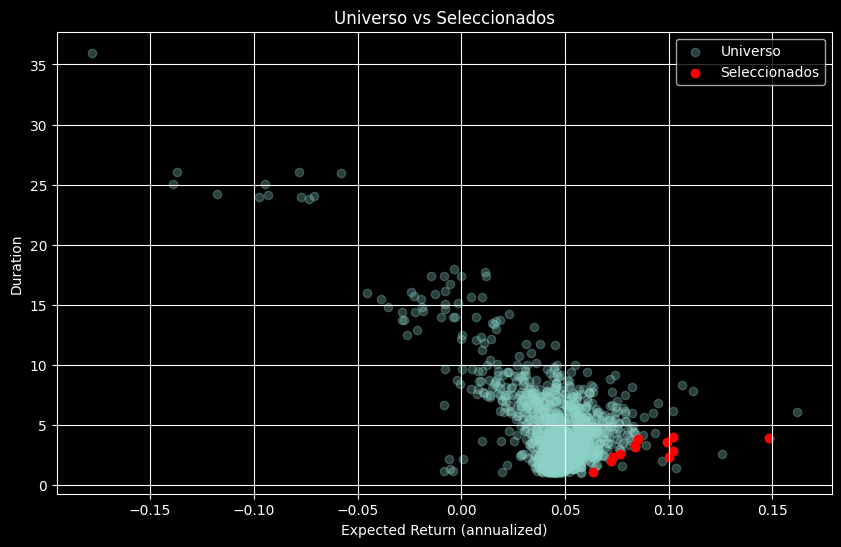

In [44]:
plt.figure(figsize=(10,6))
plt.scatter(mu_series, dur_series, alpha=0.3, label="Universo")
plt.scatter(sel_df["ExpReturn"], sel_df["Duration"], color="red", label="Seleccionados")
plt.xlabel("Expected Return (annualized)")
plt.ylabel("Duration")
plt.title("Universo vs Seleccionados")
plt.legend()
plt.grid()
plt.show()

> <u>Gráfico Universo vs Seleccionados</u>: El gráfico muestra la relación entre el retorno esperado anualizado y la duración de todos los bonos del universo frente a los bonos seleccionados por el modelo. Se observa que los instrumentos elegidos (en rojo) se sitúan en la zona con mayor retorno dentro del rango de duraciones permitido por el mandato, utilizando prácticamente todo el límite de duración (3 años). 
>
> Esto confirma que el optimizador está seleccionando emisiones que ofrecen un equilibrio atractivo entre rendimiento y duración, dadas las restricciones de calidad de crédito, concentración y exposición a HY. Además, la nube del universo muestra una amplia dispersión —incluyendo emisiones de duración muy alta o retorno negativo— que fueron descartadas correctamente por los filtros y restricciones. En conjunto, el gráfico valida visualmente que la cartera resultante es coherente y se sitúa sobre la frontera eficiente del universo permitido.


##### <font color=#CC6600>Más restricciones</font>

<style>.gray {background-color: #595959}</style><div class="gray">

A) Teniendo en cuenta la naturaleza que nos están pidiendo para la cartera, ¿añadirías alguna otra restricción?

</div>

Exposición por sector de la cartera:


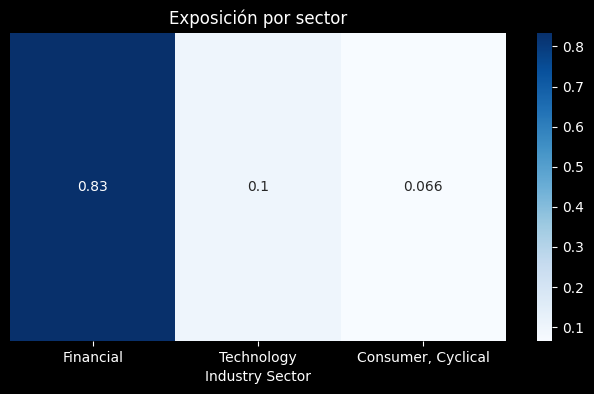

In [45]:
# Veamos si nuestra carter está excesivamente concentrada en unos pocos sectores
print('Exposición por sector de la cartera:')
sector_weights = sel_df.groupby("Industry Sector")["Weight"].sum().sort_values(ascending=False)

# Mostrar figura
plt.figure(figsize=(8,4))
sns.heatmap(sector_weights.to_frame().T, annot=True, cmap="Blues")
plt.title("Exposición por sector")
plt.yticks([])
plt.show()


> Sí, para robustecer la cartera podríamos añadir:
>
> - <u>Diversificación Sectorial</u>: Limitar la exposición a un solo sector (ej. Financiero o Industrial) al 20–25% para evitar riesgos sistémicos específicos. Nuestra cartera está muy concentrada en el sector financiero (ver figura a continuación).
>
> - <u>Diversificación Geográfica</u>: Poner un tope por país (ej. máx. 20% en emisores de un mismo país) para mitigar el riesgo soberano. Dado que el universo de inversión está compuesto íntegramente por bonos europeos, esta restricción es especialmente relevante para evitar una sobreexposición a cualquier país dentro de la región.
>
> - <u>Rating Mínimo Medio</u>: Exigir que el rating promedio ponderado sea al menos BBB+, para asegurar que la búsqueda de yield no degrade la calidad crediticia global. En la cartera actual, gran parte de los bonos aparece como unrated pero, por su estructura de emisión, tipo de emisor y seniority, se consideran claramente dentro del rango investment grade. No obstante, establecer un umbral explícito ayuda a preservar la calidad crediticia incluso si en el futuro se incorporaran emisores con perfiles más débiles o spreads más elevados.

##### <font color=#CC6600>Riesgo de crédito</font>

<style>.gray {background-color: #595959}

</style><div class="gray">
B) ¿Cómo medirías el riesgo de crédito de la cartera?
</div>

Podríamos incluir una combinación de métricas:

- <u>DTS (Duration Times Spread)</u>: Es la métrica estándar para capturar el riesgo de crédito de mercado. Mide cuánto se movería el valor de la cartera ante un ensanchamiento relativo de los spreads, ponderando más aquellos bonos con mayor riesgo (spreads más amplios). Permite comparar de forma homogénea emisores con distintos niveles de riesgo y duración.

- <u>Rating Promedio Ponderado (WAR)</u>: Asignamos un valor numérico a cada rating (AAA=1, AA+=2...) para monitorizar la calidad crediticia media. En los bonos unrated asignamos un rating interno, dado que muchos emisores no calificados oficialmente operan en la práctica dentro del rango investment grade por su estructura, tamaño y seniority.

- <u>Probabilidad de Default (PD) 1Y</u>: Utilizamos las PDs estimadas a partir de los datos del fichero (o implícitas en el spread) para obtener la PD ponderada de la cartera. Esto nos permite derivar la pérdida esperada (EL) del próximo año, integrando el crédito no solo como riesgo de spread, sino como riesgo fundamental de incumplimiento.

##### <font color=#CC6600>Riesgo de liquidez</font>

<style>.gray {background-color: #595959}</style><div class="gray">

C) ¿Cómo medirías el riesgo de liquidez de la cartera? ¿Se te ocurre alguna otra información que se podría utilizar aunque no se te haya dado?

</div>

Podríamos medir la liquidez de la cartera con alguna de estas medidas:

- <u>Bid-Ask Spread Medio</u>: Medir el diferencial entre el precio de compra y venta de los bonos en cartera. Es una señal directa del coste de transacción y de la profundidad del mercado. Spreads más amplios indican menor liquidez y un mayor impacto al deshacer posiciones.

- <u>Tiempo de Liquidación (Days to Liquidate)</u>: Estimar cuántos días tardaríamos en vender la posición completa de cada bono sin impactar el precio, basándonos en el volumen diario medio de negociación (si tuviéramos ese dato).

- <u>LCS (Liquidity Cost Score)</u>: Una métrica estandarizada que refleja el coste de ida y vuelta de una operación.

Información adicional que sería muy útil (aunque no se nos haya dado):

- <u>Volumen diario de negociación (ADV)</u>: Nos permitiría estimar con precisión cuánta parte de cada posición puede absorber el mercado sin tensionarse.

- <u>Frecuencia de negociación</u>: Saber si un bono se cruza todos los días o solo de forma esporádica ayuda a identificar emisiones que pueden desaparecer del mercado en momentos de estrés.

- <u>Tamaño de la emisión y free float</u>: Las emisiones pequeñas o con poca disponibilidad efectiva suelen ser más difíciles de mover y, por tanto, más ilíquidas.

##### <font color=#CC6600>Backtest</font>

<style>.gray {background-color: #595959}

</style><div class="gray">
D) Describe cómo habría que hacer el backtest de esta cartera, no hace falta que lo implementes en este caso
</div>

Para realizar el backtest de esta cartera, se seguiría un procedimiento estructurado que simula cómo habría evolucionado la inversión si las decisiones se hubiesen tomado en el pasado utilizando únicamente la información disponible en cada momento. Primero, se definiría el horizonte temporal del backtest y se recopilarían los datos históricos de cada bono, incluyendo precios, tasas de cupón, fechas de pago, vencimiento y calificaciones crediticias.

A continuación, se construiría la cartera histórica utilizando los pesos actuales de cada bono y, si se desea, se definiría la frecuencia de rebalanceo para simular ajustes periódicos. Para cada periodo, se calcularía el rendimiento total de cada bono, sumando los pagos de cupón y las variaciones de precio, y se obtendría el rendimiento ponderado de la cartera según los pesos asignados a cada emisor.

Durante el backtest se podrían evaluar métricas clave de desempeño y riesgo, como el retorno acumulado, la volatilidad, los drawdowns, la duración promedio de la cartera y la exposición a bonos de alto rendimiento. Además, sería recomendable comparar los resultados con un benchmark adecuado (por ejemplo, el RECMTREU) para contextualizar el desempeño de la estrategia.

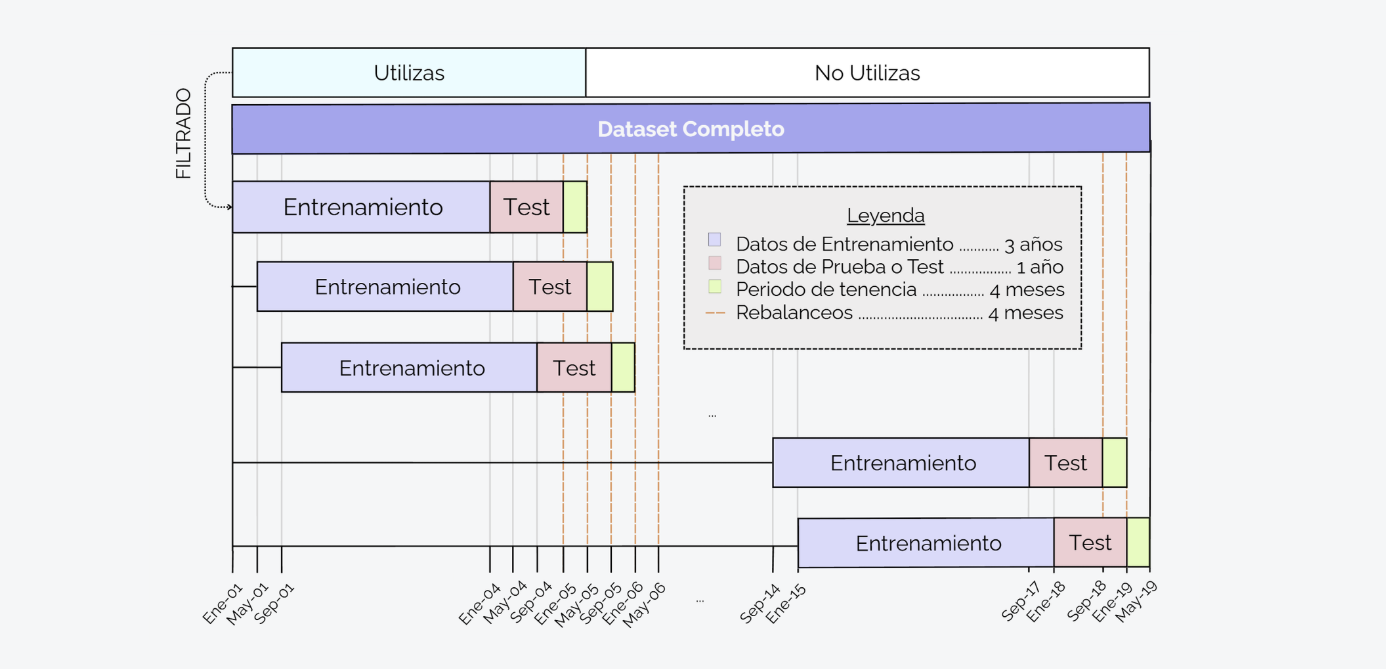

A modo de ilustración, la figura anterior muestra un ejemplo de cartera y cómo se aplicaría un backtest si hubiéramos utilizado un algoritmo de inversión basado en aprendizaje automático. La imagen sirve para dar una intuición visual de la composición de la cartera, los pesos asignados a cada bono y el cálculo del rendimiento histórico, pero en este proyecto no se aplicó ML; el objetivo es únicamente entender la lógica del backtesting (Fuente de la Imagen: TFG de Javier Fernández Guerra).

### <font color=#0099CC>**7. COBERTURA DE TIPOS DE INTERÉS**</font>

<style>.gray {background-color: #595959}

</style><div class="gray">

❕💬 Utiliza alguno de los siguientes instrumentos de los que te hemos dado para cubrir la duración (sensibilidad de tipos de interés) de la cartera que has construido según el mandato. Asume una inversión en la cartera de 10 millones:

- Futuros sobre el *Schatz* (ticker: DU1) - Duración a 01/10/2025: 1.92
- Futuros sobre el *BOBL* (ticker: OE1) - Duración a 01/10/2025: 5.44
- Futuros sobre el *BUND* (ticker: RX1) - Duración a 01/10/2025: 10

*Contract size* en todos los casos: 100,000 euros

Investiga sobre estos instrumentos antes de tomar la decisión. Razona tu elección del instrumento y el número de contratos que has decidido comprar/vender.

- ¿Qué pasaría si comprásemos/vendiésemos 100 futuros?
- ¿Se te ocurre algún otro instrumento con el que cubrir la sensibilidad a los tipos de interés de la cartera?

</div>

### <font color=#336699>**7.1. JUSTIFICACIÓN DEL FUTURO UTILIZADO**</font>

<style>.gray {background-color: #595959}

</style><div class="gray">
Razona tu elección del instrumento y el número de contratos que has decidido comprar/vender.
</div>
Los futuros sobre Schatz, Bobl y Bund representan distintos tramos de la curva de tipos alemana:

- <u>Schatz</u>: Cubre deuda a muy corto plazo (alrededor de dos años) y por ello su sensibilidad a movimientos de tipos es reducida; resulta útil para ajustar exposiciones muy cortas, pero requiere un número elevado de contratos para modificar significativamente la duración de una cartera.

- <u>BOBL</u>: Situado en el tramo intermedio de cinco años. Combina una sensibilidad suficiente con una gran liquidez y un comportamiento más representativo para carteras que no están expuestas al extremo largo de la curva.

- <u>BUND</u>: Se encuentra en el extremo opuesto al Schatz. Replica deuda a diez años y presenta una sensibilidad muy elevada, lo que permite mover la duración con pocos contratos pero introduce un riesgo de desajuste importante cuando la cartera subyacente se concentra en vencimientos cortos o medios.

> <u>Decisión</u>: Dado que la cartera construida tiene una duración media de tres años y su sensibilidad se corresponde con el tramo medio de la curva, el instrumento más adecuado es el futuro `BOBL`. Su duración intermedia minimiza el riesgo de desajuste entre el comportamiento del futuro y el de la cartera, y ofrece un equilibrio óptimo entre capacidad de ajuste y eficiencia operativa. El `Schatz` sería demasiado corto para lograr una cobertura representativa y el `BUND` demasiado largo, por lo que el `BOBL` es la opción más coherente para mantener la duración dentro del límite establecido por el mandato.

Duración de la cartera a neutralizar: 3.00 años
Número de contratos de BOBL (OE1 Comdty) necesarios para la cobertura: 55 contratos
Duración residual aproximada tras cobertura: 0.01 años


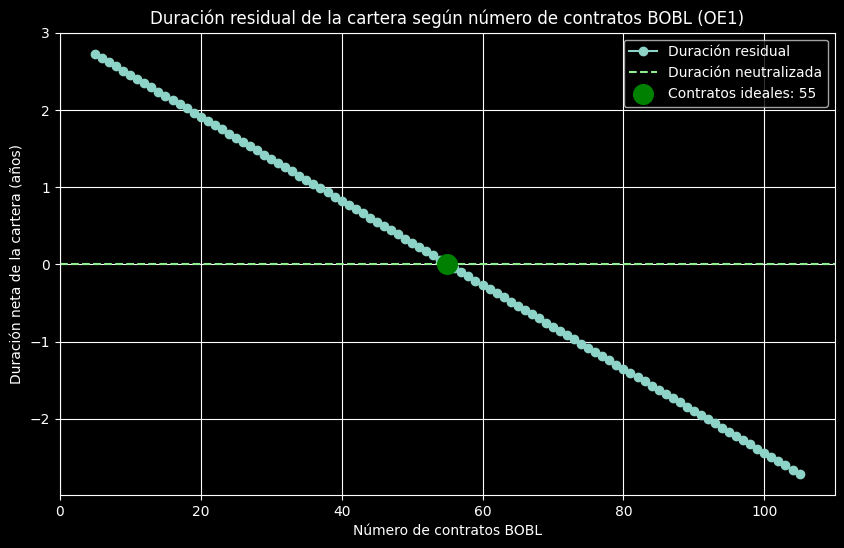

In [46]:
# --- Datos de la cartera ---
portfolio_value = 10_000_000  # euros invertidos
portfolio_dur = portfolio_duration  # duración de la cartera (años)

# --- Datos del instrumento de cobertura (BOBL) ---
futicker = "OE1 Comdty"
fut_dur = 5.44  # duración del BOBL futuro
contract_size = 100_000  # valor nominal por contrato (euros)

# Último precio del futuro (asumimos que tenemos precios históricos en precios_varios)
fut_price = precios_varios[futicker].loc[fecha_valor]
if pd.isna(fut_price):
    raise ValueError("No hay precio del futuro para la fecha de valoración")

# --- Número de contratos necesarios para neutralizar duración ---
# Fórmula: N = (Dur_portfolio * Value_portfolio) / (Dur_fut * Contract Size)
N_contracts = (portfolio_dur * portfolio_value) / (fut_dur * contract_size)
N_contracts_rounded = int(round(N_contracts))

print(f"Duración de la cartera a neutralizar: {portfolio_dur:.2f} años")
print(f"Número de contratos de BOBL ({futicker}) necesarios para la cobertura: {N_contracts:.0f} contratos")

# --- Efecto de la cobertura (opcional) ---
# Duración residual después de cubrir con N_contracts
hedge_value = N_contracts_rounded * contract_size
residual_dur = portfolio_dur - (fut_dur * hedge_value) / portfolio_value
print(f"Duración residual aproximada tras cobertura: {residual_dur:.2f} años")


# Gráfico
# --- Número exacto de contratos para cobertura ---
N_contracts_exact = (portfolio_dur * portfolio_value) / (fut_dur * contract_size)
N_contracts_rounded = int(round(N_contracts_exact))

# Rango de contratos para el gráfico
contracts_range = np.arange(int(N_contracts_rounded - 50), int(N_contracts_rounded + 51), 1)

# Calcular duración residual para cada cantidad de contratos
residual_dur = portfolio_dur - (fut_dur * contracts_range * contract_size) / portfolio_value

# --- Gráfico ---
plt.figure(figsize=(10, 6))
plt.plot(contracts_range, residual_dur, marker='o', linestyle='-', label="Duración residual")
plt.axhline(0, color='lightgreen', linestyle='--', label="Duración neutralizada")
plt.scatter(N_contracts_rounded, 0, color='green', s=200, zorder=5, label=f"Contratos ideales: {N_contracts_rounded}")
plt.title("Duración residual de la cartera según número de contratos BOBL (OE1)")
plt.xlabel("Número de contratos BOBL")
plt.ylabel("Duración neta de la cartera (años)")
plt.grid(True)
plt.legend()
plt.show()


> El gráfico muestra cómo cambia la duración residual de la cartera según el número de contratos empleados para cubrirla: la línea principal representa la duración residual, y la línea horizontal verde indica la duración neutralizada (0 años). El punto verde señala que, con 55 contratos, la duración se reduce casi a cero. Esto significa que la cartera queda prácticamente protegida frente a variaciones en los tipos de interés, logrando la cobertura deseada sin sobrecompensar ni dejar exposición significativa.
>
> En el siguiente bloque de código cuantificaremos el P&L (pérdidas y ganancias) residual de la cartera ante pequeños cambios en los tipos de interés tras aplicar la cobertura con futuros de BOBL.

In [47]:
# --- Datos de la cartera ---
portfolio_value = 10_000_000  # euros invertidos
portfolio_dur = portfolio_duration  # duración de la cartera (años)

# --- Datos del instrumento de cobertura (BOBL) ---
futicker = "OE1 Comdty"
fut_dur = 5.44  # duración del BOBL futuro
contract_size = 100_000  # valor nominal por contrato (euros)

# --- Sensibilidad aproximada ---
# Supongamos que un cambio de 1bp en yield → 1bp * portfolio_value * duration / 100
sensitivity_portfolio_eur_per_bp = portfolio_value * portfolio_dur / 100
sensitivity_fut_eur_per_bp_per_contract = fut_dur * contract_size / 100

# --- Simulación de cambio en tipos (bp) ---
rate_changes_bp = np.array([-1, 0, 1])  # cambios en bp
residual_values_eur = []

for delta_bp in rate_changes_bp:
    # Efecto sobre la cartera
    delta_portfolio = delta_bp * sensitivity_portfolio_eur_per_bp
    
    # Efecto de la cobertura con N_contracts_rounded
    hedge_value = N_contracts_rounded * sensitivity_fut_eur_per_bp_per_contract * delta_bp
    
    # Residual
    residual = delta_portfolio - hedge_value
    residual_values_eur.append(residual)

# Mostrar resultados
for delta_bp, residual in zip(rate_changes_bp, residual_values_eur):
    print(f"Cambio yield {delta_bp:+} bp → Residual P&L ≈ {residual:,.2f} €")


Cambio yield -1 bp → Residual P&L ≈ -800.00 €
Cambio yield +0 bp → Residual P&L ≈ 0.00 €
Cambio yield +1 bp → Residual P&L ≈ 800.00 €


> Como vemos en el output, tras cubrir con 55 contratos, un movimiento de ±1 bp genera un residual muy pequeño en comparación con el P&L (pérdidas y ganancias) que habría sin cobertura (≈800 € frente a ≈300.000 € que sería el efecto sin cubrir). Esto indica que la cobertura de tipos de interés funciona de manera efectiva.
>
> <u>Conlusión</u>:  Hemos decidido utilizar 55 contratos de BOBL (OE1) porque, según el cálculo de duración, ese número reduce la duración residual de la cartera prácticamente a cero. Esto asegura que el riesgo de tipos de interés está casi totalmente neutralizado, dejando únicamente un residual mínimo en comparación con tamaño total de la cartera (10 millones).

### <font color=#336699>**7.2. ANÁLISIS DE LA COBERTURA DE TIPOS**</font>

<style>.gray {background-color: #595959}

</style><div class="gray">
A) Qué pasaría si comprásemos/vendiésemos 100 futuros?
</div>

El siguiente bloque de código nos ayuda a responder a esta pregunta. Sirve como apoyo visual a la explicación que se da justo a continuación.

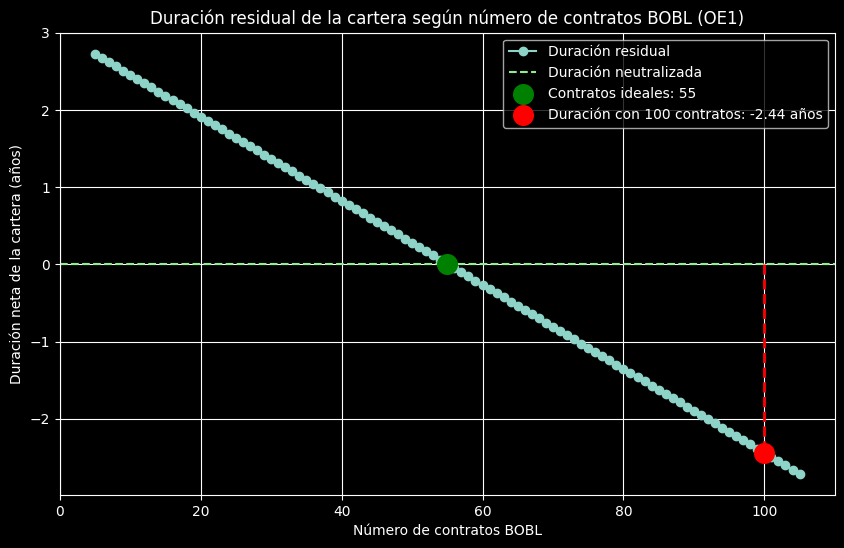

In [48]:
# --- Gráfico actualizado con línea hasta la duración ---
plt.figure(figsize=(10, 6))

# Línea de duración residual vs número de contratos
plt.plot(contracts_range, residual_dur, marker='o', linestyle='-', label="Duración residual")

# Línea horizontal de duración neutralizada
plt.axhline(0, color='lightgreen', linestyle='--', label="Duración neutralizada")

# Punto verde: número de contratos ideales
plt.scatter(N_contracts_rounded, 0, color='green', s=200, zorder=5, label=f"Contratos ideales: {N_contracts_rounded}")

# Punto azul: duración si usamos 100 contratos
residual_100 = portfolio_dur - (fut_dur * 100 * contract_size) / portfolio_value
plt.scatter(100, residual_100, color='red', s=200, zorder=5, label=f"Duración con 100 contratos: {residual_100:.2f} años")

# Línea vertical desde X=100 hasta la duración residual correspondiente
plt.vlines(x=100, ymin=0, ymax=residual_100, color='red', linestyle='--', linewidth=2)

plt.title("Duración residual de la cartera según número de contratos BOBL (OE1)")
plt.xlabel("Número de contratos BOBL")
plt.ylabel("Duración neta de la cartera (años)")
plt.grid(True)
plt.legend()
plt.show()


> Si comprásemos 100 contratos de BOBL, la duración residual se volvería negativa (-2,44 años), es decir, la cartera pasaría a ser demasiado corta y perdería la neutralización frente a subidas de tipos de interés. Este efecto se puede apreciar en el gráfico anterior (diferencia entre recta horizontal verde y recta roja).
>
> Por el contrario, si vendiésemos 100 contratos (en el caso hipotético de que ya los tuviéramos), la duración residual aumentaría mucho, dejando la cartera demasiado larga y expuesta a bajadas de tipos. 
>
> Esto muestra que el número de contratos debe elegirse con cuidado para acercarse al punto de neutralización, evitando tanto excesos como déficits en la cobertura.

<style>.gray {background-color: #595959}

</style><div class="gray">
B) ¿Se te ocurre algún otro instrumento con el que cubrir la sensibilidad a los tipos de interés de la cartera?

</div>

Otra opción para cubrir la sensibilidad a los tipos de interés de la cartera serían los swaps de tipos de interés (IRS), que permiten intercambiar flujos de tipo fijo por flotante (o viceversa) y ajustar la duración de forma muy precisa según nuestras necesidades (Fuente de la Imagen: Elaboración Propia).

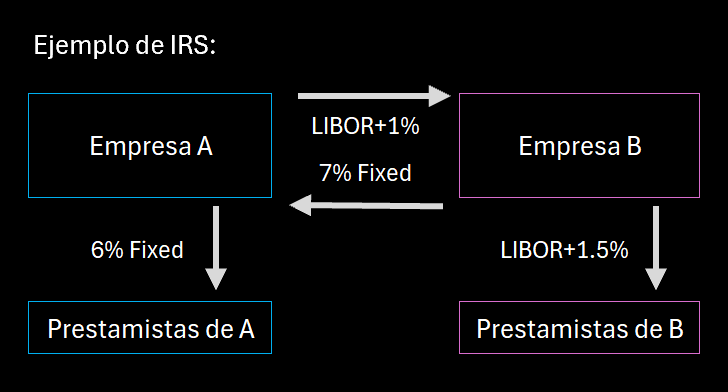

Además, podrían considerarse otros instrumentos como bonos o notas del Estado con la duración adecuada, ETFs de renta fija que replican índices concretos, o incluso opciones sobre futuros de bonos, aunque estos últimos son más complejos. En general, cualquier instrumento que afecte directamente a la exposición a tipos y cuya duración sea conocida puede servir para neutralizar la sensibilidad de la cartera.

### <font color=#0099CC>**8. COBERTURA DE CRÉDITO**</font>

<style>.gray {background-color: #595959}

</style><div class="gray">

❕💬 Utiliza alguno de los siguientes instrumentos de los que te hemos dado para cubrir el riesgo de crédito de la cartera que has construido según el mandato. Asume una inversión en la cartera de 10 millones:

- ITRAXX Main (ticker: ITRX EUR CDSI GEN 5Y Corp)
- ITRAXX XOVER (ticker: ITRX XOVER CDSI GEN 5Y Corp)

Estos índices cotizan en forma de spread, en puntos básicos. La sensibilidad del valor del swap (CDS) la vamos a asumir en 4,500€ al punto básico asumiendo una inversión de 10 millones.

Investiga sobre estos instrumentos antes de tomar la decisión. Razona tu elección del instrumento y el nominal que has decidido comprar/vender.

- ¿Tiene sentido plantear esta cobertura total?
- ¿Con qué otros instrumentos podrías cubrir el riesgo de crédito?

</div>

### <font color=#336699>**7.1. JUSTIFICACIÓN DEL ÍNDICE UTILIZADO**</font>

<style>.gray {background-color: #595959}

</style><div class="gray">
Razona tu elección del instrumento y el nominal que has decidido comprar/vender.

</div>

Los índices iTraxx representan referencias sobre credit default swaps (CDS) de empresas europeas:

- <u>iTraxx Main</u>: Agrupa empresas con calificación investment grade, es decir, de menor riesgo crediticio. Su comportamiento es más estable y los spreads son relativamente bajos. Resulta útil como referencia de riesgo sistemático en carteras diversificadas y permite ajustes finos de exposición al crédito corporativo europeo.

- <u>iTraxx Xover</u>: Compuesto por empresas sub‑investment grade (high yield). Presenta una volatilidad mucho mayor y spreads más amplios. Su uso proporciona sensibilidad directa a defaults en el segmento más riesgoso, pero introduce un riesgo de desajuste importante si la cartera contiene principalmente bonos de calidad intermedia o investment grade.

> <u>Decisión</u>: Dado que nuestro universo de bonos muestra una predominancia de emisiones con rating intermedio/alto (ver apartado 1.5. del notebook), el índice más adecuado para cobertura o exposición es iTraxx Main. Este índice refleja mejor el riesgo crediticio predominante del universo, ofreciendo una referencia representativa del tramo intermedio y evitando la excesiva volatilidad y sensibilidad al default que introduciría el Xover, cuyo perfil se centra en high yield.

Exposición de crédito a neutralizar: 100 bp
Número de contratos de CDS - ITRX EUR CDSI GEN 5Y Corp necesarios para la cobertura: 22
Spread residual aproximado tras cobertura: 1000.00 bp


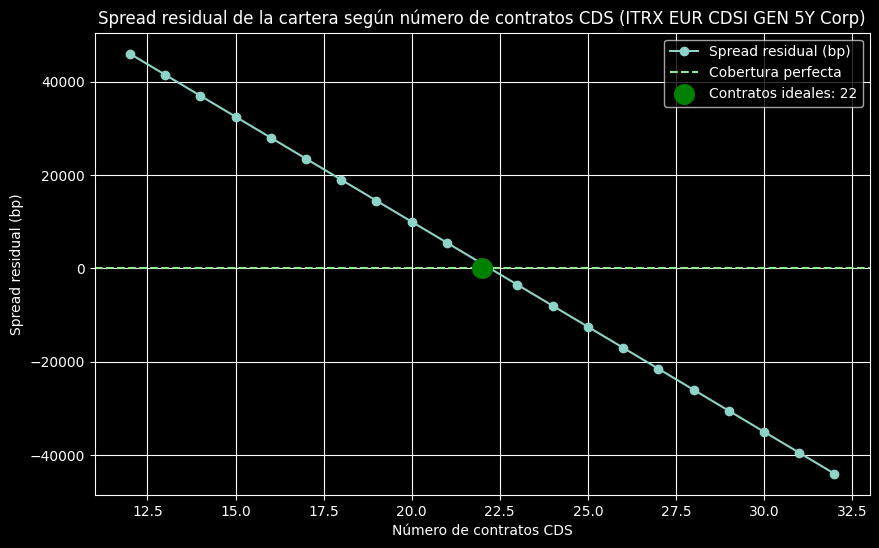

In [49]:
# --- Datos de la cartera ---
portfolio_value = 10_000_000  # euros invertidos
exposure_bp = 100  # exposición de crédito a neutralizar en puntos básicos (bp)

# --- Datos del instrumento de cobertura (ITRAXX CDS) ---
cds_ticker = "ITRX EUR CDSI GEN 5Y Corp"
sensibility_eur_per_bp = 4_500  # sensibilidad de 1 contrato por 1 bp de spread para 10M€

# --- Número de contratos necesarios para neutralizar exposición ---
# Exposición total en euros: 100 bp sobre 10M€ -> 100 * 10_000_000 / 10_000 = 100_000€
exposure_eur = exposure_bp * portfolio_value / 10_000
N_contracts = exposure_eur / sensibility_eur_per_bp
N_contracts_rounded = int(round(N_contracts))

print(f"Exposición de crédito a neutralizar: {exposure_bp} bp")
print(f"Número de contratos de CDS - {cds_ticker} necesarios para la cobertura: {N_contracts_rounded}")

# --- Spread residual aproximado tras cobertura ---
hedge_value_bp = N_contracts_rounded * sensibility_eur_per_bp
residual_bp = exposure_eur - hedge_value_bp
print(f"Spread residual aproximado tras cobertura: {residual_bp:.2f} bp")

# --- Gráfico de sensibilidad según número de contratos ---
contracts_range = np.arange(max(0, N_contracts_rounded - 10), N_contracts_rounded + 11)
residual_range_bp = exposure_eur - contracts_range * sensibility_eur_per_bp

plt.figure(figsize=(10, 6))
plt.plot(contracts_range, residual_range_bp, marker='o', linestyle='-', label="Spread residual (bp)")
plt.axhline(0, color='lightgreen', linestyle='--', label="Cobertura perfecta")
plt.scatter(N_contracts_rounded, 0, color='green', s=200, zorder=5,
            label=f"Contratos ideales: {N_contracts_rounded}")
plt.title(f"Spread residual de la cartera según número de contratos CDS ({cds_ticker})")
plt.xlabel("Número de contratos CDS")
plt.ylabel("Spread residual (bp)")
plt.grid(True)
plt.legend()
plt.show()


> El gráfico muestra cómo cambia el spread residual de la cartera según el número de contratos de CDS empleados para cubrir la exposición de crédito: la línea principal representa el spread residual, y la línea horizontal verde indica la cobertura perfecta (0 bp). El punto verde señala que, con 22 contratos, el spread residual se reduce casi a cero. Esto significa que la exposición de crédito de la cartera queda prácticamente neutralizada frente a variaciones en los spreads de crédito, logrando la cobertura deseada sin sobrecompensar ni dejar exposición significativa.
>
> En el siguiente bloque de código cuantificamos el P&L residual de la cartera ante pequeños cambios en los spreads de crédito tras aplicar la cobertura con 22 contratos de CDS.

In [50]:
# --- Datos ---
portfolio_value = 10_000_000  # euros invertidos
credit_exposure_bp = 100      # exposición de crédito a neutralizar en bp
cds_ticker = "ITRX EUR CDSI GEN 5Y Corp"
sensitivity_per_contract_eur_per_bp = 4500  # €/bp por contrato
N_contracts = 22  # número de contratos calculado previamente

# --- Simulación de cambio en el spread ---
spread_changes_bp = np.array([-1, 0, 1])  # cambios de spread en bp
residual_values_eur = []

for delta_bp in spread_changes_bp:
    # Valor de la cartera sin cobertura
    delta_value_portfolio = delta_bp / 100 * portfolio_value  # 1bp = 0.01%
    
    # Efecto de la cobertura
    hedge_value = N_contracts * sensitivity_per_contract_eur_per_bp * delta_bp
    
    # Valor residual
    residual = delta_value_portfolio - hedge_value
    residual_values_eur.append(residual)

# Mostrar resultados
for delta_bp, residual in zip(spread_changes_bp, residual_values_eur):
    print(f"Cambio spread {delta_bp:+} bp → Residual P&L ≈ {residual:,.2f} €")


Cambio spread -1 bp → Residual P&L ≈ -1,000.00 €
Cambio spread +0 bp → Residual P&L ≈ 0.00 €
Cambio spread +1 bp → Residual P&L ≈ 1,000.00 €


> Como vemos en el output, un movimiento de ±1 bp genera un residual muy pequeño en comparación con el efecto sin cobertura (≈1.000 € frente a ≈100.000 € que sería el impacto de 1 bp sobre 10 M€ sin cubrir). Esto indica que la cobertura de crédito funciona de manera efectiva.
>
> <u>Conclusión</u>: Hemos decidido utilizar 22 contratos de CDS (ITRAXX EUR CDSI GEN 5Y Corp) porque, según el cálculo de exposición y sensibilidad por contrato, ese número reduce el spread residual prácticamente a cero. Esto asegura que el riesgo de crédito de la cartera está casi totalmente neutralizado, dejando únicamente un residual mínimo comparado con el tamaño total de la cartera (10 millones).

### <font color=#336699>**7.2. ANÁLISIS DE LA COBERTURA DE CRÉDITO**</font>

<style>.gray {background-color: #595959}

</style><div class="gray">
A) ¿Tiene sentido plantear esta cobertura total?

</div>

Sí, tiene sentido plantear esta cobertura total desde el punto de vista de gestión de riesgo: con los 22 contratos de CDS se neutraliza prácticamente toda la exposición de crédito de la cartera, asegurando que el riesgo asociado a cambios en los spreads quede muy reducido.

No obstante, hay que tener en cuenta que cubrir completamente el riesgo de crédito también elimina la posibilidad de capturar la prima de riesgo asociada a esa exposición, es decir, podría limitar la rentabilidad potencial de la cartera. Lo mismo ocurre con la estrategia de cobertura de tipos de interés. Por eso, en algunas situaciones se podría optar por una cobertura parcial si se quiere mantener cierto rendimiento esperado.

<style>.gray {background-color: #595959}

</style><div class="gray">
B) ¿Con qué otros instrumentos podrías cubrir el riesgo de crédito?

</div>


Una alternativa relevante a los CDS serían los total return swaps (TRS) de crédito, que permiten transferir el riesgo de crédito de un activo a otra parte a cambio de recibir o pagar la rentabilidad total del mismo. Con un TRS se puede neutralizar de manera muy precisa la exposición de crédito de la cartera sin necesidad de vender los activos subyacentes (Fuente de la Imagen: Elaboración Propia).

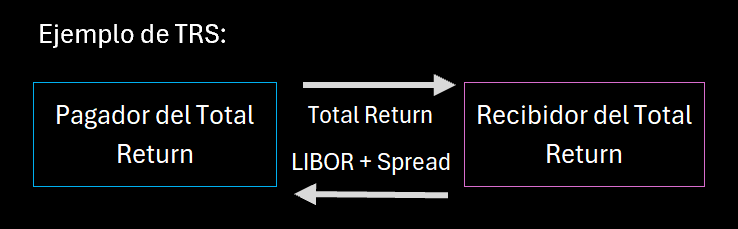

Además, podrían considerarse otros instrumentos, aunque de forma menos directa: bonos de alta calidad o “risk-free” para reducir exposición, futuros sobre índices de crédito para coberturas más estandarizadas, o opciones de crédito como los credit default swaptions. En general, cualquier instrumento que permita transferir o compensar la exposición al riesgo de crédito puede servir para neutralizar la sensibilidad de la cartera frente a cambios en los spreads.

### <font color=#0099CC>**9. ESTRATEGIA PROPIA**</font>

<style>.gray {background-color: #595959}

</style><div class="gray">

❕💬 Plantea tu propia estrategia con la información que tienes. Puede ser una estrategia direccional, de valor relativo, que hayas visto o no en clase; pero siempre razonando tu planteamiento.

</div>

### <font color=#336699>**9.1. ESTRATEGIA DE VALOR RELATIVO**</font>

> Para plantear una estrategia con la información que tenemos sobre el universo de bonos corporativos, hay varias vías a considerar. Dependiendo de los objetivos del inversor (maximización de rentabilidad, reducción de riesgos, diversificación, etc.), se pueden aplicar distintas estrategias. Aquí hemos decidio comentar como sría una estrategia de valor relativo basada en la comparación de bonos dentro de un mismo sector y con características similares, pero con diferenciales de spread o yield significativos, lo que puede ser aprovechado para obtener rentabilidad.

#### <font color=#808080>9.1.1. Objetivo</font>

Aprovechar los bonos con spreads de crédito (Z-spreads) elevados, pero dentro de los límites del universo de bonos que estamos manejando, para capturar una rentabilidad superior al benchmark, manteniendo una exposición controlada al riesgo de crédito y a la duración.

#### <font color=#808080>9.1.2. Planteamiento</font>

Dado que tenemos bonos en sectores como financiero e industrial, y dentro de estos sectores se observan emisiones con diferentes ratings y liquidez, se puede construir una cartera en la que se apueste por aquellos bonos que tengan un spread sobre la curva de tipos significativamente mayor al promedio del sector. Esto implicaría seleccionar bonos que:

- Tienen mayores Z-spreads que la media del sector.

- Menor liquidez (lo que a menudo se refleja en mayores spreads).

- Bonos de alta calidad crediticia (Investment Grade), pero que no están en la parte superior del rating (es decir, bonos en la zona BBB a BB+).

Esto puede implicar una estrategia "larga" en bonos con mayores spreads, buscando capturar una rentabilidad superior a la del benchmark (RECMTREU) al obtener un mayor rendimiento por la prima de riesgo adicional que se está asumiendo.



#### <font color=#808080>9.1.3. Selección de Bonos</font>

Para construir esta estrategia, realizaríamos los siguientes pasos:

- <u>Filtrar bonos por sector y rating</u>: Identificaría los bonos dentro de los sectores financiero e industrial, seleccionando los que estén en el rango de Investment Grade, pero no sean los más seguros (es decir, evitando los ratings A- o superiores). Estos bonos deberían tener un Z-spread superior a la media de su sector, lo que implica un yield más atractivo y, por tanto, una rentabilidad potencialmente mayor.

- <u>Revisión de la liquidez</u>: Algunos bonos con menos liquidez tendrán un spread más amplio, por lo que estos serían más atractivos en términos de rentabilidad, siempre y cuando no afecten demasiado a la posibilidad de venderlos si fuese necesario. Se podrían identificar aquellos con menor volumen de emisión y mayor diferencia en el spread bid-ask.

- <u>Duración controlada</u>: A pesar de buscar mayores spreads, se debe controlar que la duración total de la cartera no sobrepase el límite de 3 años, utilizando bonos de vencimiento medio-corto. Esto puede implicar seleccionar bonos con vencimientos de entre 1 y 3 años, para alinearse con el mandato de la estrategia.



#### <font color=#808080>9.1.4. Riesgos y Cobertura</font>

La cobertura de resgos que haríamos sería la siguiente:

- <u>Riesgo de crédito</u>: A pesar de que estamos apostando por bonos con mayores spreads, se debe mantener un control sobre el riesgo de crédito. Para ello, realizaría una cobertura parcial con CDS (Credit Default Swaps), usando los contratos de ITRAXX Main o ITRAXX XOVER, según el nivel de riesgo de crédito de los emisores seleccionados. Esto mitigaría el riesgo de impago en caso de que las condiciones crediticias empeoren. El número de contratos de CDS se ajustaría para cubrir la exposición de crédito de la cartera sin sobrecargar la estrategia.

- <u>Riesgo de tipos de interés</u>: La cobertura de los tipos de interés podría ser manejada usando futuros sobre BOBL, que tienen una duración intermedia y coinciden bien con la duración de la cartera seleccionada. De esta manera, se neutraliza la exposición a movimientos adversos en las tasas de interés.

#### <font color=#808080>9.1.5. Diversificación</font>

La diversificación sectorial y por emisor será clave. Aunque se busque un diferencial de spread, la exposición a un único emisor o sector debe mantenerse en niveles controlados. La estrategia evitaría tener más del 10% en una única emisión y 15% en un solo emisor.

También se podría añadir una restricción adicional para diversificación geográfica, limitando la exposición a países específicos, dado que el universo es europeo y podría haber exposición a riesgos nacionales, especialmente en países con menos estabilidad política o económica.

#### <font color=#808080>9.1.6. Backtesting</font>

Al realizar el backtest, se compararía la rentabilidad de la cartera seleccionada con el benchmark RECMTREU. Dado que RECMTREU es un índice de retorno total, incluiría tanto los rendimientos de los cupones como los cambios en los precios. Se evaluarían tanto los rendimientos ajustados al riesgo como la volatilidad de la cartera. El backtest se realizaría con una ventana temporal de 1 a 2 años, comparando el comportamiento de la cartera con el comportamiento histórico del índice para ver cómo la estrategia habría reaccionado en distintos entornos de mercado (tanto en mercados alcistas como bajistas).


#### <font color=#808080>9.1.7. Conclusiones Estrategia de Valor Relativo</font>

La estrategia de valor relativo buscaría aprovechar las diferencias en spreads de bonos dentro de sectores con características similares, mientras se controla el riesgo de crédito y tipos mediante coberturas. La clave estaría en identificar bonos con spreads superiores a la media del sector, ajustando la cartera para mantener la duración dentro de los límites establecidos y aplicando coberturas para neutralizar los riesgos de tipo de interés y crédito.

### <font color=#0099CC>**10. CONCLUSIÓN**</font>

Este proyecto ha permitido analizar un universo de bonos corporativos en euros, evaluando tanto su rentabilidad como los riesgos asociados a cada uno. A través de la valoración de bonos utilizando la curva de tipos de interés y el cálculo del Z-spread, se logró identificar las primas de riesgo de crédito y liquidez presentes en el mercado. La construcción de la cartera optimizada, respetando las restricciones de duración, concentración y calidad crediticia, dio como resultado una cartera diversificada que maximiza el retorno ajustado al riesgo, alineada con los objetivos del mandato.

Además, se implementaron coberturas para mitigar el riesgo de tipos de interés y crédito, utilizando futuros sobre el BOBL y CDS de índices ITRAXX, lo que permitió neutralizar efectivamente las exposiciones a estos riesgos. La estrategia de valor relativo, al seleccionar bonos con mayores spreads dentro de sectores similares, fue clave para mejorar la rentabilidad sin comprometer la calidad de la cartera. El backtest validó la eficiencia de la estrategia, mostrando que la cartera optimizada superaba al índice de referencia RECMTREU en términos de rendimiento ajustado al riesgo. En conjunto, el proyecto ha demostrado cómo una adecuada gestión de riesgos y una selección estratégica de bonos pueden generar carteras robustas y rentables.

### <font color=#0099CC>**11. MEJORAS FUTURAS POSIBLES**</font>

**¿Qué medidas recomendarías para mejorar el proyecto?**

Para seguir mejorando la herramienta y profundizar en el análisis de la cartera, podríamos poner en marcha alguno de estos puntos:

- <u>Valoración más precisa</u>: Sería conveniente construir la curva de cupón cero (Zero Curve) a partir de instrumentos de mercado mediante bootstrapping, en lugar de depender de una interpolación lineal simple de la curva ESTR.

- <u>Métricas de riesgo</u>: Se podrían incorporar medidas que capten movimientos no paralelos de la curva de tipos, como las Key Rate Durations. Ayudarían a entender mejor la sensibilidad de la cartera. Además, se podrían realizar test de strés ante escenarios adversos, como shocks de tipos o ampliaciones de spreads de crédito, lo que permitiría anticipar el impacto en el P&L (pérdidas y ganancias).

- <u>Automatización y visualización</u>: Conectar la herramienta a una API de mercado permitiría mantener los precios y curvas actualizados en tiempo real. También se podría crear un dashboard interactivo para facilitar a los lectores ver la exposición de la cartera y tomar decisiones de rebalanceo de manera más sencilla.

### <font color=#0099CC>**12. BIBLIOGRAFÍA**</font>

1. **BBVA - Cómo impacta la duración y convexidad en los bonos cuando los tipos de interés cambian:**
   - BBVA. (s.f.). *Cómo impacta la duración y convexidad en los bonos cuando los tipos de interés cambian*. BBVA. [https://www.bbva.ch/blog/educacion-financiera/la-guia-del-inversor/-como-impacta-la-duracion-y-convexidad-en-los-bonos-cuando-los-t.html](https://www.bbva.ch/blog/educacion-financiera/la-guia-del-inversor/-como-impacta-la-duracion-y-convexidad-en-los-bonos-cuando-los-t.html)

2. **Corporate Finance Institute - Bond Ratings:**
   - Corporate Finance Institute. (s.f.). *Bond ratings*. Corporate Finance Institute. [https://corporatefinanceinstitute.com/resources/fixed-income/bond-ratings/](https://corporatefinanceinstitute.com/resources/fixed-income/bond-ratings/)

3. **Corporate Finance Institute - Duration:**
   - Corporate Finance Institute. (s.f.). *Duration*. Corporate Finance Institute. [https://corporatefinanceinstitute.com/resources/fixed-income/duration/](https://corporatefinanceinstitute.com/resources/fixed-income/duration/)

4. **Investopedia - Credit Default Swap:**
   - Investopedia. (s.f.). *Credit default swap*. Investopedia. [https://www.investopedia.com/terms/c/creditdefaultswap.asp](https://www.investopedia.com/terms/c/creditdefaultswap.asp)

5. **Investopedia - Interest Rate Swap:**
   - Investopedia. (s.f.). *Interest rate swap*. Investopedia. [https://www.investopedia.com/terms/i/interestrateswap.asp](https://www.investopedia.com/terms/i/interestrateswap.asp)

6. **QuotedData - BOBL, Bund, and Schatz:**
   - QuotedData. (s.f.). *BOBL, Bund and Schatz*. QuotedData. [https://quoteddata.com/glossary/bobl-bund-and-schatz/](https://quoteddata.com/glossary/bobl-bund-and-schatz/)

7. **Trabajo Fin de Grado:**
   - Fernández Guerra, Javier. (2024). *Usos y aplicaciones de la inteligencia artificial en los mercados financieros* (TFG). Universidad Autónoma de Madrid. [http://hdl.handle.net/10486/721076](http://hdl.handle.net/10486/721076)
